# Region3 - All 479 - primary incldue
## Xiaonan Wang
## 31Aug2026

## Step0 - Setup and paths

In [1]:
suppressPackageStartupMessages({
  library(Seurat)
  library(SeuratObject)
  library(dplyr)
  library(tidyr)
  library(tibble)
  library(Matrix)
  library(ggplot2)
})

set.seed(1234)

In [6]:
REGION_ID = "Region_4"

In [7]:
PROJECT_ROOT <- "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium"
PIPELINE_REPO <- file.path(PROJECT_ROOT, "adipose_analysis_B2", "YNH_Xenium_scWAT")
RUN_LABEL <- "full_notebook_qc_v2"
QC_RUN_ROOT <- file.path(
  PROJECT_ROOT,
  "adipose_analysis_B2",
  "scwat_qc_outputs",
  "scwat_qc_hpc/sections",
  REGION_ID
)
DOWNSTREAM_ROOT <- file.path(
  PROJECT_ROOT,
  "adipose_analysis_B2",
  "scwat_downstream_outputs",
  RUN_LABEL
)
ANCHOR_ROOT <- file.path(
  DOWNSTREAM_ROOT,
  paste0("03_", REGION_ID, "_Primary479")
)
INPUT_ROOT <- file.path(PROJECT_ROOT, "adipose_data_B2")

In [114]:
source(file.path(PIPELINE_REPO, "R", "source.R"))

In [8]:
assert_path_within(PROJECT_ROOT, QC_RUN_ROOT)
assert_path_within(PROJECT_ROOT, DOWNSTREAM_ROOT)
dir.create(DOWNSTREAM_ROOT, recursive = TRUE, showWarnings = FALSE)
assert_path_within(PROJECT_ROOT, ANCHOR_ROOT)
dir.create(ANCHOR_ROOT, recursive = TRUE, showWarnings = FALSE)

In [9]:
theme_cell <- function(base_size = 12) {
  theme_classic(base_size = base_size) +
    theme(
      panel.border = element_rect(
        colour = "black",
        fill = NA,
        linewidth = 0.8
      ),
      axis.line = element_line(colour = "black", linewidth = 0.6),
      axis.text = element_text(colour = "black"),
      axis.title = element_text(colour = "black"),
      strip.background = element_rect(
        fill = "white",
        colour = "black",
        linewidth = 0.8
      ),
      strip.text = element_text(face = "bold"),
      legend.title = element_text(face = "bold"),
      plot.title = element_text(face = "bold"),
      plot.subtitle = element_text(colour = "black")
    )
}

## Step1 - Create Seurat Obj

In [10]:
region_info <- discover_one_section(
  input_root = INPUT_ROOT,
  region_id = REGION_ID
)
REGION_XENIUM_DIR <- region_info$region_dir

In [11]:
list.files(
  REGION_XENIUM_DIR,
  recursive = FALSE
)

[1] "analysis"                     "analysis_summary.html"       
 [3] "analysis.zarr.zip"            "aux_outputs"                 
 [5] "cell_boundaries.csv.gz"       "cell_boundaries.parquet"     
 [7] "cell_feature_matrix"          "cell_feature_matrix.h5"      
 [9] "cell_feature_matrix.zarr.zip" "cells.csv.gz"                
[11] "cells.parquet"                "cells.zarr.zip"              
[13] "experiment.xenium"            "gene_panel.json"             
[15] "metrics_summary.csv"          "morphology_focus"            
[17] "morphology.ome.tif"           "nucleus_boundaries.csv.gz"   
[19] "nucleus_boundaries.parquet"   "transcripts.parquet"         
[21] "transcripts.zarr.zip"

In [12]:
region_spatial <- create_spatial_seurat_from_xenium(
  xenium_dir = REGION_XENIUM_DIR,
  project = REGION_ID,
  assay = "Xenium",
  fov = "fov",
  include_cell_segmentation = TRUE,
  include_nucleus_segmentation = TRUE
)

Reading Xenium output directly from:

  /dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data_B2/output-XETG00205__0104985__Region_4__20260814__101700

Reading cell_feature_matrix.h5 ...

Genome matrix has multiple modalities, returning a list of matrices for this genome

Read10X returned feature types: Gene Expression, Negative Control Probe, Negative Control Codeword, Unassigned Codeword

Native matrix: 479 features × 50,439 cells

Reading cells.parquet ...

Matrix/metadata overlapping cells: 50,439

Warning message:
“Setting row names on a tibble is deprecated.”
Warning message:
“No cell overlap between new meta data and Seurat object”
Creating cell segmentation: 1,260,518 vertices

Creating nucleus segmentation: 1,252,689 vertices



Created native Xenium spatial Seurat object: Region_4

  Cells: 50,439

  Genes: 479

  FOV: fov

  Boundaries: centroids, segmentation, nucleus_segmentation



In [13]:
region_spatial

An object of class Seurat 
479 features across 50439 samples within 1 assay 
Active assay: Xenium (479 features, 0 variable features)
 1 layer present: counts
 1 spatial field of view present: fov

In [14]:
head(region_spatial@meta.data)

,orig.ident,nCount_Xenium,nFeature_Xenium
,<fct>,<dbl>,<int>
aaaacbfg-1,Region_4,237,84
aaadkjpo-1,Region_4,245,97
aaafpkbm-1,Region_4,619,120
aaahgoib-1,Region_4,369,71
aaaigbao-1,Region_4,317,82
aaajcimo-1,Region_4,373,87


In [15]:
dim(region_spatial@meta.data)

[1] 50439     3

In [16]:
mask_file <- file.path(
  QC_RUN_ROOT,
  "cell_qc_metadata.tsv.gz"
)

stopifnot(file.exists(mask_file))

masks <- read.delim(
  mask_file,
  stringsAsFactors = FALSE,
  check.names = FALSE
)

dim(masks)

[1] 50439    35

In [17]:
identical(masks$cell_id, colnames(region_spatial))

[1] TRUE

In [18]:
region_spatial <- add_masks_to_seurat(
  object = region_spatial,
  masks = masks,
  overwrite = FALSE
)

Seurat cells: 50,439

Matched to masks: 50,439

Unmatched Seurat cells: 0

Skipping existing metadata columns: nCount_Xenium, nFeature_Xenium

Added 32 metadata columns.

Metadata dimensions: 50439 × 35



In [19]:
head(region_spatial@meta.data, n=2)

,orig.ident,nCount_Xenium,nFeature_Xenium,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,⋯,primary_include,strict_include,hotspot_review_cell,hotspot_sensitivity_include,section_status,mask_rule_primary,mask_rule_strict,mask_rule_hotspot_sensitivity,provenance,initial_qc_status
,<fct>,<dbl>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
aaaacbfg-1,Region_4,237,84,485.3537,4045.316,237,0,0,0,0,⋯,TRUE,TRUE,FALSE,TRUE,SENSITIVITY_ONLY,nFeature_Xenium > 5 AND nFeature_Xenium < 200 AND nCount_Xenium > 10 AND nCount_Xenium < 1000,primary_include AND NOT qc_review_flag,primary_include AND NOT Region_3 morphology-review hotspot cell,scwat_qc_hpc::FULL_HPC,QC_EVIDENCE_PENDING
aaadkjpo-1,Region_4,245,97,491.3460,4070.072,245,0,0,0,0,⋯,TRUE,TRUE,FALSE,TRUE,SENSITIVITY_ONLY,nFeature_Xenium > 5 AND nFeature_Xenium < 200 AND nCount_Xenium > 10 AND nCount_Xenium < 1000,primary_include AND NOT qc_review_flag,primary_include AND NOT Region_3 morphology-review hotspot cell,scwat_qc_hpc::FULL_HPC,QC_EVIDENCE_PENDING


In [20]:
colnames(region_spatial@meta.data)

[1] "orig.ident"                    "nCount_Xenium"                
 [3] "nFeature_Xenium"               "x_centroid"                   
 [5] "y_centroid"                    "transcript_counts"            
 [7] "control_probe_counts"          "genomic_control_counts"       
 [9] "control_codeword_counts"       "unassigned_codeword_counts"   
[11] "deprecated_codeword_counts"    "total_counts"                 
[13] "cell_area"                     "nucleus_area"                 
[15] "nucleus_count"                 "segmentation_method"          
[17] "region_id"                     "control_fraction_cell"        
[19] "nucleus_missing_flag"          "multiple_nuclei_flag"         
[21] "cell_area_outlier_flag"        "high_control_flag"            
[23] "segmentation_multiplet_flag"   "qc_core_pass"                 
[25] "qc_review_flag"                "primary_include"              
[27] "strict_include"                "hotspot_review_cell"          
[29] "hotspot_sensitivity_include"   "section_status"               
[31] "mask_rule_primary"             "mask_rule_strict"             
[33] "mask_rule_hotspot_sensitivity" "provenance"                   
[35] "initial_qc_status"

In [21]:
table(region_spatial$primary_include, region_spatial$qc_core_pass)

       
        FALSE  TRUE
  FALSE  1222     0
  TRUE      0 49217

In [22]:
saveRDS(region_spatial, file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_all.rds")))

## Step2 - Define gene set info

In [23]:
# EOS features
EOS_GENE_SET_PATH <- file.path(
  PIPELINE_REPO,
  "config",
  "eos_gene_sets.tsv"
)

eos_gene_sets <- read.delim(
  EOS_GENE_SET_PATH,
  stringsAsFactors = FALSE
)

In [24]:
# Identity-transfer panel:
# complete 479-gene panel minus short-/long-lived Eos state genes.
# This retains the original 379 mMulti genes plus the 7 common Eos identity genes.

eos_state_genes <- unique(
  eos_gene_sets$gene[
    eos_gene_sets$gene_set %in% c("short_lived", "long_lived")
  ]
)

raw_panel_genes <- rownames(region_spatial)

identity_panel_genes <- setdiff(
  raw_panel_genes,
  eos_state_genes
)

cat("Raw panel genes:", length(raw_panel_genes), "\n")
cat("Eos state genes excluded:", length(intersect(raw_panel_genes, eos_state_genes)), "\n")
cat("Identity panel genes:", length(identity_panel_genes), "\n")

stopifnot(length(raw_panel_genes) == 479L)


Raw panel genes: 479 
Eos state genes excluded: 93 
Identity panel genes: 386 


In [25]:
FIX_GENESET = raw_panel_genes

## Step3 - Subset cells

In [ ]:
region_spatial = readRDS(file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_all.rds")))

In [26]:
colnames(region_spatial@meta.data)

[1] "orig.ident"                    "nCount_Xenium"                
 [3] "nFeature_Xenium"               "x_centroid"                   
 [5] "y_centroid"                    "transcript_counts"            
 [7] "control_probe_counts"          "genomic_control_counts"       
 [9] "control_codeword_counts"       "unassigned_codeword_counts"   
[11] "deprecated_codeword_counts"    "total_counts"                 
[13] "cell_area"                     "nucleus_area"                 
[15] "nucleus_count"                 "segmentation_method"          
[17] "region_id"                     "control_fraction_cell"        
[19] "nucleus_missing_flag"          "multiple_nuclei_flag"         
[21] "cell_area_outlier_flag"        "high_control_flag"            
[23] "segmentation_multiplet_flag"   "qc_core_pass"                 
[25] "qc_review_flag"                "primary_include"              
[27] "strict_include"                "hotspot_review_cell"          
[29] "hotspot_sensitivity_include"   "section_status"               
[31] "mask_rule_primary"             "mask_rule_strict"             
[33] "mask_rule_hotspot_sensitivity" "provenance"                   
[35] "initial_qc_status"

In [27]:
options(repr.plot.width=8, repr.plot.height=8)

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


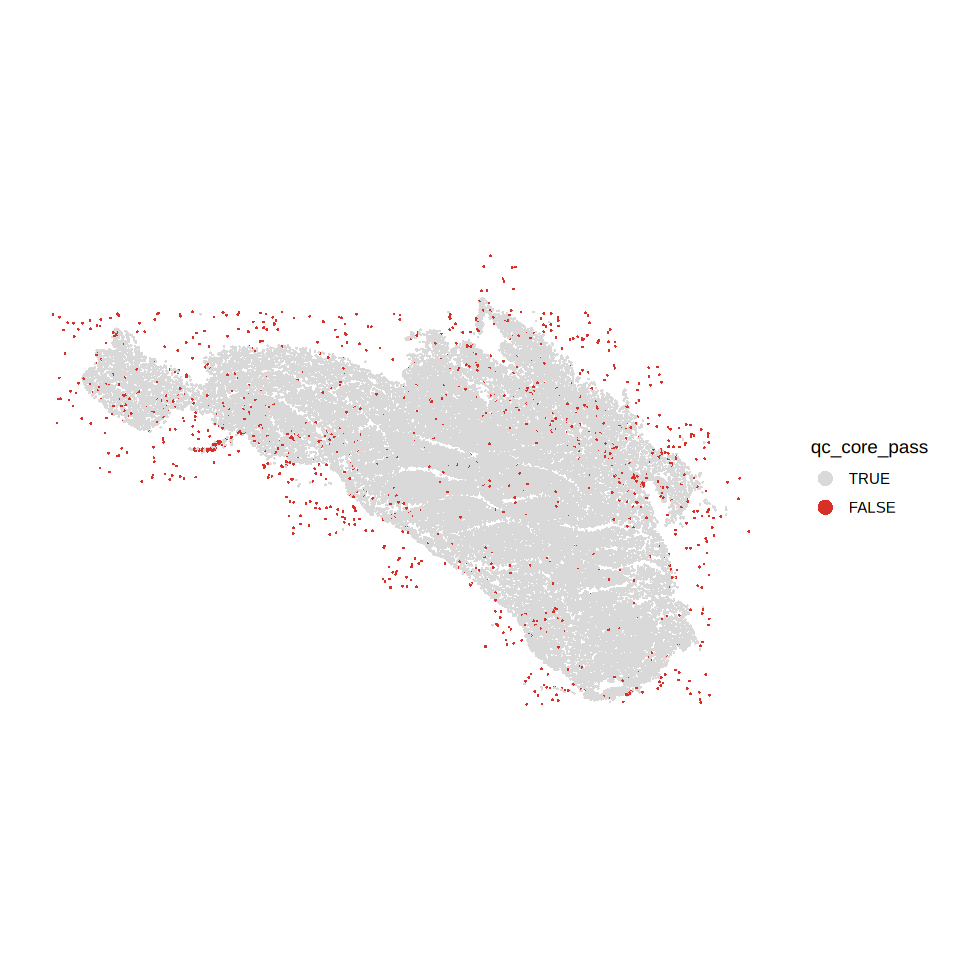

In [28]:
ImageDimPlot(
  region_spatial,
  fov = "fov",
  group.by = c('qc_core_pass'),
  flip_xy = FALSE,
  dark.background = FALSE,
  cols = c(
    "FALSE" = "#D73027", 
    "TRUE"  = "#D9D9D9"  
  )
)

In [29]:
flag_cols <- c(
  "high_control_flag",
  "segmentation_multiplet_flag",
  "nucleus_missing_flag",
  "multiple_nuclei_flag",
  "cell_area_outlier_flag"
)

sapply(
  masks[, flag_cols, drop = FALSE],
  function(x) {
    c(
      n = sum(x %in% TRUE, na.rm = TRUE),
      pct = 100 * mean(x %in% TRUE, na.rm = TRUE)
    )
  }
)

,high_control_flag,segmentation_multiplet_flag,nucleus_missing_flag,multiple_nuclei_flag,cell_area_outlier_flag
n,4.000000000,599.000000,595.000000,579.000000,253.000000
pct,0.007930371,1.187573,1.179643,1.147921,0.501596


In [30]:
table(!region_spatial$qc_core_pass, region_spatial$segmentation_multiplet_flag)

       
        FALSE  TRUE
  FALSE 48662   555
  TRUE   1178    44

In [31]:
region_spatial$primary_include_revised <-
  (masks$qc_core_pass %in% TRUE) &
  !(masks$high_control_flag %in% TRUE) &
  !(masks$segmentation_multiplet_flag %in% TRUE)

In [32]:
table(region_spatial$primary_include_revised)


FALSE  TRUE 
 1781 48658 

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


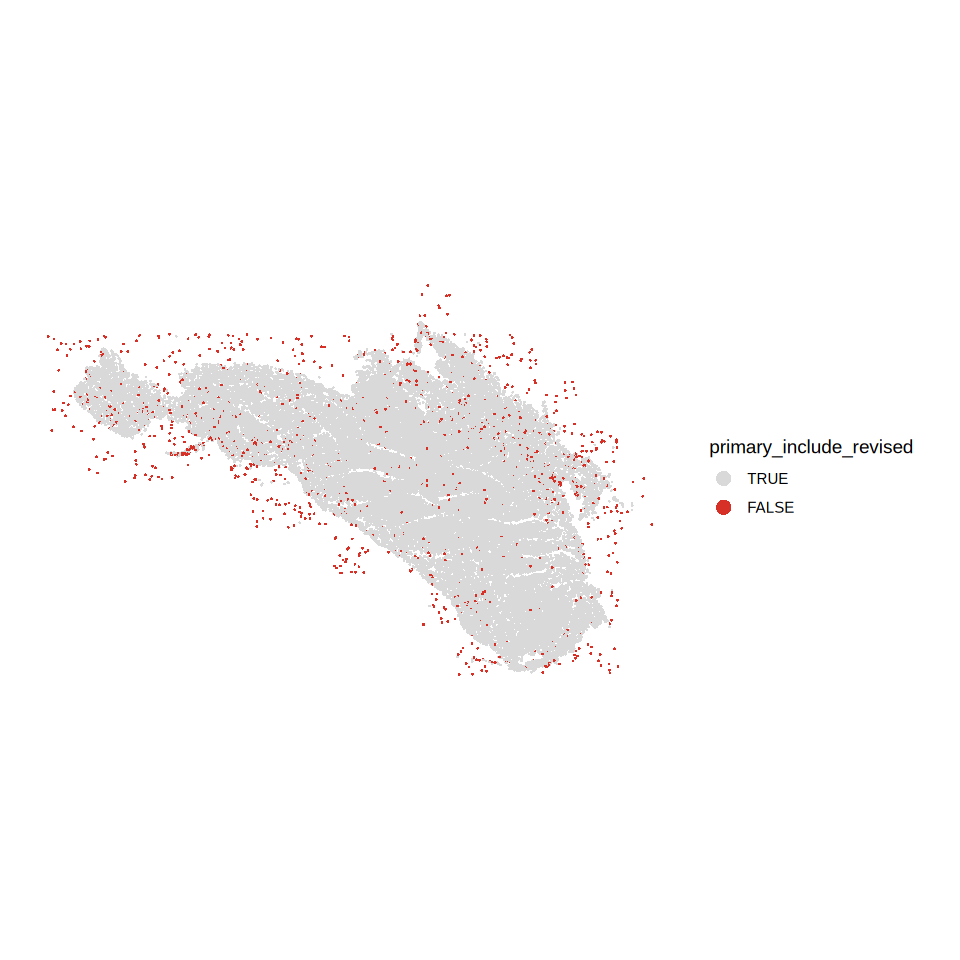

In [33]:
ImageDimPlot(
  region_spatial,
  fov = "fov",
  group.by = c('primary_include_revised'),
  flip_xy = FALSE,
  dark.background = FALSE,
  cols = c(
    "FALSE" = "#D73027", 
    "TRUE"  = "#D9D9D9"  
  )
)

In [34]:
region_spatial <- subset(
  region_spatial,
  subset = primary_include_revised == TRUE
)

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


In [35]:
region_spatial

An object of class Seurat 
479 features across 48658 samples within 1 assay 
Active assay: Xenium (479 features, 0 variable features)
 1 layer present: counts
 1 spatial field of view present: fov

In [36]:
saveRDS(region_spatial, file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_passQC.rds")))

In [37]:
# Normalisation - better use lognormlize rather than SCTransform
DefaultAssay(region_spatial) <- "Xenium"

region_spatial <- NormalizeData(
  region_spatial,
  assay = "Xenium",
  normalization.method = "LogNormalize",
  scale.factor = 10000,
  verbose = FALSE
)

In [38]:
region_spatial

An object of class Seurat 
479 features across 48658 samples within 1 assay 
Active assay: Xenium (479 features, 0 variable features)
 2 layers present: counts, data
 1 spatial field of view present: fov

In [39]:
# only use the cell type genes for PCA as key features
region_spatial <- ScaleData(
  region_spatial,
  assay = "Xenium",
  features = FIX_GENESET,
  verbose = FALSE
)

region_spatial <- RunPCA(
  region_spatial,
  assay = "Xenium",
  features = FIX_GENESET,
  npcs = 30,
  seed.use = 1234,
  verbose = FALSE
)

In [40]:
region_spatial

An object of class Seurat 
479 features across 48658 samples within 1 assay 
Active assay: Xenium (479 features, 0 variable features)
 3 layers present: counts, data, scale.data
 1 dimensional reduction calculated: pca
 1 spatial field of view present: fov

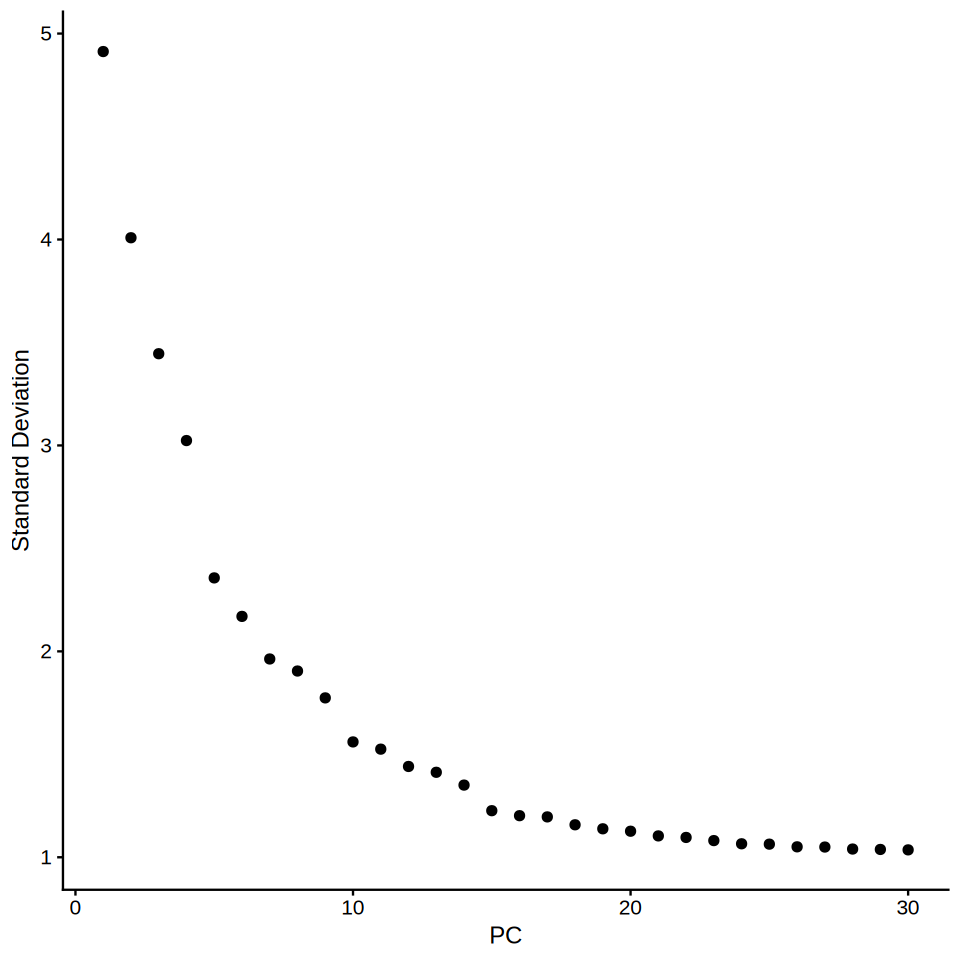

In [41]:
ElbowPlot(
  region_spatial,
  ndims = 30
)

In [42]:
options(repr.plot.width=12, repr.plot.height=12)

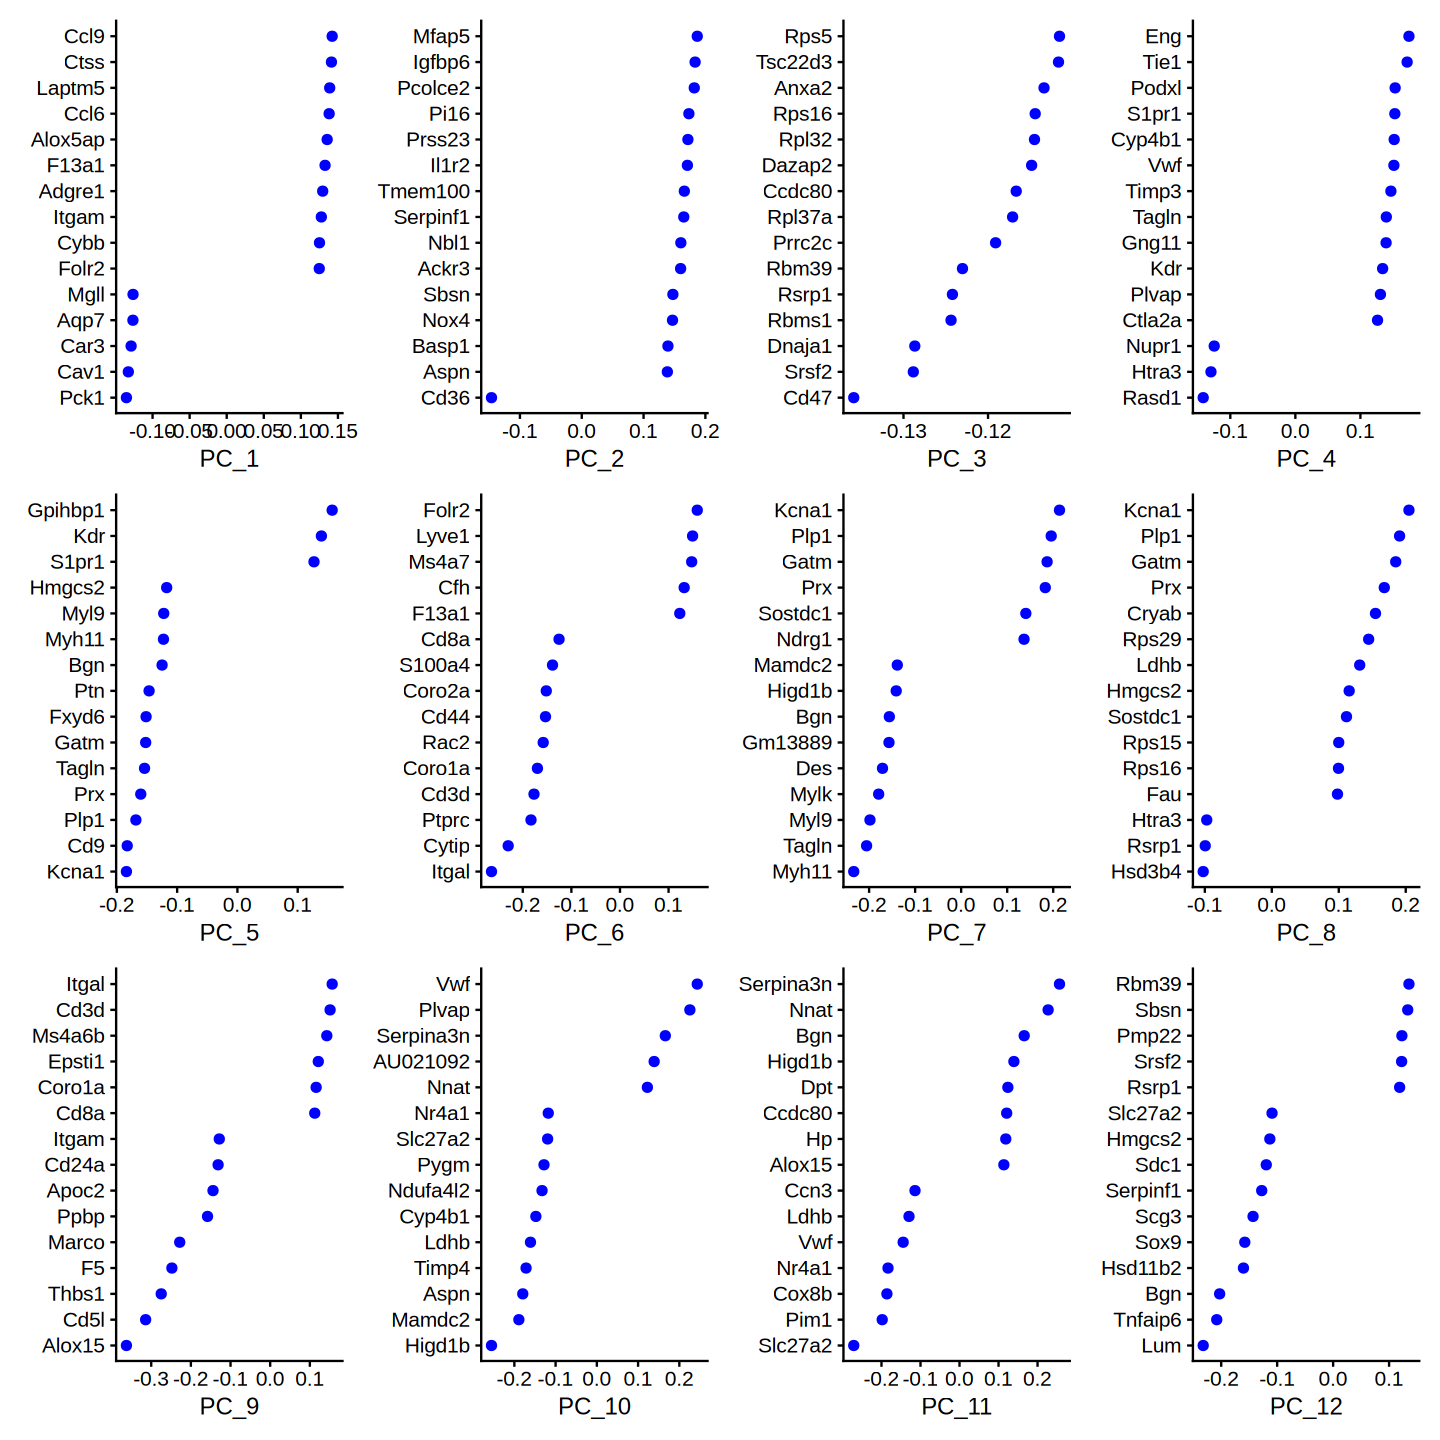

In [43]:
VizDimLoadings(
  region_spatial,
  dims = 1:12,
  reduction = "pca",
  nfeatures = 15
)

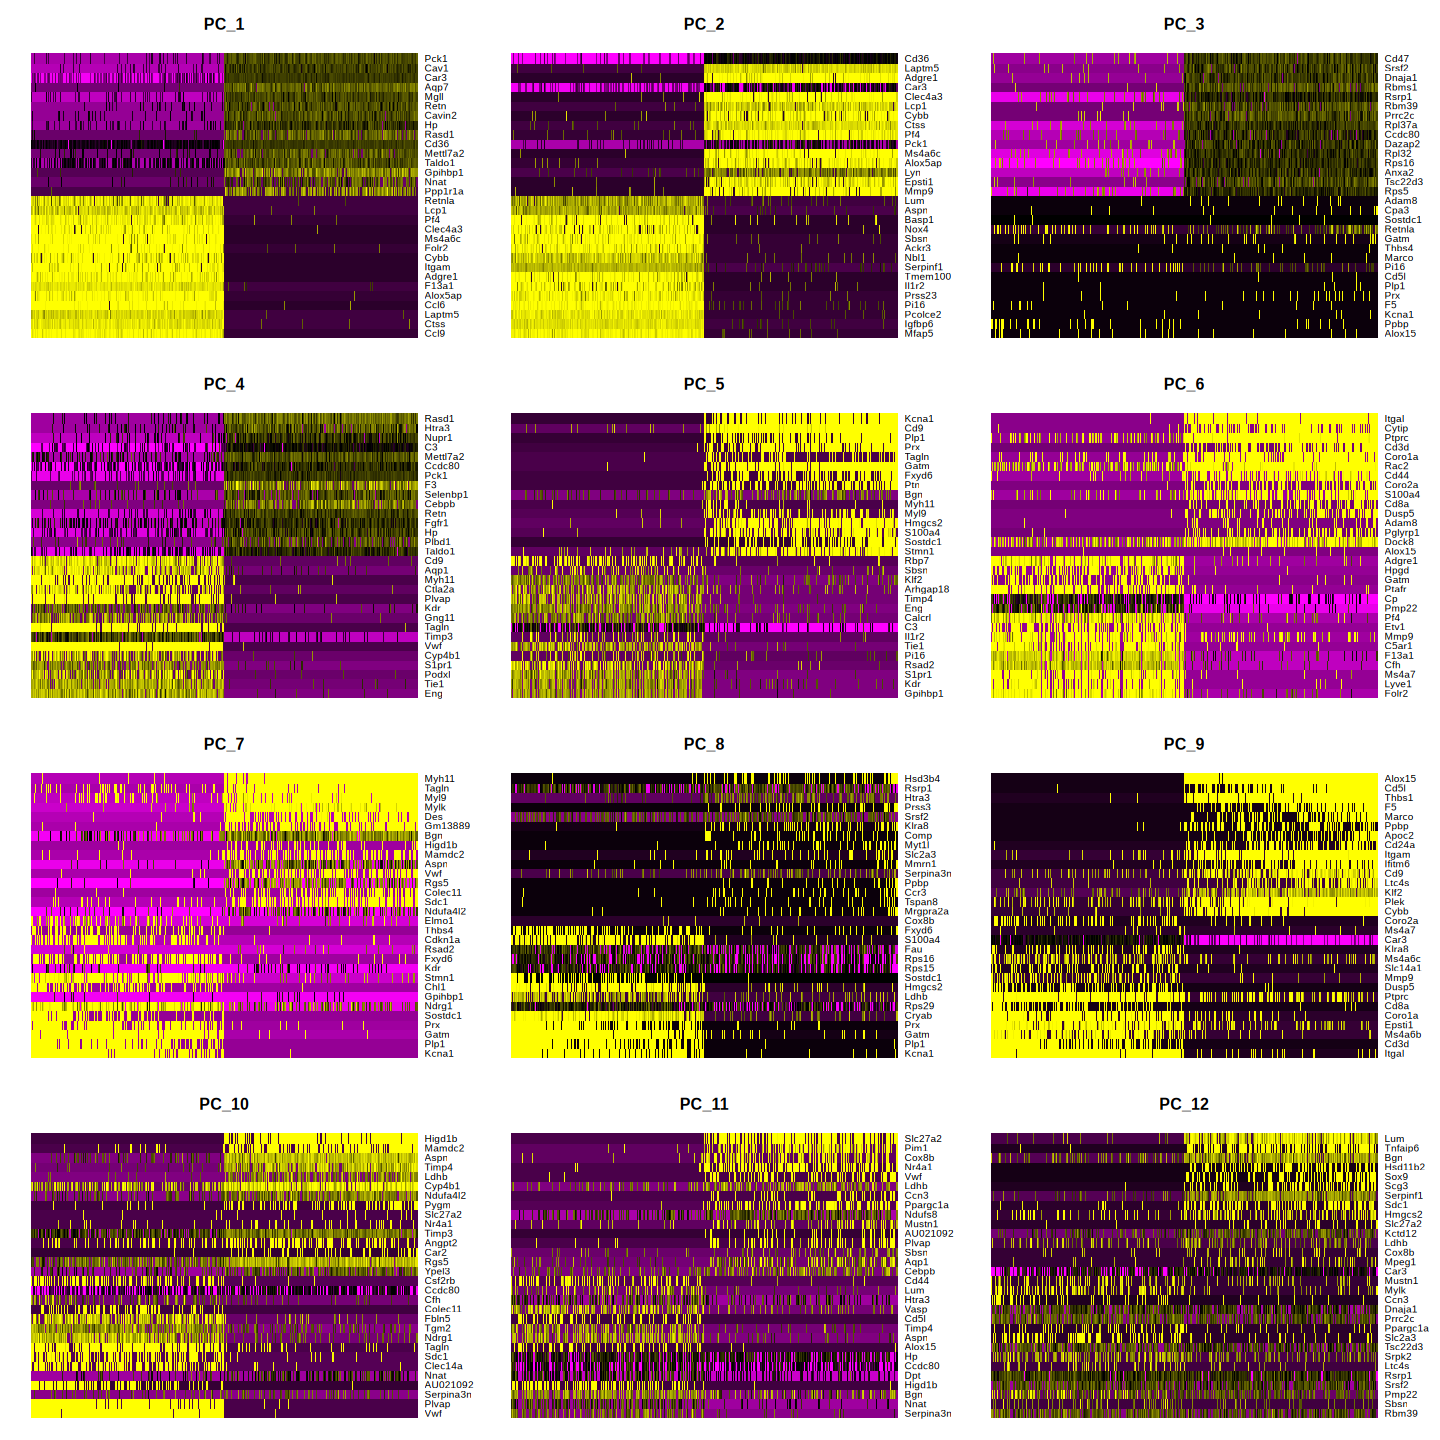

In [46]:
DimHeatmap(
  region_spatial,
  dims = 1:12,
  cells = 1000,
  balanced = TRUE
)

In [44]:
pcs <- Embeddings(
  region_spatial,
  reduction = "pca"
)

qc_vars <- c(
  "nCount_Xenium",
  "nFeature_Xenium",
  "cell_area"
)

qc_vars <- qc_vars[
  qc_vars %in% colnames(region_spatial@meta.data)
]

In [45]:
pc_qc_cor <- sapply(
  qc_vars,
  function(v) {
    apply(
      pcs,
      2,
      function(pc) {
        cor(
          pc,
          region_spatial@meta.data[[v]],
          method = "spearman",
          use = "pairwise.complete.obs"
        )
      }
    )
  }
)

round(pc_qc_cor, 3)

,nCount_Xenium,nFeature_Xenium,cell_area
PC_1,-0.039,0.170,-0.271
PC_2,-0.042,-0.113,0.065
PC_3,-0.850,-0.934,-0.422
PC_4,-0.297,-0.116,-0.406
PC_5,-0.024,-0.065,0.026
PC_6,-0.028,0.089,-0.148
PC_7,0.146,0.186,-0.005
PC_8,0.030,-0.053,0.201
PC_9,-0.265,-0.111,-0.358
PC_10,-0.018,-0.042,-0.019


PC3: highly negatively correlated with nCounts/nFeatures, could be removed

In [47]:
dims_use <- 1:30

PC1–PC12 are carrying structured, coherent biological programs rather than diffuse noise!

In [48]:
region_spatial <- FindNeighbors(
  region_spatial,
  reduction = "pca",
  dims = dims_use,
  k.param = 20,
  graph.name = c(
    "Xenium_nn_PC30",
    "Xenium_snn_PC30"
  ),
  verbose = FALSE
)

In [49]:
region_spatial <- RunUMAP(
  region_spatial,
  reduction = "pca",
  dims = dims_use,
  reduction.name = "umap_PC30",
  seed.use = 1234,
  verbose = FALSE
)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


In [51]:
resolutions <- c(
  0.7,
  0.8,
  1.0,
  1.2
)

for (res in resolutions) {
  print(res)
  region_spatial <- FindClusters(
    region_spatial,
    graph.name = "Xenium_snn_PC30",
    algorithm = 4,
    resolution = res,
    cluster.name = paste0(
      "cluster_res_",
      gsub("\\.", "_", res)
    ),
    random.seed = 1234,
    verbose = FALSE
  )
}

[1] 0.7
[1] 0.8
[1] 1
[1] 1.2


In [52]:
options(repr.plot.width=12, repr.plot.height=8)

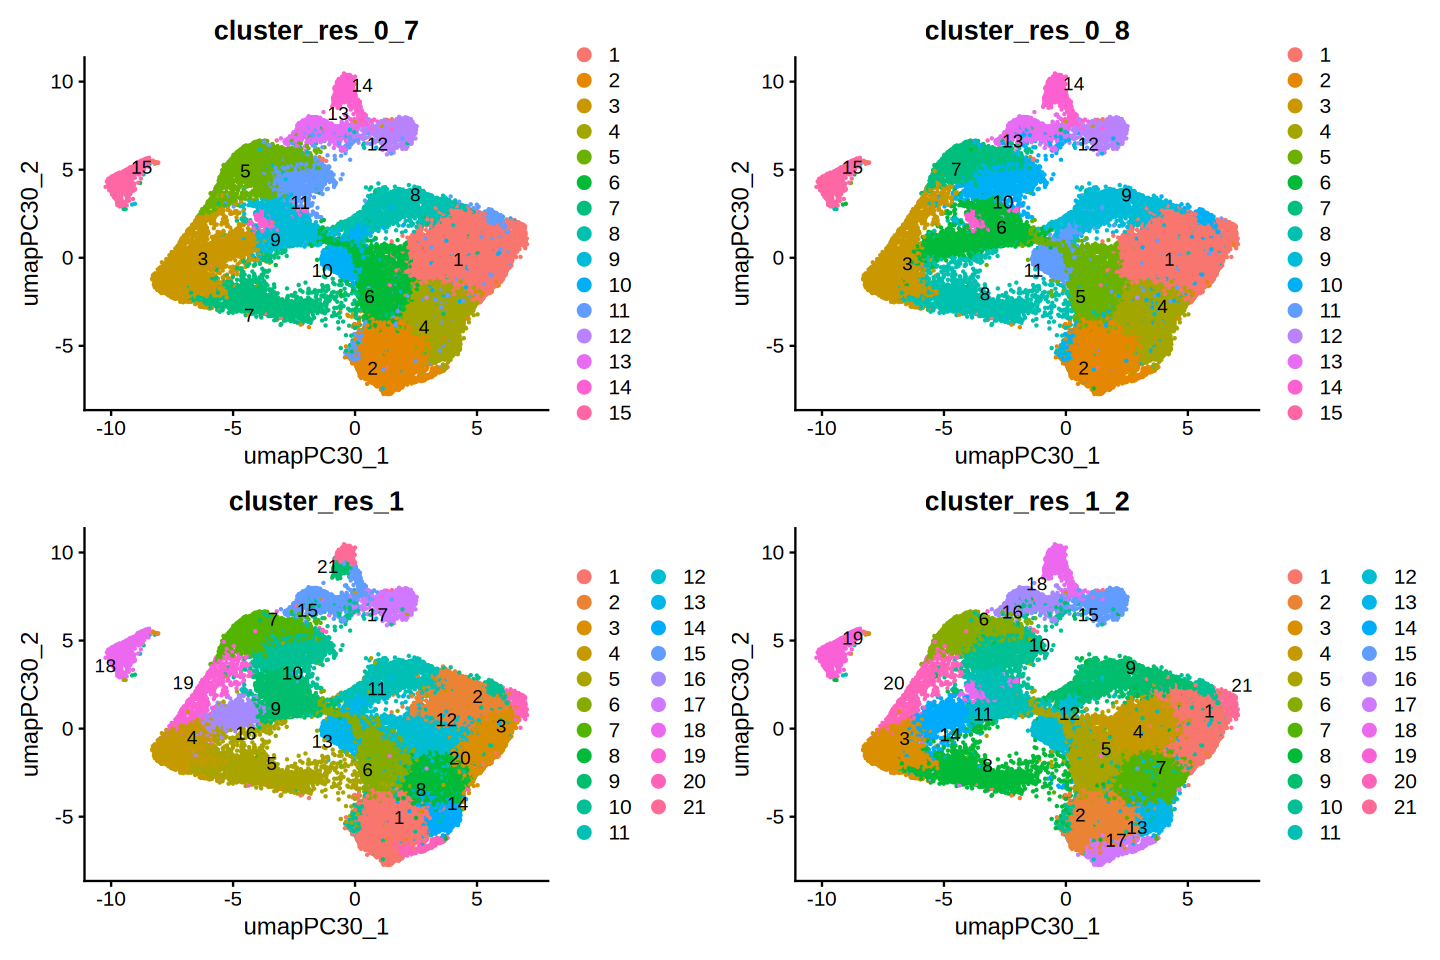

In [53]:
DimPlot(
  region_spatial,
  reduction = "umap_PC30",
  group.by = c(
    "cluster_res_0_7",
    "cluster_res_0_8",
    "cluster_res_1",
    "cluster_res_1_2"
  ),
  label = TRUE,
  repel = TRUE,
  ncol = 2
)

In [55]:
region_spatial

An object of class Seurat 
479 features across 48658 samples within 1 assay 
Active assay: Xenium (479 features, 0 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap_PC30
 1 spatial field of view present: fov

In [56]:
dim(region_spatial@meta.data)

[1] 48658    41

In [57]:
colnames(region_spatial@meta.data)

[1] "orig.ident"                    "nCount_Xenium"                
 [3] "nFeature_Xenium"               "x_centroid"                   
 [5] "y_centroid"                    "transcript_counts"            
 [7] "control_probe_counts"          "genomic_control_counts"       
 [9] "control_codeword_counts"       "unassigned_codeword_counts"   
[11] "deprecated_codeword_counts"    "total_counts"                 
[13] "cell_area"                     "nucleus_area"                 
[15] "nucleus_count"                 "segmentation_method"          
[17] "region_id"                     "control_fraction_cell"        
[19] "nucleus_missing_flag"          "multiple_nuclei_flag"         
[21] "cell_area_outlier_flag"        "high_control_flag"            
[23] "segmentation_multiplet_flag"   "qc_core_pass"                 
[25] "qc_review_flag"                "primary_include"              
[27] "strict_include"                "hotspot_review_cell"          
[29] "hotspot_sensitivity_include"   "section_status"               
[31] "mask_rule_primary"             "mask_rule_strict"             
[33] "mask_rule_hotspot_sensitivity" "provenance"                   
[35] "initial_qc_status"             "primary_include_revised"      
[37] "cluster_res_0_7"               "seurat_clusters"              
[39] "cluster_res_0_8"               "cluster_res_1"                
[41] "cluster_res_1_2"

In [54]:
saveRDS(region_spatial, file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_passQC.rds")))

## Step4 - Cell Type Annotataion M1 - By clustering scores

Try resolution 0.8

In [ ]:
region_spatial = readRDS(file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_passQC.rds")))

In [58]:
marker_df <- tibble::tribble(
  ~Gene_Symbol, ~CellType_main, ~CellType_subtype,

  "Gpihbp1", "Endothelial", "Capillary_EC",
  "Kdr",     "Endothelial", "Capillary_EC",

  "Vwf",     "Endothelial", "Venous_EC",
  "Plvap",   "Endothelial", "Venous_EC",

  "Mmrn1",   "Endothelial", "Lymphatic_EC",
  "Prox1",   "Endothelial", "Lymphatic_EC",
  "Lyve1",   "Endothelial", "Lymphatic_EC",

  "Pck1",    "Adipocyte", "Adipocyte",
  "Retn",    "Adipocyte", "Adipocyte",
  "Aqp7",    "Adipocyte", "Adipocyte",
  "Ppargc1a","Adipocyte", "Adipocyte",
  "Car3",    "Adipocyte", "Adipocyte",
  "Cd36",    "Adipocyte", "Adipocyte",

  "Pi16",    "Stromal_Fibroblast", "ASC",
  "Pcolce2", "Stromal_Fibroblast", "ASC",
  "Mfap5",   "Stromal_Fibroblast", "ASC",

  "Lum",     "Stromal_Fibroblast", "Fibroblast",
  "Serpinf1","Stromal_Fibroblast", "Fibroblast",
  "Bgn",     "Stromal_Fibroblast", "Fibroblast",
  "Dpt",     "Stromal_Fibroblast", "Fibroblast",
  "Aspn",    "Stromal_Fibroblast", "Fibroblast",
  "Ccdc80",  "Stromal_Fibroblast", "Fibroblast",

  "Tagln",   "Mural", "VSMC",
  "Myh11",   "Mural", "VSMC",
  "Cnn1",    "Mural", "VSMC",
  "Itga8",   "Mural", "VSMC",
  "Myl9",    "Mural", "VSMC",
  "Mylk",    "Mural", "VSMC",

  "Rgs5",    "Mural", "Pericyte",
  "Higd1b",  "Mural", "Pericyte",
  "Ndufa4l2","Mural", "Pericyte",
  "Myl9",    "Mural", "Pericyte",
  "Des",     "Mural", "Pericyte",
  "Timp3",   "Mural", "Pericyte",

  "Plp1",    "Neural", "Schwann",
  "Prx",     "Neural", "Schwann",
  "Pmp22",   "Neural", "Schwann",
  "Kcna1",   "Neural", "Schwann",
  "Chl1",    "Neural", "Schwann",

  "Pf4",     "Macrophage", "LYVE_macrophage",
  "Folr2",   "Macrophage", "LYVE_macrophage",
  "F13a1",   "Macrophage", "LYVE_macrophage",
  "C5ar1",   "Macrophage", "LYVE_macrophage",
  "Adgre1",  "Macrophage", "LYVE_macrophage",
  "Retnla",  "Macrophage", "LYVE_macrophage",
  "Lyve1",   "Macrophage", "LYVE_macrophage",
  "Ms4a7",   "Macrophage", "LYVE_macrophage",
  "Ccl6",    "Macrophage", "LYVE_macrophage",

  "Marco",   "Macrophage", "Scavenging_macrophage",
  "Mpeg1",   "Macrophage", "Scavenging_macrophage",
  "Cd5l",    "Macrophage", "Scavenging_macrophage",
  "Ms4a6c",  "Macrophage", "Scavenging_macrophage",
  "Lst1",    "Macrophage", "Scavenging_macrophage",

  "Cebpb",   "Monocyte", "Monocyte",
  "Ctss",    "Monocyte", "Monocyte",
  "Cd300a",  "Monocyte", "Monocyte",
  "Cybb",    "Monocyte", "Monocyte",

  "Csf3r",   "Neutrophil", "Neutrophil",
  "Cxcr2",   "Neutrophil", "Neutrophil",
  "Mmp9",    "Neutrophil", "Neutrophil",
  "Ctsg",    "Neutrophil", "Neutrophil",

  "Mrgpra2a",    "Mast cell", "MC",
  "Il1rl1",  "Mast cell", "MC",
  "Stfa2l1",  "Mast cell", "MC",
  "Cstdc4",  "Mast cell", "MC",
  "Asprv1",  "Mast cell", "MC",

  "Alox15",  "Eosinophil", "Eosinophil",
  "Siglecf", "Eosinophil", "Eosinophil",
  "Ccr3",    "Eosinophil", "Eosinophil",
  "Il5ra",   "Eosinophil", "Eosinophil",
  "Prg2",    "Eosinophil", "Eosinophil",
  "Ear1",    "Eosinophil", "Eosinophil",
  "Ear2",    "Eosinophil", "Eosinophil",

  "Cd3d",    "T cell", "T cell",
  "Cd8a",    "T cell", "T cell",
  "Ctla4",   "T cell", "T cell",
  "Epsti1",  "T cell", "T cell",

  "Itgal",   "NK", "NK",
  "Klra8",   "NK", "NK",

  "Basp1",   "DC", "DC",
  "Cytip",   "DC", "DC",
  "Adam8",   "DC", "DC",
  "Rab8b",   "DC", "DC",
  "Runx2",   "DC", "DC",

  "Plbd1",   "DC", "cDC",
  "Cd24a",   "DC", "cDC",
  "Psmb8",   "DC", "cDC",

    # leave B out as they are not good canonical markers 
  # "Slc25a37", "B cell", "B cell",
  # "Slc4a1", "B cell", "B cell",
  # "Cpa3", "B cell", "B cell",
 
  "Krt19",   "Mesothelial", "Mesothelial",
  "Cav1",    "Mesothelial", "Mesothelial",
  "Igfbp6",  "Mesothelial", "Mesothelial"
)
    
marker_df_use <- marker_df %>%
  filter(Gene_Symbol %in% rownames(region_spatial)) %>%
  distinct(Gene_Symbol, CellType_main, CellType_subtype)

In [59]:
table(marker_df_use$CellType_main)


         Adipocyte                 DC        Endothelial         Eosinophil 
                 6                  8                  7                  7 
        Macrophage          Mast cell        Mesothelial           Monocyte 
                14                  5                  3                  4 
             Mural             Neural         Neutrophil                 NK 
                12                  5                  4                  2 
Stromal_Fibroblast             T cell 
                 9                  4 

In [60]:
marker_coverage <- marker_df %>%
  mutate(Present = Gene_Symbol %in% rownames(region_spatial)) %>%
  group_by(CellType_main, CellType_subtype) %>%
  summarise(
    n_markers = n(),
    n_present = sum(Present),
    coverage = n_present / n_markers,
    genes_present = paste(Gene_Symbol[Present], collapse = ", "),
    .groups = "drop"
  ) %>%
  arrange(CellType_main, CellType_subtype)

marker_coverage

CellType_main,CellType_subtype,n_markers,n_present,coverage,genes_present
<chr>,<chr>,<int>,<int>,<dbl>,<chr>
Adipocyte,Adipocyte,6,6,1,"Pck1, Retn, Aqp7, Ppargc1a, Car3, Cd36"
DC,DC,5,5,1,"Basp1, Cytip, Adam8, Rab8b, Runx2"
DC,cDC,3,3,1,"Plbd1, Cd24a, Psmb8"
Endothelial,Capillary_EC,2,2,1,"Gpihbp1, Kdr"
Endothelial,Lymphatic_EC,3,3,1,"Mmrn1, Prox1, Lyve1"
Endothelial,Venous_EC,2,2,1,"Vwf, Plvap"
Eosinophil,Eosinophil,7,7,1,"Alox15, Siglecf, Ccr3, Il5ra, Prg2, Ear1, Ear2"
Macrophage,LYVE_macrophage,9,9,1,"Pf4, Folr2, F13a1, C5ar1, Adgre1, Retnla, Lyve1, Ms4a7, Ccl6"
Macrophage,Scavenging_macrophage,5,5,1,"Marco, Mpeg1, Cd5l, Ms4a6c, Lst1"


In [61]:
main_result <- score_marker_groups_by_cluster(
  object = region_spatial,
  marker_df = marker_df_use,
  group_col = "CellType_main",
  cluster_col = "cluster_res_0_8",
  assay = "Xenium",
  layer = "data",
  score_prefix = "MainScore",
  detect_prefix = "MainDetect",
  label_prefix = "Main"
)

region_spatial <- main_result$object

subtype_result <- score_marker_groups_by_cluster(
  object = region_spatial,
  marker_df = marker_df_use,
  group_col = "CellType_subtype",
  cluster_col = "cluster_res_0_8",
  assay = "Xenium",
  layer = "data",
  score_prefix = "SubtypeScore",
  detect_prefix = "SubtypeDetect",
  label_prefix = "Subtype"
)

region_spatial <- subtype_result$object

main_result$annotation
subtype_result$annotation

cluster_res_0_8,Main_label,Main_score,Main_second,Main_second_score,Main_margin
<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
1,Adipocyte,0.4769732,Endothelial,0.35829490,0.1186783
2,Adipocyte,0.7282171,Mesothelial,0.07043503,0.6577821
3,Stromal_Fibroblast,1.3295113,Mesothelial,0.19910452,1.1304068
4,Adipocyte,0.6536125,Mesothelial,-0.03196272,0.6855753
5,Adipocyte,0.3259021,Eosinophil,-0.11913641,0.4450385
6,Stromal_Fibroblast,0.1972640,Macrophage,-0.04276019,0.2400242
7,Macrophage,1.6890730,Monocyte,1.36845998,0.3206130
8,Stromal_Fibroblast,0.9461203,Mesothelial,0.36290659,0.5832137
9,Mural,0.8634486,Endothelial,0.56847514,0.2949735


cluster_res_0_8,Subtype_label,Subtype_score,Subtype_second,Subtype_second_score,Subtype_margin
<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
1,Capillary_EC,1.3819626,Adipocyte,0.47697321,0.9049894
2,Adipocyte,0.7282171,cDC,0.13841438,0.5898027
3,ASC,2.1640350,Fibroblast,0.91224943,1.2517856
4,Adipocyte,0.6536125,cDC,0.10958608,0.5440264
5,Adipocyte,0.3259021,Eosinophil,-0.11913641,0.4450385
6,ASC,0.7669290,LYVE_macrophage,0.02297119,0.7439578
7,LYVE_macrophage,2.1478221,Monocyte,1.36845998,0.7793621
8,Fibroblast,1.1601257,ASC,0.51810946,0.6420162
9,Venous_EC,1.7901617,VSMC,1.11439783,0.6757639


In [62]:
subtype_to_main <- marker_df_use %>%
  transmute(
    CellType_subtype = as.character(CellType_subtype),
    CellType_main = as.character(CellType_main),
    subtype_key = make.names(CellType_subtype)
  ) %>%
  distinct()

xenium_cluster_annotation <- subtype_result$annotation %>%
  mutate(
    subtype_key = make.names(as.character(Subtype_label))
  ) %>%
  rename(
    Xenium_cluster_subtype_score = Subtype_score,
    Xenium_cluster_subtype_second = Subtype_second,
    Xenium_cluster_subtype_second_score = Subtype_second_score,
    Xenium_cluster_subtype_margin = Subtype_margin
  ) %>%
  left_join(
    subtype_to_main,
    by = "subtype_key"
  ) %>%
  mutate(
    Xenium_cluster_subtype = CellType_subtype
  ) %>%
  select(
    -subtype_key,
    -CellType_subtype,
    -Subtype_label
  ) %>%
  rename(
    Xenium_cluster_main = CellType_main
  ) %>%
  left_join(
    main_result$annotation %>%
      transmute(
        cluster_res_0_8,
        Xenium_main_score_label = as.character(Main_label),
        Xenium_main_score = Main_score,
        Xenium_main_second = as.character(Main_second),
        Xenium_main_second_score = Main_second_score,
        Xenium_main_margin = Main_margin
      ),
    by = "cluster_res_0_8"
  )

In [63]:
xenium_cluster_annotation

cluster_res_0_8,Xenium_cluster_subtype_score,Xenium_cluster_subtype_second,Xenium_cluster_subtype_second_score,Xenium_cluster_subtype_margin,Xenium_cluster_main,Xenium_cluster_subtype,Xenium_main_score_label,Xenium_main_score,Xenium_main_second,Xenium_main_second_score,Xenium_main_margin
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
1,1.3819626,Adipocyte,0.47697321,0.9049894,Endothelial,Capillary_EC,Adipocyte,0.4769732,Endothelial,0.35829490,0.1186783
2,0.7282171,cDC,0.13841438,0.5898027,Adipocyte,Adipocyte,Adipocyte,0.7282171,Mesothelial,0.07043503,0.6577821
3,2.1640350,Fibroblast,0.91224943,1.2517856,Stromal_Fibroblast,ASC,Stromal_Fibroblast,1.3295113,Mesothelial,0.19910452,1.1304068
4,0.6536125,cDC,0.10958608,0.5440264,Adipocyte,Adipocyte,Adipocyte,0.6536125,Mesothelial,-0.03196272,0.6855753
5,0.3259021,Eosinophil,-0.11913641,0.4450385,Adipocyte,Adipocyte,Adipocyte,0.3259021,Eosinophil,-0.11913641,0.4450385
6,0.7669290,LYVE_macrophage,0.02297119,0.7439578,Stromal_Fibroblast,ASC,Stromal_Fibroblast,0.1972640,Macrophage,-0.04276019,0.2400242
7,2.1478221,Monocyte,1.36845998,0.7793621,Macrophage,LYVE_macrophage,Macrophage,1.6890730,Monocyte,1.36845998,0.3206130
8,1.1601257,ASC,0.51810946,0.6420162,Stromal_Fibroblast,Fibroblast,Stromal_Fibroblast,0.9461203,Mesothelial,0.36290659,0.5832137
9,1.7901617,VSMC,1.11439783,0.6757639,Endothelial,Venous_EC,Mural,0.8634486,Endothelial,0.56847514,0.2949735


In [64]:
# Safely attach cluster-level Xenium evidence to every cell.
# Remove prior versions of these columns before joining.

xenium_cols <- setdiff(
  colnames(xenium_cluster_annotation),
  "cluster_res_0_8"
)

region_spatial@meta.data <- region_spatial@meta.data %>%
  select(-any_of(xenium_cols))

meta_tmp <- region_spatial@meta.data %>%
  rownames_to_column("seurat_cell") %>%
  mutate(cluster_res_0_8 = as.character(cluster_res_0_8)) %>%
  left_join(
    xenium_cluster_annotation %>%
      mutate(cluster_res_0_8 = as.character(cluster_res_0_8)),
    by = "cluster_res_0_8"
  ) %>%
  column_to_rownames("seurat_cell")

stopifnot(
  identical(rownames(meta_tmp), colnames(region_spatial))
)

region_spatial@meta.data <- meta_tmp

In [65]:
colnames(region_spatial@meta.data )

[1] "orig.ident"                         
  [2] "nCount_Xenium"                      
  [3] "nFeature_Xenium"                    
  [4] "x_centroid"                         
  [5] "y_centroid"                         
  [6] "transcript_counts"                  
  [7] "control_probe_counts"               
  [8] "genomic_control_counts"             
  [9] "control_codeword_counts"            
 [10] "unassigned_codeword_counts"         
 [11] "deprecated_codeword_counts"         
 [12] "total_counts"                       
 [13] "cell_area"                          
 [14] "nucleus_area"                       
 [15] "nucleus_count"                      
 [16] "segmentation_method"                
 [17] "region_id"                          
 [18] "control_fraction_cell"              
 [19] "nucleus_missing_flag"               
 [20] "multiple_nuclei_flag"               
 [21] "cell_area_outlier_flag"             
 [22] "high_control_flag"                  
 [23] "segmentation_multiplet_flag"        
 [24] "qc_core_pass"                       
 [25] "qc_review_flag"                     
 [26] "primary_include"                    
 [27] "strict_include"                     
 [28] "hotspot_review_cell"                
 [29] "hotspot_sensitivity_include"        
 [30] "section_status"                     
 [31] "mask_rule_primary"                  
 [32] "mask_rule_strict"                   
 [33] "mask_rule_hotspot_sensitivity"      
 [34] "provenance"                         
 [35] "initial_qc_status"                  
 [36] "primary_include_revised"            
 [37] "cluster_res_0_7"                    
 [38] "seurat_clusters"                    
 [39] "cluster_res_0_8"                    
 [40] "cluster_res_1"                      
 [41] "cluster_res_1_2"                    
 [42] "MainScore_Endothelial"              
 [43] "MainScore_Adipocyte"                
 [44] "MainScore_Stromal_Fibroblast"       
 [45] "MainScore_Mural"                    
 [46] "MainScore_Neural"                   
 [47] "MainScore_Macrophage"               
 [48] "MainScore_Monocyte"                 
 [49] "MainScore_Neutrophil"               
 [50] "MainScore_Mast.cell"                
 [51] "MainScore_Eosinophil"               
 [52] "MainScore_T.cell"                   
 [53] "MainScore_NK"                       
 [54] "MainScore_DC"                       
 [55] "MainScore_Mesothelial"              
 [56] "MainDetect_Endothelial"             
 [57] "MainDetect_Adipocyte"               
 [58] "MainDetect_Stromal_Fibroblast"      
 [59] "MainDetect_Mural"                   
 [60] "MainDetect_Neural"                  
 [61] "MainDetect_Macrophage"              
 [62] "MainDetect_Monocyte"                
 [63] "MainDetect_Neutrophil"              
 [64] "MainDetect_Mast.cell"               
 [65] "MainDetect_Eosinophil"              
 [66] "MainDetect_T.cell"                  
 [67] "MainDetect_NK"                      
 [68] "MainDetect_DC"                      
 [69] "MainDetect_Mesothelial"             
 [70] "SubtypeScore_Capillary_EC"          
 [71] "SubtypeScore_Venous_EC"             
 [72] "SubtypeScore_Lymphatic_EC"          
 [73] "SubtypeScore_Adipocyte"             
 [74] "SubtypeScore_ASC"                   
 [75] "SubtypeScore_Fibroblast"            
 [76] "SubtypeScore_VSMC"                  
 [77] "SubtypeScore_Pericyte"              
 [78] "SubtypeScore_Schwann"               
 [79] "SubtypeScore_LYVE_macrophage"       
 [80] "SubtypeScore_Scavenging_macrophage" 
 [81] "SubtypeScore_Monocyte"              
 [82] "SubtypeScore_Neutrophil"            
 [83] "SubtypeScore_MC"                    
 [84] "SubtypeScore_Eosinophil"            
 [85] "SubtypeScore_T.cell"                
 [86] "SubtypeScore_NK"                    
 [87] "SubtypeScore_DC"                    
 [88] "SubtypeScore_cDC"                   
 [89] "SubtypeScore_Mesothelial"           
 [90] "SubtypeDetect_Capillary_EC"         
 [91] "SubtypeDetect_Venous_EC"           

In [66]:
dim(region_spatial@meta.data )

[1] 48658   120

In [67]:
options(repr.plot.width=16, repr.plot.height=6)

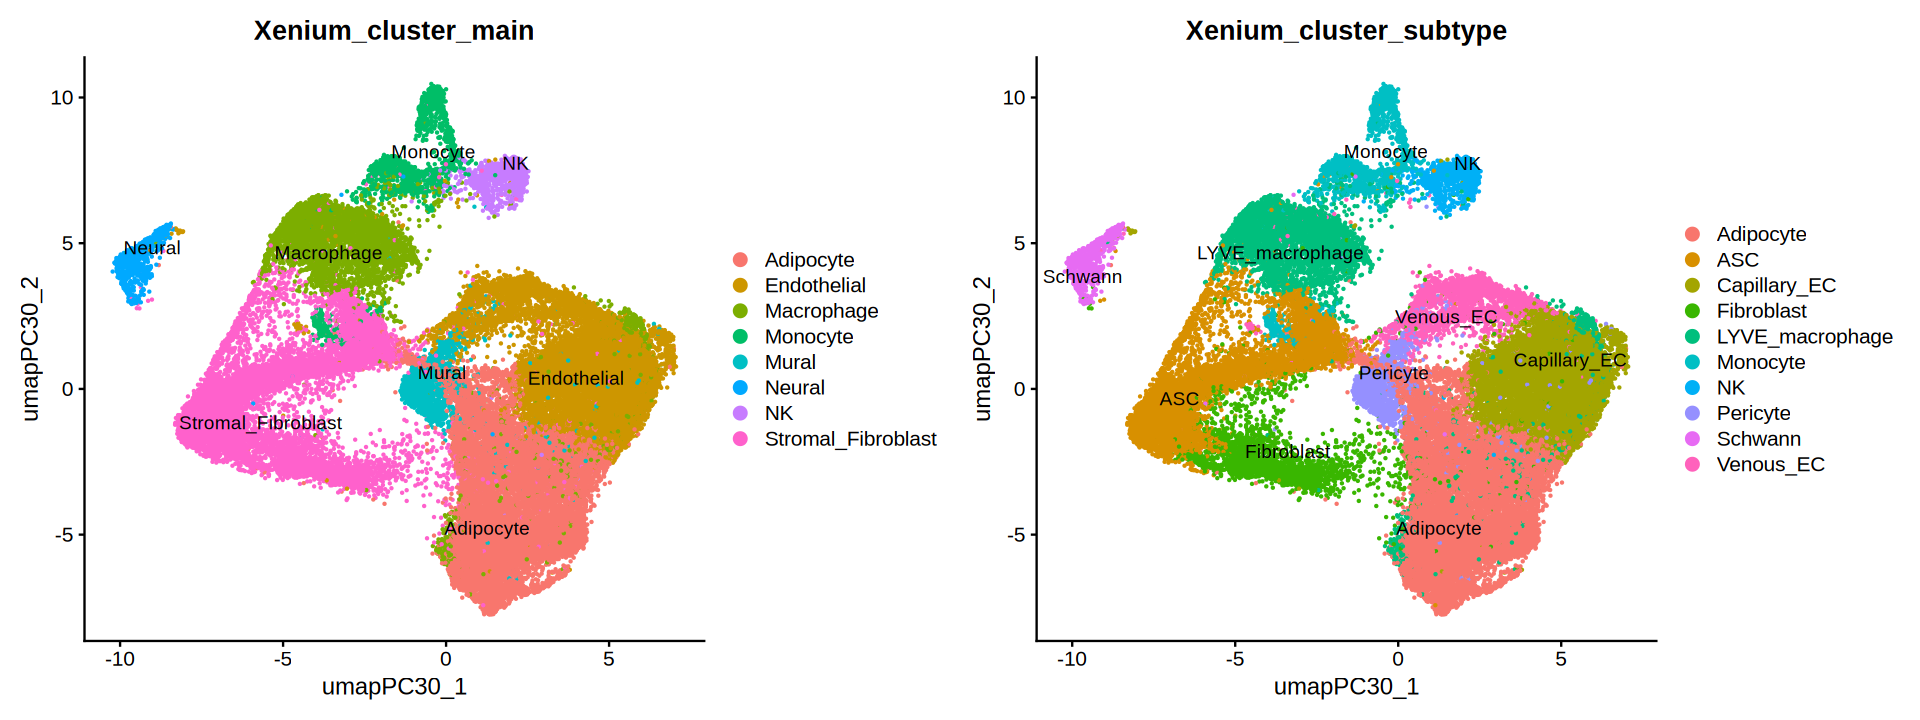

In [69]:
DimPlot(
  region_spatial,
  reduction = "umap_PC30",
  group.by = c("Xenium_cluster_main", "Xenium_cluster_subtype"),
  label = TRUE,
  repel = TRUE
)

In [73]:
options(repr.plot.width=16, repr.plot.height=16)

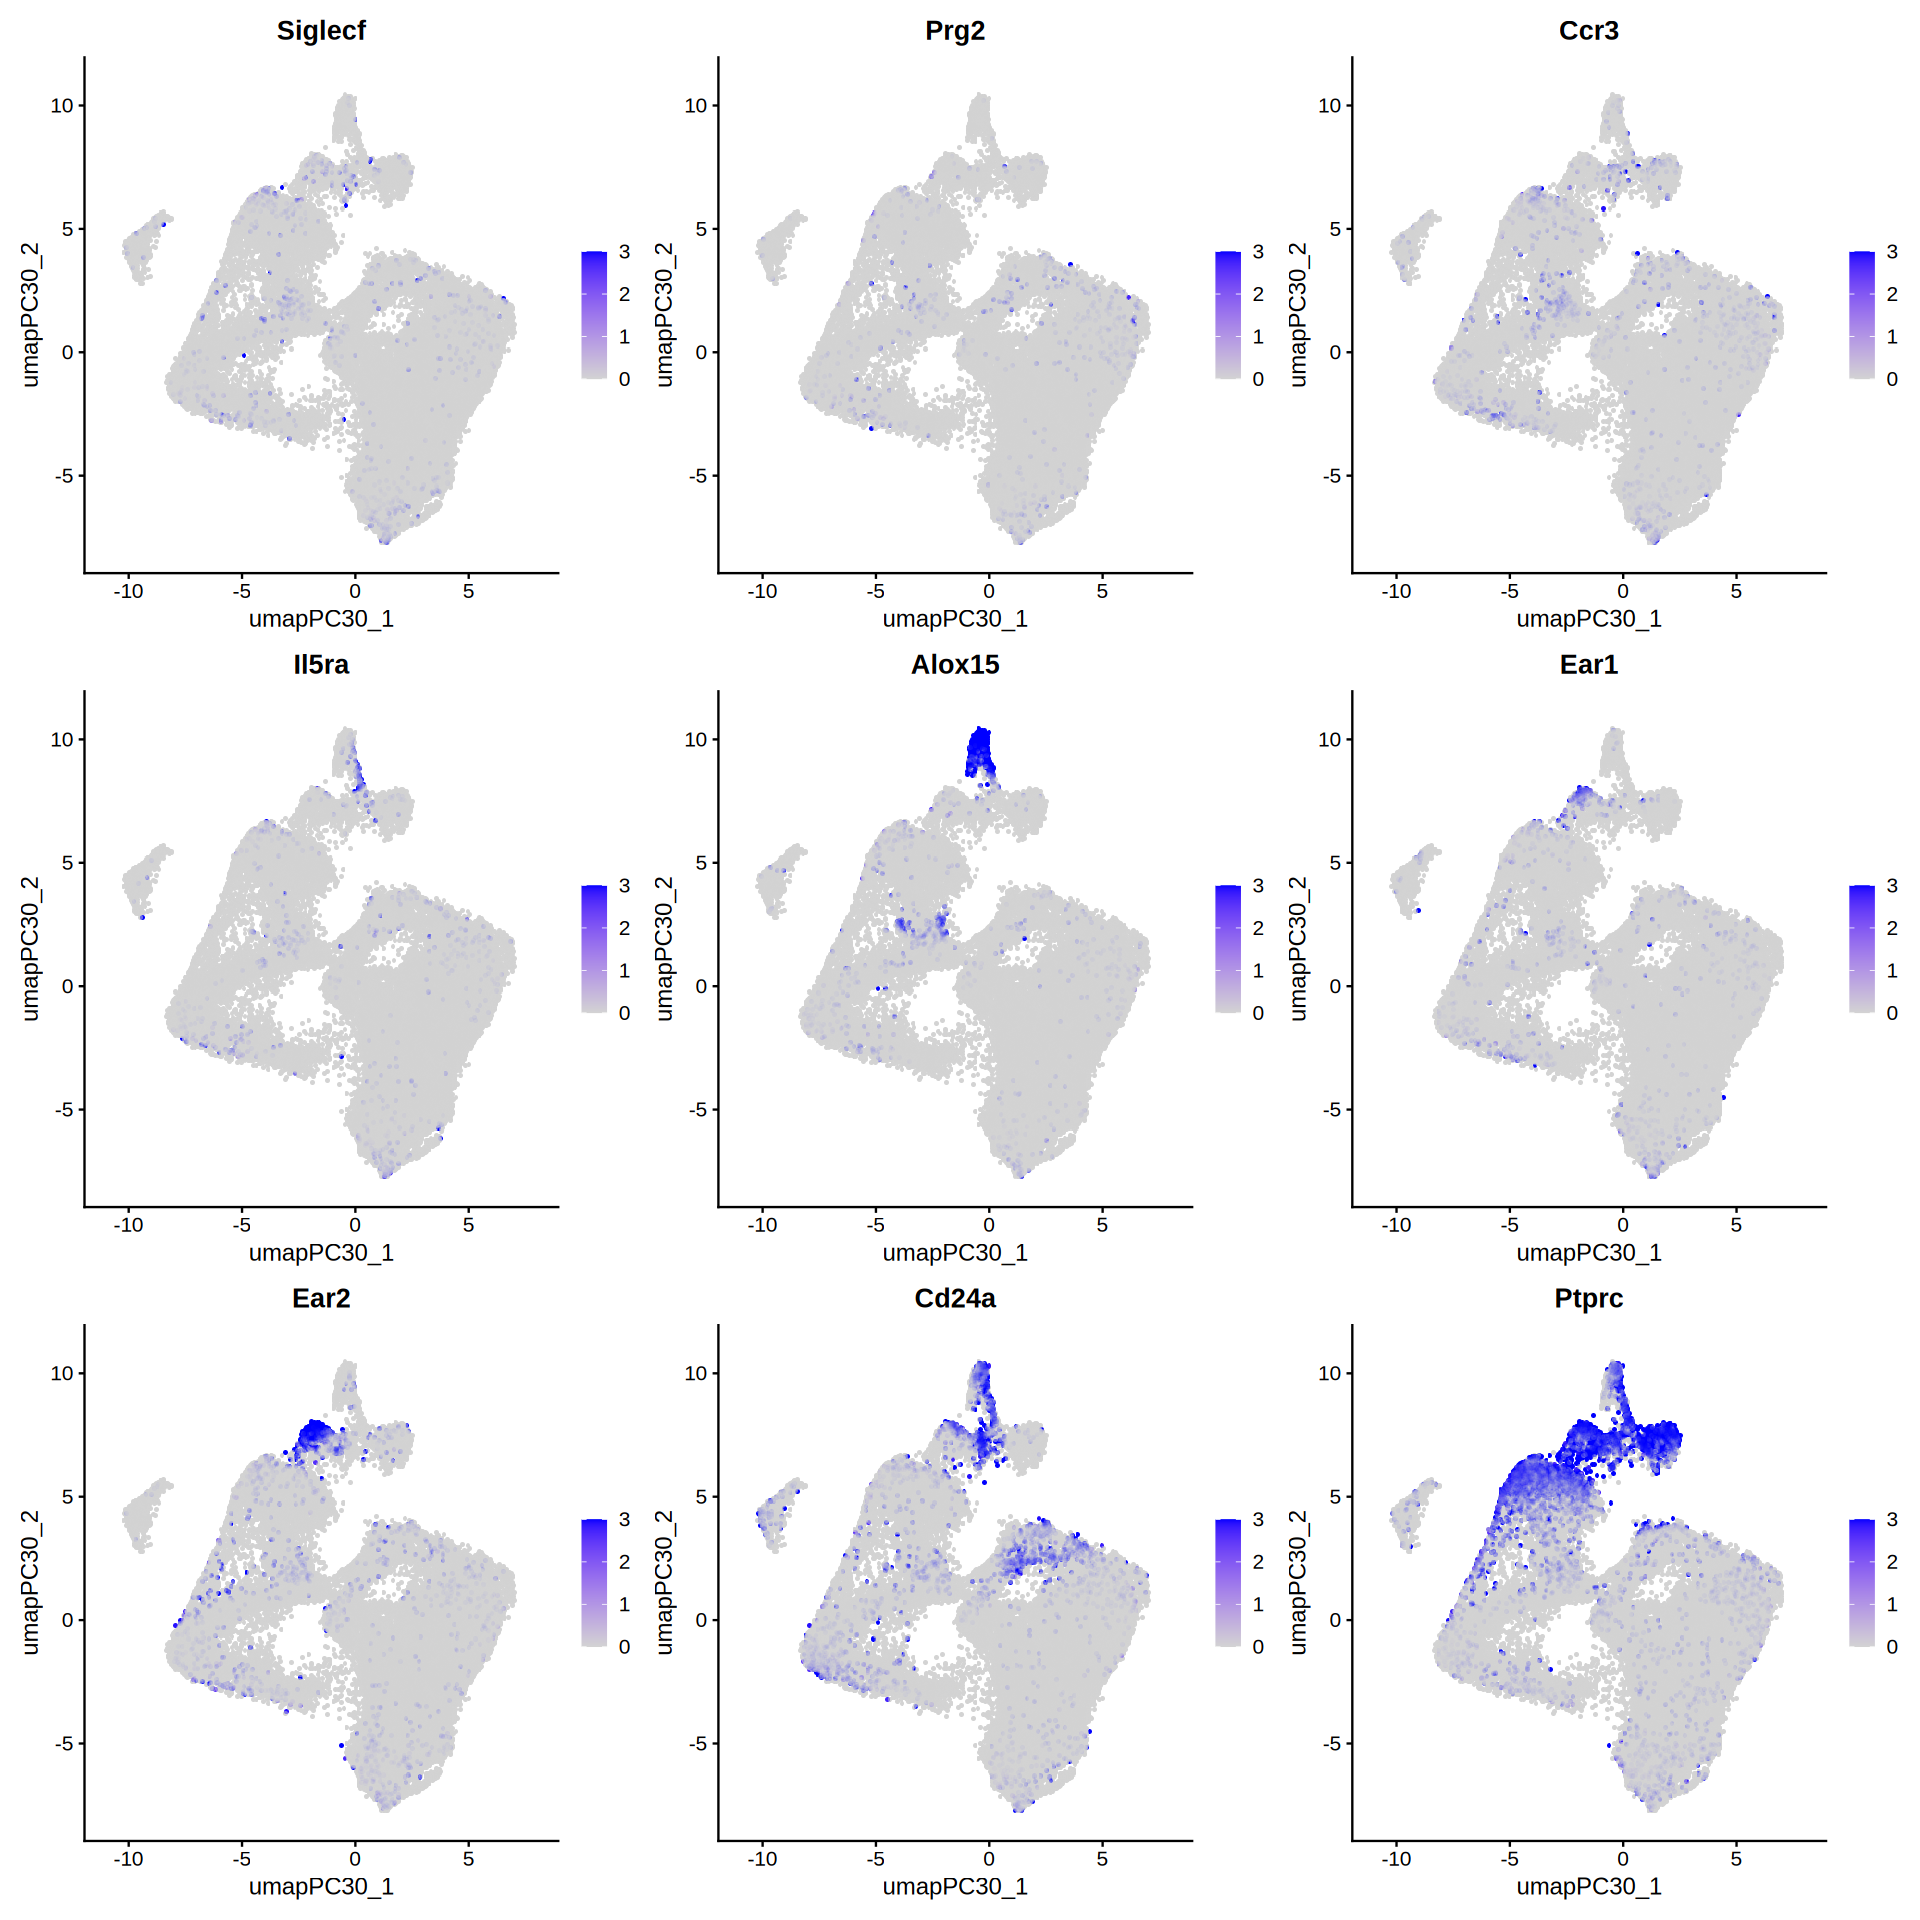

In [74]:
FeaturePlot(
    region_spatial,
    features = c(
        "Siglecf", "Prg2", "Ccr3",
        "Il5ra", "Alox15",
        "Ear1", "Ear2", "Cd24a", "Ptprc"
    ),
    reduction = "umap_PC30",
    raster = TRUE, 
    pt.size = 3, 
    max.cutoff = 3
)

In [75]:
saveRDS(region_spatial, file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_passQC.rds")))

## Step5 -  Cell Type Annotation M2 - By Reference

In [ ]:
region_spatial = readRDS(file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_passQC.rds")))

In [76]:
WANG_REFERENCE_PATH <- file.path(
  "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data",
  "Wang_Science2025_mouse_human",
  "analysis_mouse",
  "Wang_Science2025_cleaned_seurat.rds"
)

In [77]:
scwat_ref <- readRDS(WANG_REFERENCE_PATH)
DefaultAssay(scwat_ref) <- "RNA"

cat("Reference conditions:\n")
print(table(scwat_ref$Condition))

Reference conditions:

2.5 months  12 months 
     19252      21686 


In [78]:
scwat_ref$Wang_subtype_original <- as.character(
  scwat_ref$CellType_subtype
)

sort(unique(scwat_ref$Wang_subtype_original))

[1] "Arterial_EC"                "ASC"                       
 [3] "B"                          "Capillary_EC"              
 [5] "CCR2_inflammatory_Monocyte" "CCR7_migratory_DC"         
 [7] "cDC1"                       "cDC2"                      
 [9] "CP-1"                       "CP-2"                      
[11] "CP-A"                       "CX3CR1_Monocyte"           
[13] "Eosinophil"                 "Epithelial"                
[15] "IAP"                        "ILC2"                      
[17] "Inflammatory_Mac"           "LYVE1_resident_Mac"        
[19] "Mast cell"                  "MatureAdip"                
[21] "Mesothelial"                "Neutrophil"                
[23] "NK"                         "Pericyte"                  
[25] "Plasma"                     "RegFibro"                  
[27] "T"                          "TREM2_LAM"                 
[29] "γδ T"

In [79]:
# Explicit Wang subtype harmonization.
# Detailed immune labels are preserved.
# Closely related non-immune states are harmonized only for broad-lineage transfer.

wang_subtype_harmonization <- c(
  "ASC" = "ASC",
  "IAP" = "APC",
  "CP-1" = "APC",
  "CP-A" = "APC",
  "CP-2" = "APC",
  "RegFibro" = "APC",
  "MatureAdip" = "Adipocyte",
  "Pericyte" = "Mural",
  "Arterial_EC" = "Endothelial",
  "Capillary_EC" = "Endothelial",
  "Epithelial" = "Epithelial",
  "Mesothelial" = "Mesothelial",
  "T" = "T",
  "γδ T" = "γδ T",
  "NK" = "NK",
  "ILC2" = "ILC2",
  "B" = "B",
  "Plasma" = "Plasma",
  "CCR2_inflammatory_Monocyte" = "CCR2_inflammatory_Monocyte",
  "CX3CR1_Monocyte" = "CX3CR1_Monocyte",
  "Inflammatory_Mac" = "Inflammatory_Mac",
  "LYVE1_resident_Mac" = "LYVE1_resident_Mac",
  "TREM2_LAM" = "TREM2_LAM",
  "IFN_response_myeloid" = "IFN_response_myeloid",
  "cDC1" = "cDC1",
  "cDC2" = "cDC2",
  "CCR7_migratory_DC" = "CCR7_migratory_DC",
  "Neutrophil" = "Neutrophil",
  "Eosinophil" = "Eosinophil",
  "Mast cell" = "Mast cell"
)

unexpected_wang_labels <- setdiff(
  unique(scwat_ref$Wang_subtype_original),
  names(wang_subtype_harmonization)
)

if (length(unexpected_wang_labels)) {
  stop(
    "Unexpected Wang subtype labels. Review before proceeding: ",
    paste(unexpected_wang_labels, collapse = ", ")
  )
}

scwat_ref$Wang_subtype_harmonized <- unname(
  wang_subtype_harmonization[
    scwat_ref$Wang_subtype_original
  ]
)


In [80]:
scwat_ref$Wang_main <- case_when(
  scwat_ref$Wang_subtype_harmonized %in% c("ASC", "APC") ~ "Stromal_Fibroblast",
  scwat_ref$Wang_subtype_harmonized == "Mural" ~ "Mural",
  scwat_ref$Wang_subtype_harmonized == "Adipocyte" ~ "Adipocyte",
  scwat_ref$Wang_subtype_harmonized == "Endothelial" ~ "Endothelial",
  scwat_ref$Wang_subtype_harmonized == "Epithelial" ~ "Epithelial",
  scwat_ref$Wang_subtype_harmonized == "Mesothelial" ~ "Mesothelial",

  scwat_ref$Wang_subtype_harmonized %in% c("T", "γδ T") ~ "T cell",
  scwat_ref$Wang_subtype_harmonized == "NK" ~ "NK",
  scwat_ref$Wang_subtype_harmonized == "ILC2" ~ "ILC",
  scwat_ref$Wang_subtype_harmonized == "B" ~ "B cell",
  scwat_ref$Wang_subtype_harmonized == "Plasma" ~ "Plasma",

  scwat_ref$Wang_subtype_harmonized %in%
    c("CCR2_inflammatory_Monocyte", "CX3CR1_Monocyte") ~ "Monocyte",

  scwat_ref$Wang_subtype_harmonized %in%
    c("Inflammatory_Mac", "LYVE1_resident_Mac", "TREM2_LAM") ~ "Macrophage",

  scwat_ref$Wang_subtype_harmonized == "IFN_response_myeloid" ~ "Myeloid",

  scwat_ref$Wang_subtype_harmonized %in%
    c("cDC1", "cDC2", "CCR7_migratory_DC") ~ "DC",

  scwat_ref$Wang_subtype_harmonized == "Neutrophil" ~ "Neutrophil",
  scwat_ref$Wang_subtype_harmonized == "Eosinophil" ~ "Eosinophil",
  scwat_ref$Wang_subtype_harmonized == "Mast cell" ~ "Mast cell",

  TRUE ~ NA_character_
)

if (anyNA(scwat_ref$Wang_main)) {
  stop("Some Wang cells could not be mapped to the broad ontology.")
}

table(
  scwat_ref$Wang_main,
  scwat_ref$Wang_subtype_harmonized
)


                    
                     Adipocyte   APC   ASC     B CCR2_inflammatory_Monocyte
  Adipocyte                 40     0     0     0                          0
  B cell                     0     0     0  1241                          0
  DC                         0     0     0     0                          0
  Endothelial                0     0     0     0                          0
  Eosinophil                 0     0     0     0                          0
  Epithelial                 0     0     0     0                          0
  ILC                        0     0     0     0                          0
  Macrophage                 0     0     0     0                          0
  Mast cell                  0     0     0     0                          0
  Mesothelial                0     0     0     0                          0
  Monocyte                   0     0     0     0                       1256
  Mural                      0     0     0     0                   

In [ ]:
# saveRDS(scwat_ref,WANG_REFERENCE_PATH)

In [81]:
annotation_genes <- Reduce(
  intersect,
  list(
    FIX_GENESET,
    rownames(scwat_ref),
    rownames(region_spatial)
  )
)

cat("Annotation features:", length(annotation_genes), "\n")

if (length(annotation_genes) < 100) {
  stop("Too few shared identity genes for reliable transfer; review gene symbols/panel.")
}

# # Confirm short-/long-lived Eos state genes are excluded.
# stopifnot(
#   length(intersect(annotation_genes, eos_state_genes)) == 0
# )

Annotation features: 467 


In [83]:
ref_2p5 <- subset(
  scwat_ref,
  subset = Condition == "2.5 months"
)

ref_all <- scwat_ref

In [84]:
table(
  ref_2p5$Wang_subtype_harmonized
)

table(
  ref_all$Wang_subtype_harmonized
)


                 Adipocyte                        APC 
                        31                       6125 
                       ASC                          B 
                      1524                        715 
CCR2_inflammatory_Monocyte          CCR7_migratory_DC 
                       653                         39 
                      cDC1                       cDC2 
                       465                        158 
           CX3CR1_Monocyte                Endothelial 
                       181                        917 
                Eosinophil                 Epithelial 
                        19                        413 
                      ILC2           Inflammatory_Mac 
                       473                        357 
        LYVE1_resident_Mac                  Mast cell 
                      3200                         28 
               Mesothelial                      Mural 
                       550                        827 
         


                 Adipocyte                        APC 
                        40                      14240 
                       ASC                          B 
                      6049                       1241 
CCR2_inflammatory_Monocyte          CCR7_migratory_DC 
                      1256                        113 
                      cDC1                       cDC2 
                       845                        247 
           CX3CR1_Monocyte                Endothelial 
                       570                       1319 
                Eosinophil                 Epithelial 
                       180                        625 
                      ILC2           Inflammatory_Mac 
                       751                        628 
        LYVE1_resident_Mac                  Mast cell 
                      5092                         52 
               Mesothelial                      Mural 
                      1856                       1628 
         

In [85]:
length(annotation_genes)

[1] 467

In [86]:
transfer_2p5 <- run_wang_transfer(
  reference = ref_2p5,
  query = region_spatial,
  annotation_genes = annotation_genes,
  prefix = "Ref2p5"
)

transfer_all <- run_wang_transfer(
  reference = ref_all,
  query = region_spatial,
  annotation_genes = annotation_genes,
  prefix = "RefAll"
)

Ref2p5: using 467 shared annotation genes

Warning message:
“Number of dimensions changing from 50 to 30”
RefAll: using 467 shared annotation genes

Warning message:
“Number of dimensions changing from 50 to 30”


In [87]:
region_spatial <- AddMetaData(
  region_spatial,
  metadata = transfer_2p5$main
)

region_spatial <- AddMetaData(
  region_spatial,
  metadata = transfer_2p5$subtype
)

region_spatial <- AddMetaData(
  region_spatial,
  metadata = transfer_all$main
)

region_spatial <- AddMetaData(
  region_spatial,
  metadata = transfer_all$subtype
)

In [89]:
dim(region_spatial@meta.data)

[1] 48658   210

In [90]:
saveRDS(region_spatial, file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_passQC.rds")))

In [88]:
table(
  region_spatial$RefAll_subtype_predicted.id
)


                 Adipocyte                        APC 
                      8133                      10845 
                       ASC                          B 
                      5565                        217 
CCR2_inflammatory_Monocyte                       cDC1 
                       512                        196 
                      cDC2            CX3CR1_Monocyte 
                       147                        195 
               Endothelial                 Eosinophil 
                     12889                         64 
                Epithelial                       ILC2 
                       128                         64 
          Inflammatory_Mac         LYVE1_resident_Mac 
                       590                       4999 
                 Mast cell                Mesothelial 
                        49                        601 
                     Mural                 Neutrophil 
                      2386                         35 
         

In [91]:
options(repr.plot.width=15, repr.plot.height=15)

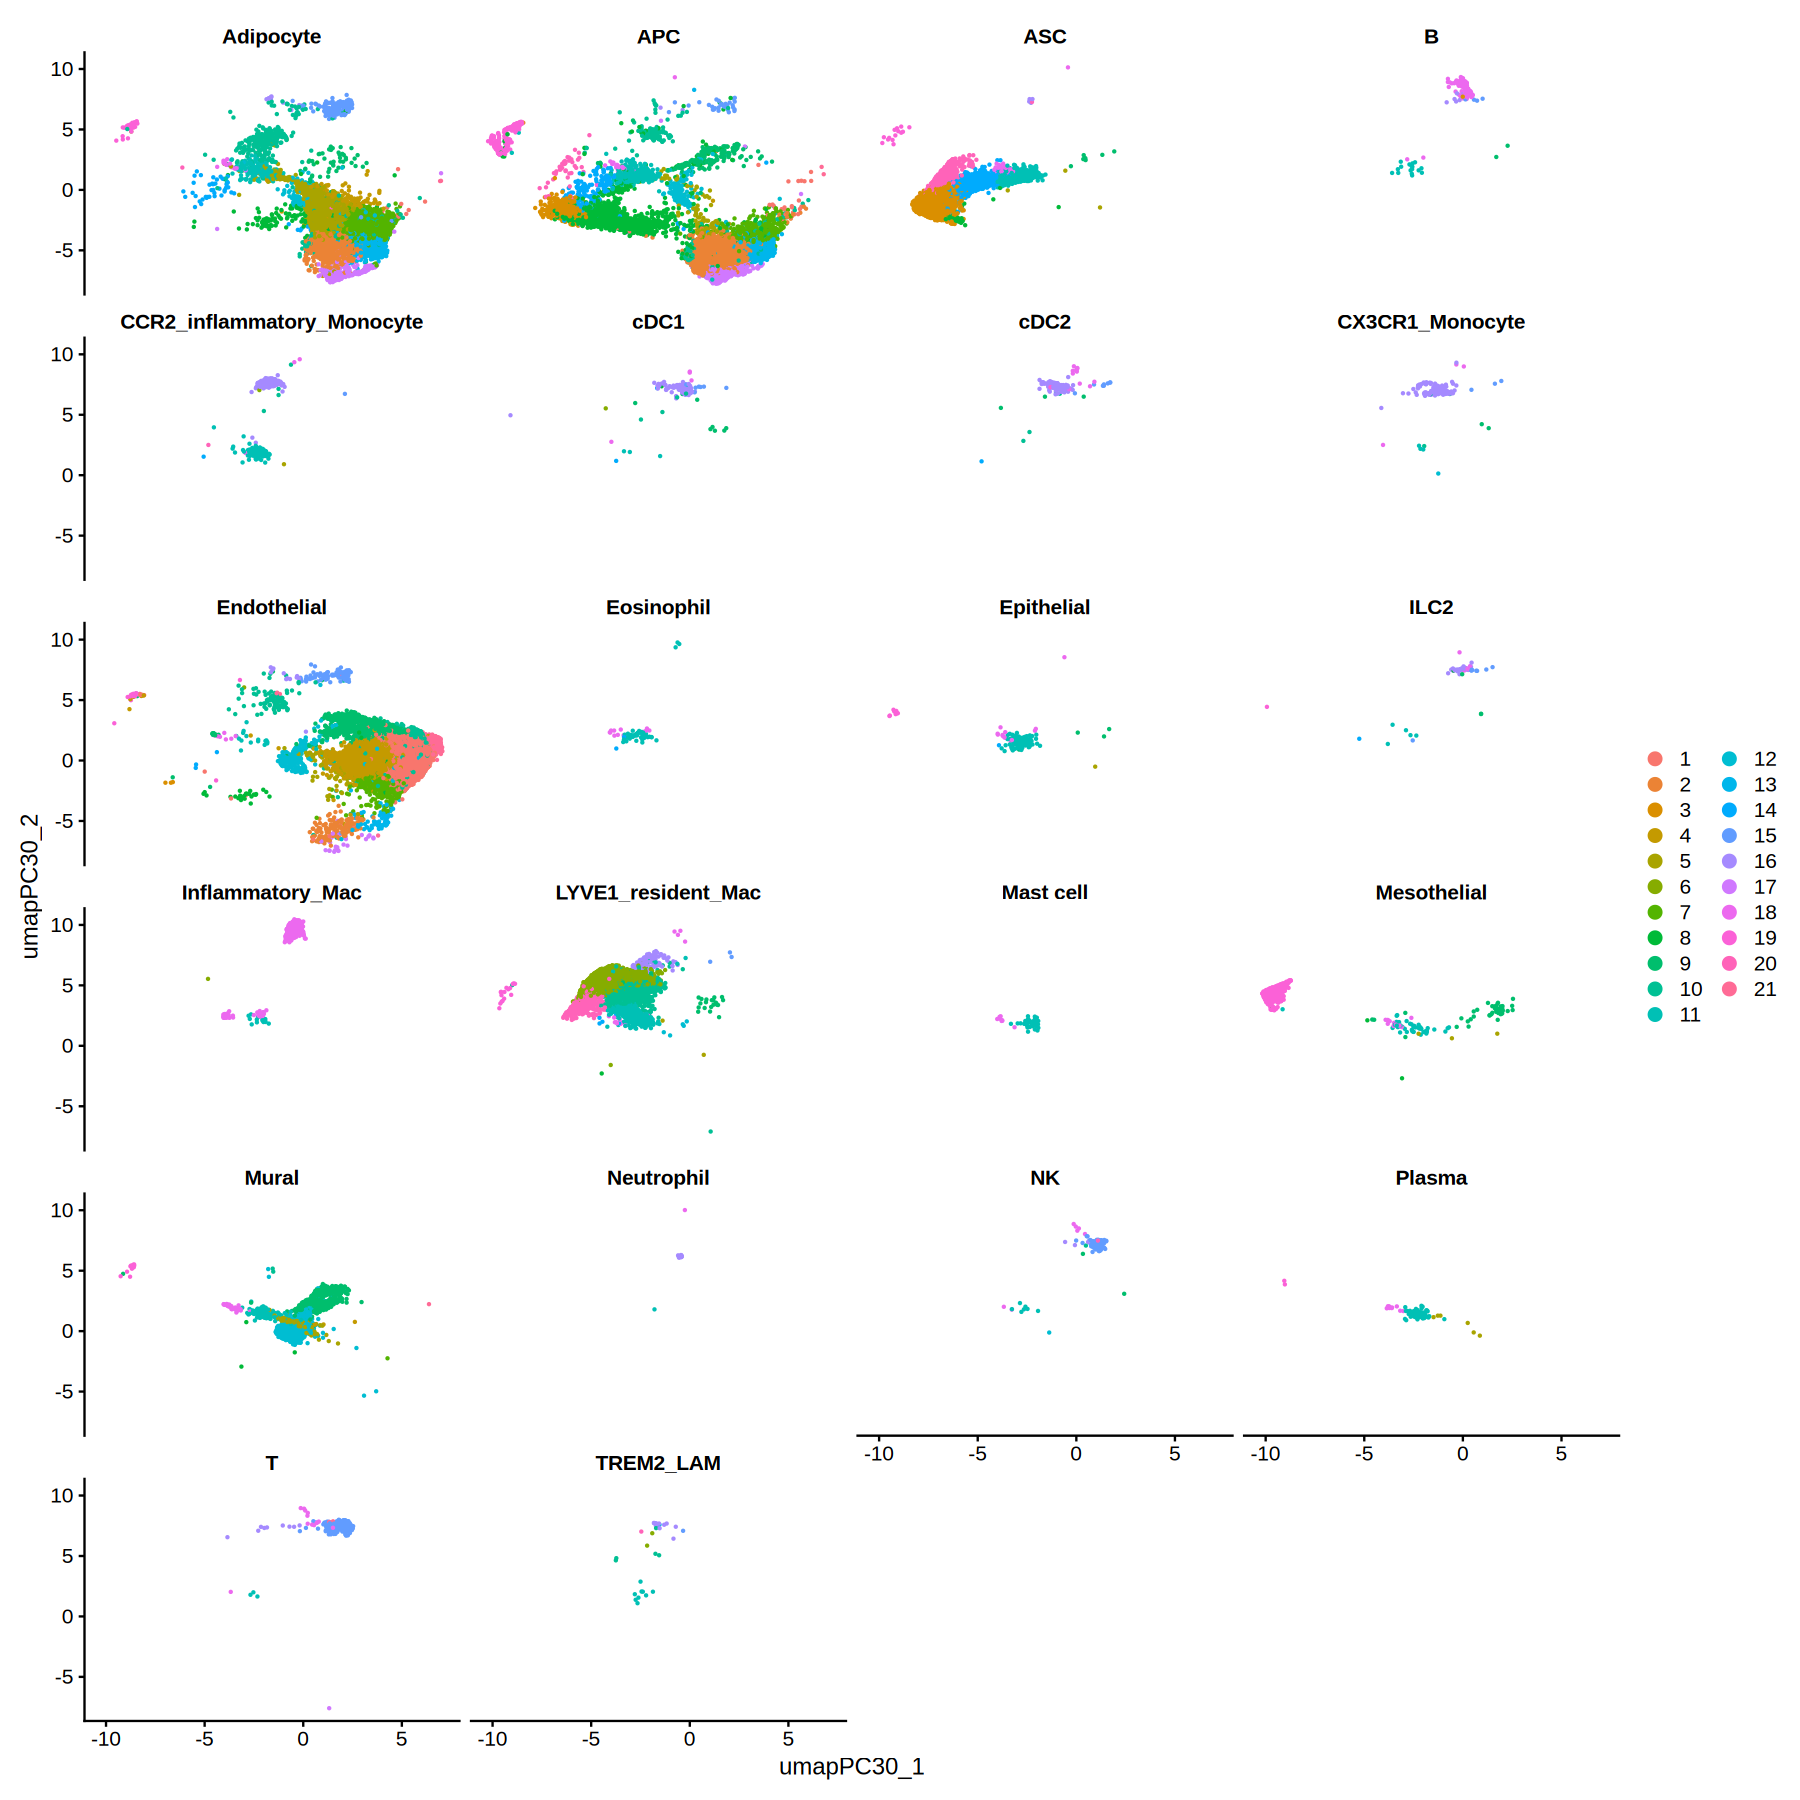

In [92]:
DimPlot(
  region_spatial,
  reduction = "umap_PC30",
  split.by = "RefAll_subtype_predicted.id",
  ncol=4
)

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


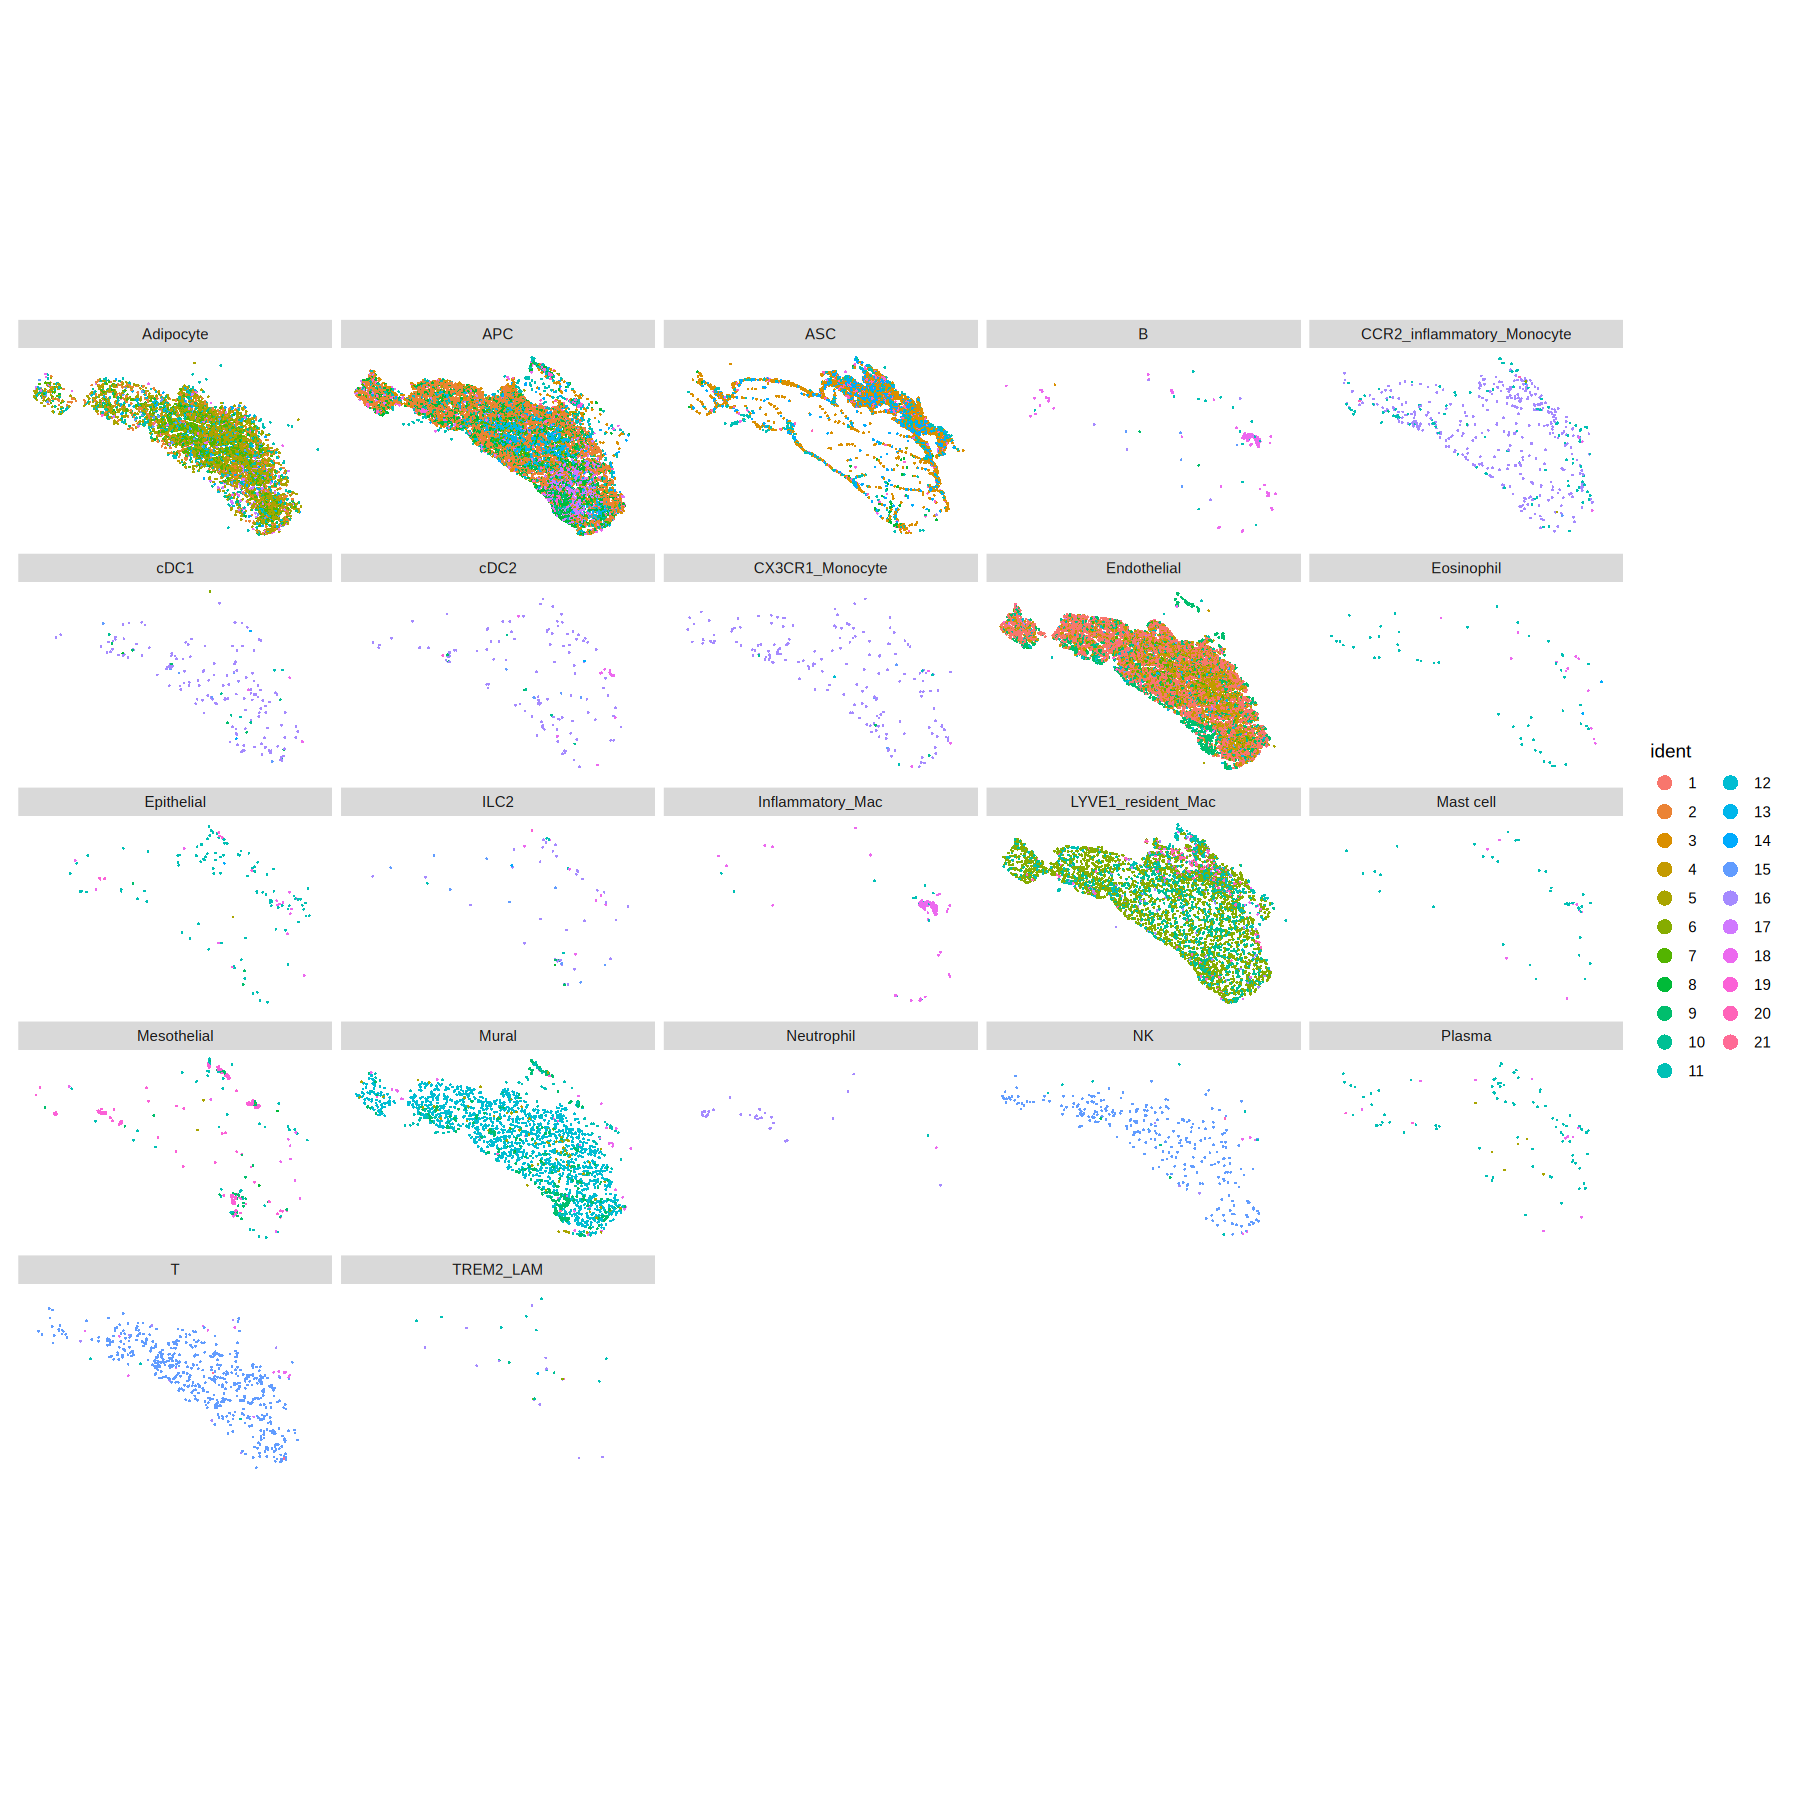

In [93]:
ImageDimPlot(
  region_spatial,
  fov = "fov",
  split.by = "RefAll_subtype_predicted.id",
  flip_xy = FALSE,
  dark.background = FALSE
)

In [94]:
options(repr.plot.width=15, repr.plot.height=10)

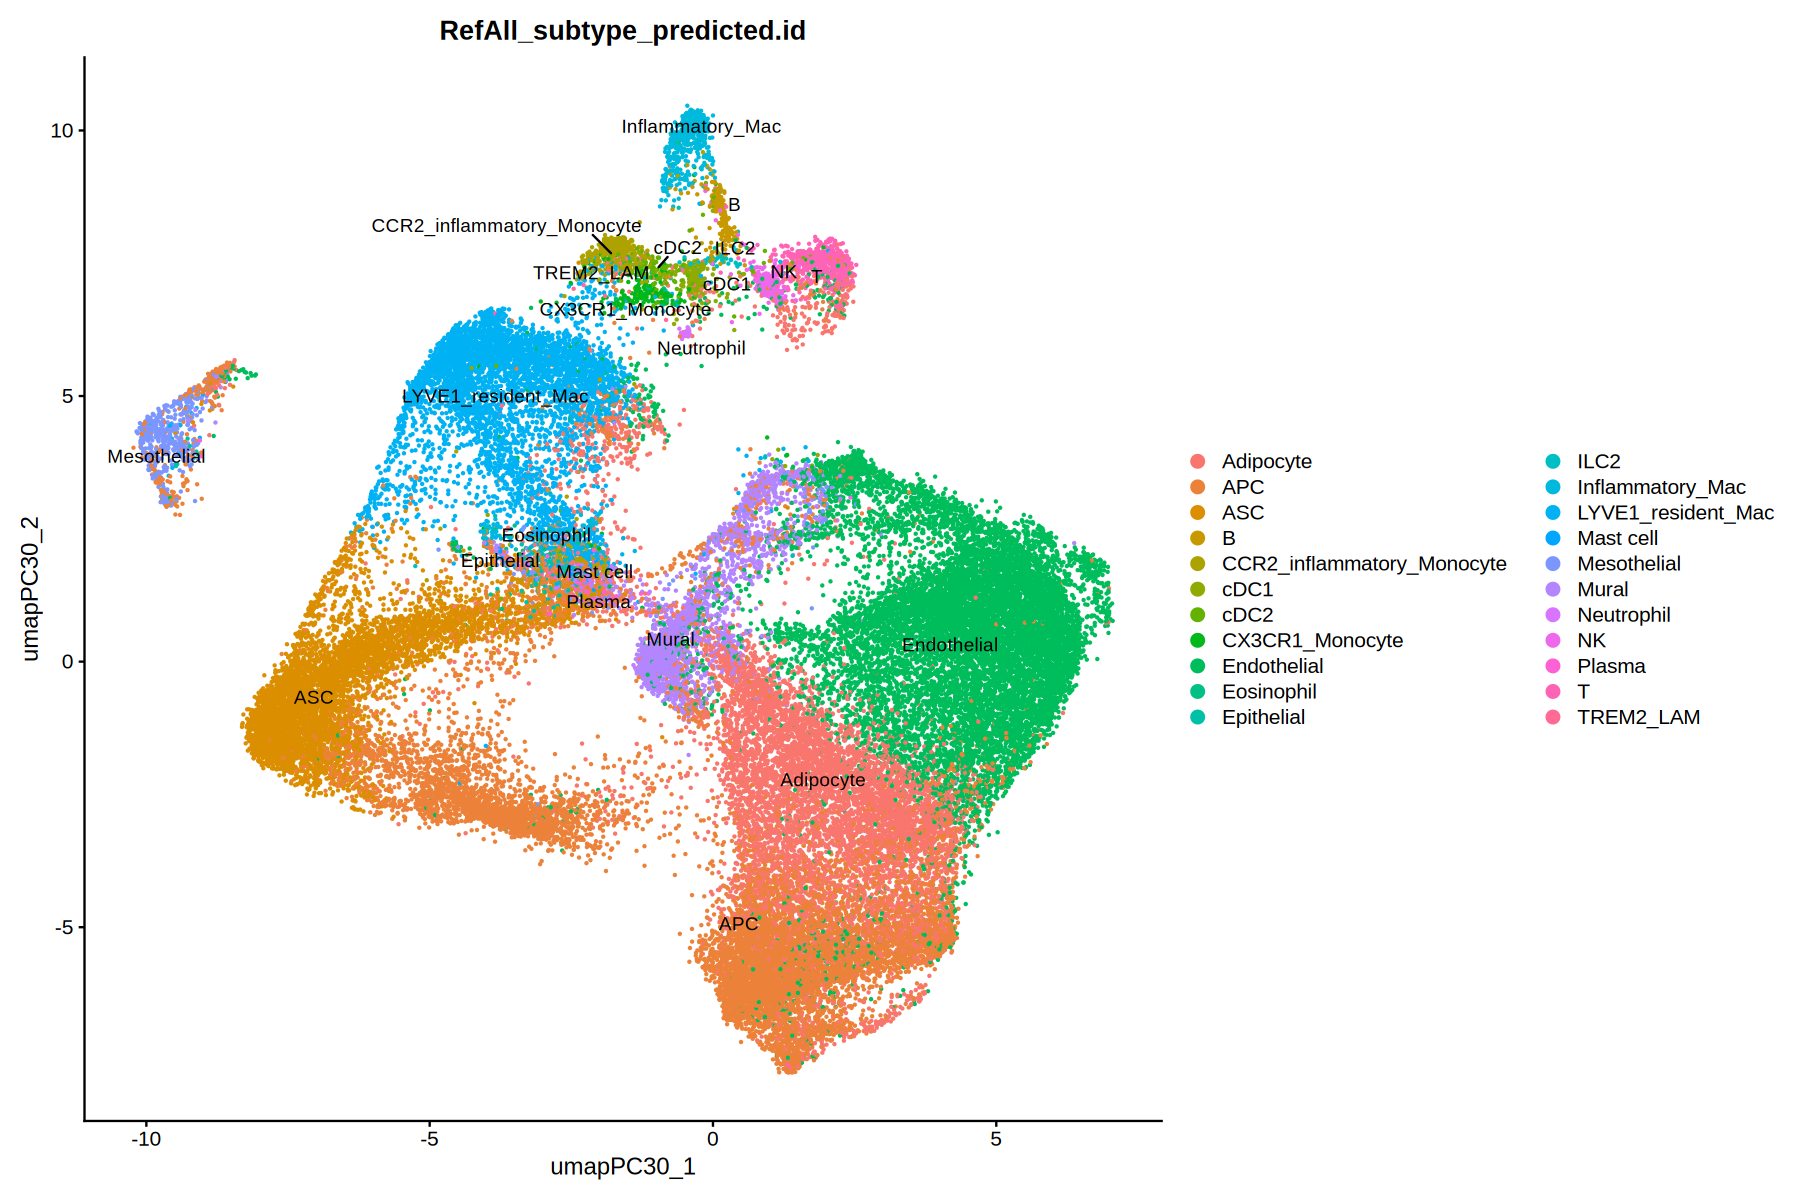

In [95]:
DimPlot(
  region_spatial,
  reduction = "umap_PC30",
  group.by = c("RefAll_subtype_predicted.id"),
  label = TRUE,
  repel = TRUE
)

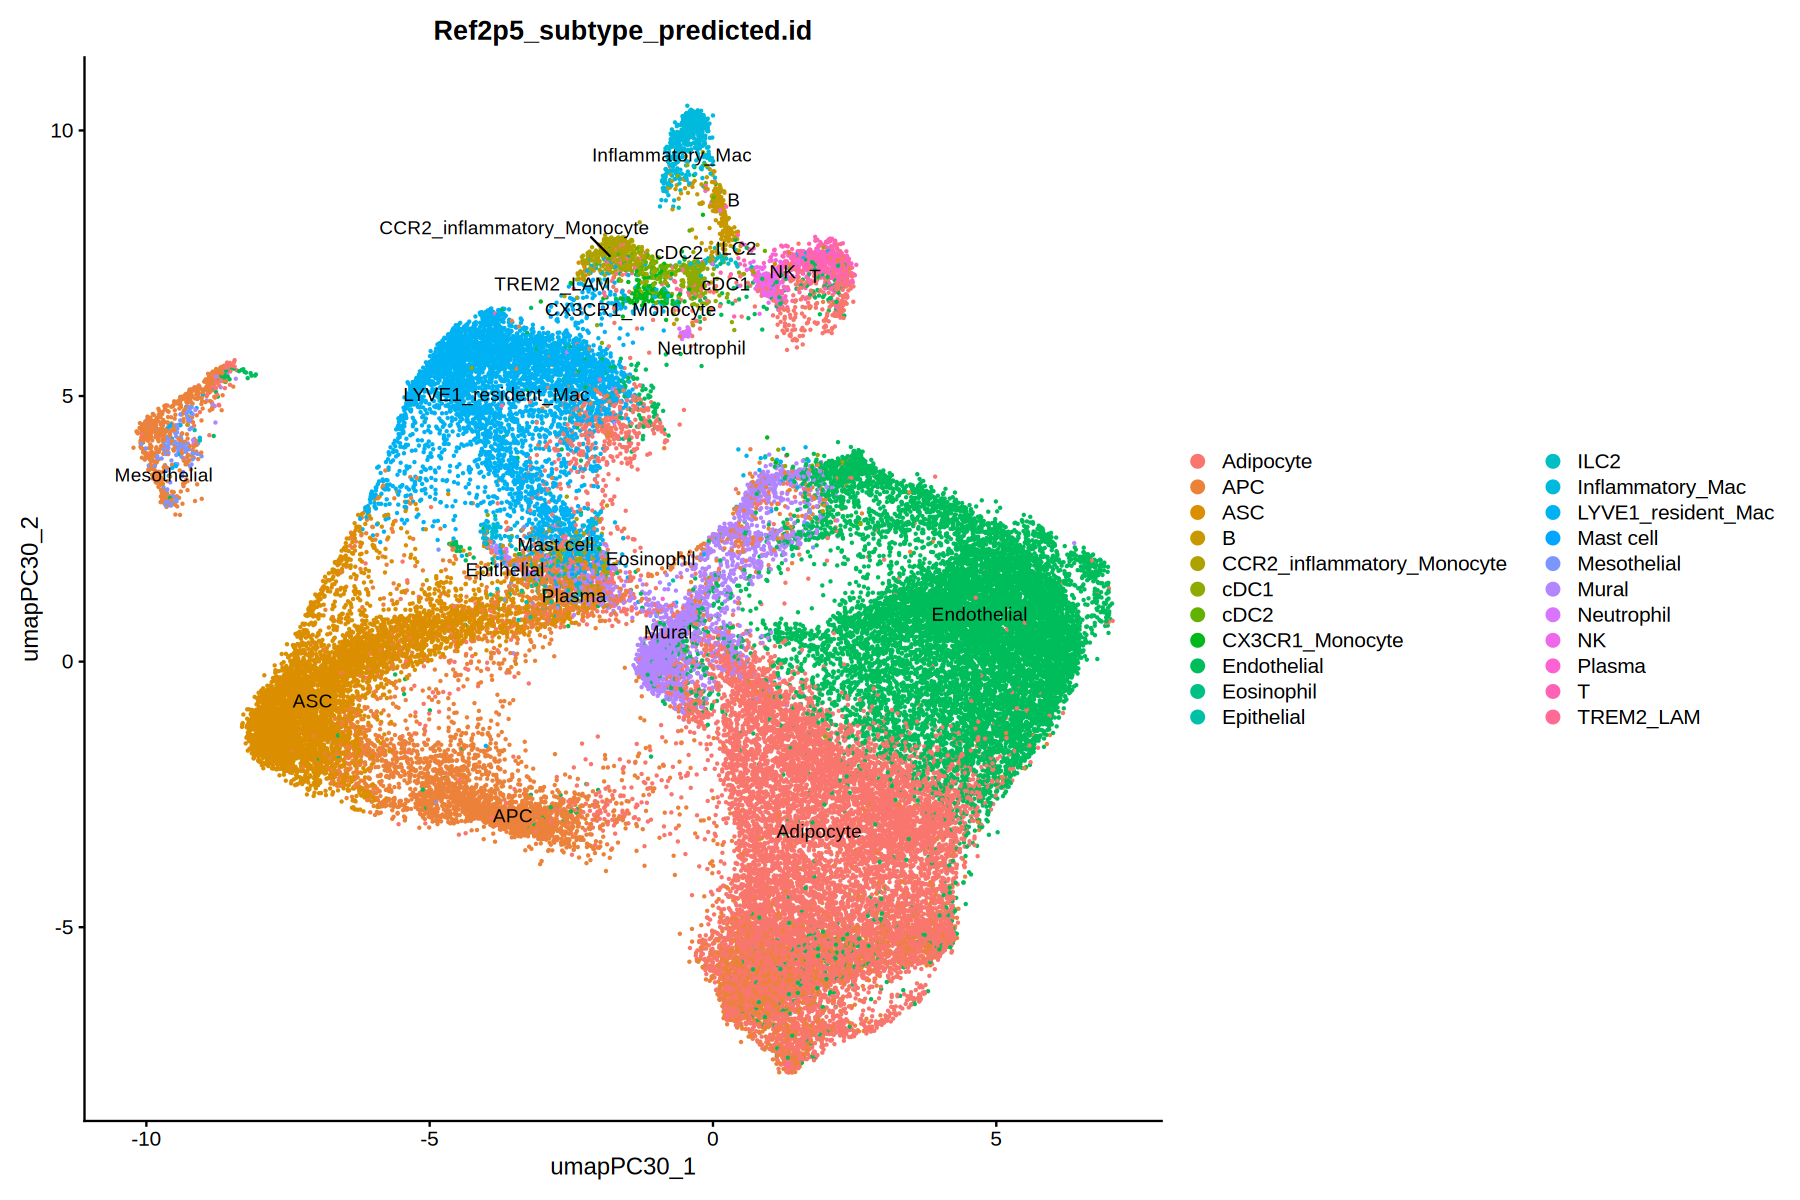

In [96]:
DimPlot(
  region_spatial,
  reduction = "umap_PC30",
  group.by = c("Ref2p5_subtype_predicted.id"),
  label = TRUE,
  repel = TRUE
)

## Step6 - Refine cell types

In [ ]:
region_spatial = readRDS(file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_passQC.rds")))

In [98]:
annotation_result <- refine_xenium_celltypes(
  object = region_spatial,
  reduction = "pca",
  dims = dims_use,
  k = 15,
  self_weight = 0.70
)

region_spatial <- annotation_result$object

Building transcriptomic kNN: k = 15, reduction = pca, dims = 1:30

Annotation complete.

Review cells: 21932 / 48658 (45.07%)

Schwann ontology-gap rescue: 741

Lymphatic EC ontology-gap rescue: 0



In [99]:
annotation_result$summary[annotation_result$summary$Final_CellType_subtype=='Eosinophil',]

,Final_CellType_main,Final_CellType_subtype,Final_annotation_source,Final_annotation_confidence,Final_review_flag,n_cells
,<chr>,<chr>,<chr>,<chr>,<lgl>,<int>
15,Eosinophil,Eosinophil,Wang_RefAll_immune,REFERENCE_PRIMARY,FALSE,28
16,Eosinophil,Eosinophil,Wang_RefAll_immune,HIGH_CONCORDANT,FALSE,14
17,Eosinophil,Eosinophil,Wang_RefAll_immune,REVIEW,TRUE,1


In [100]:
table(
  region_spatial$Final_CellType_main[region_spatial$Final_annotation_confidence=="REVIEW"],
  useNA = "ifany"
)

table(
  region_spatial$Final_CellType_subtype[region_spatial$Final_annotation_confidence=="REVIEW"],
  useNA = "ifany"
)

table(
  region_spatial$Final_annotation_confidence
)

table(
  region_spatial$Final_review_flag
)


         Adipocyte             B cell                 DC        Endothelial 
              1685                  4                  1               9763 
        Eosinophil         Epithelial                ILC         Macrophage 
                 1                 71                  1                 63 
         Mast cell        Mesothelial              Mural             Plasma 
                 2                 99                314                  3 
Stromal_Fibroblast             T cell 
              9924                  1 


         Adipocyte                APC                ASC                  B 
              1685               9427                497                  4 
      Capillary_EC               cDC2         Eosinophil         Epithelial 
              8938                  1                  1                 71 
              ILC2   Inflammatory_Mac       Lymphatic_EC LYVE1_resident_Mac 
                 1                 16                173                 46 
         Mast cell        Mesothelial           Pericyte             Plasma 
                 2                 99                142                  3 
                 T          TREM2_LAM          Venous_EC               VSMC 
                 1                  1                652                172 


       HIGH_CONCORDANT ONTOLOGY_GAP_SUPPORTED      REFERENCE_PRIMARY 
                 22812                    741                   3173 
                REVIEW 
                 21932 


FALSE  TRUE 
26726 21932 

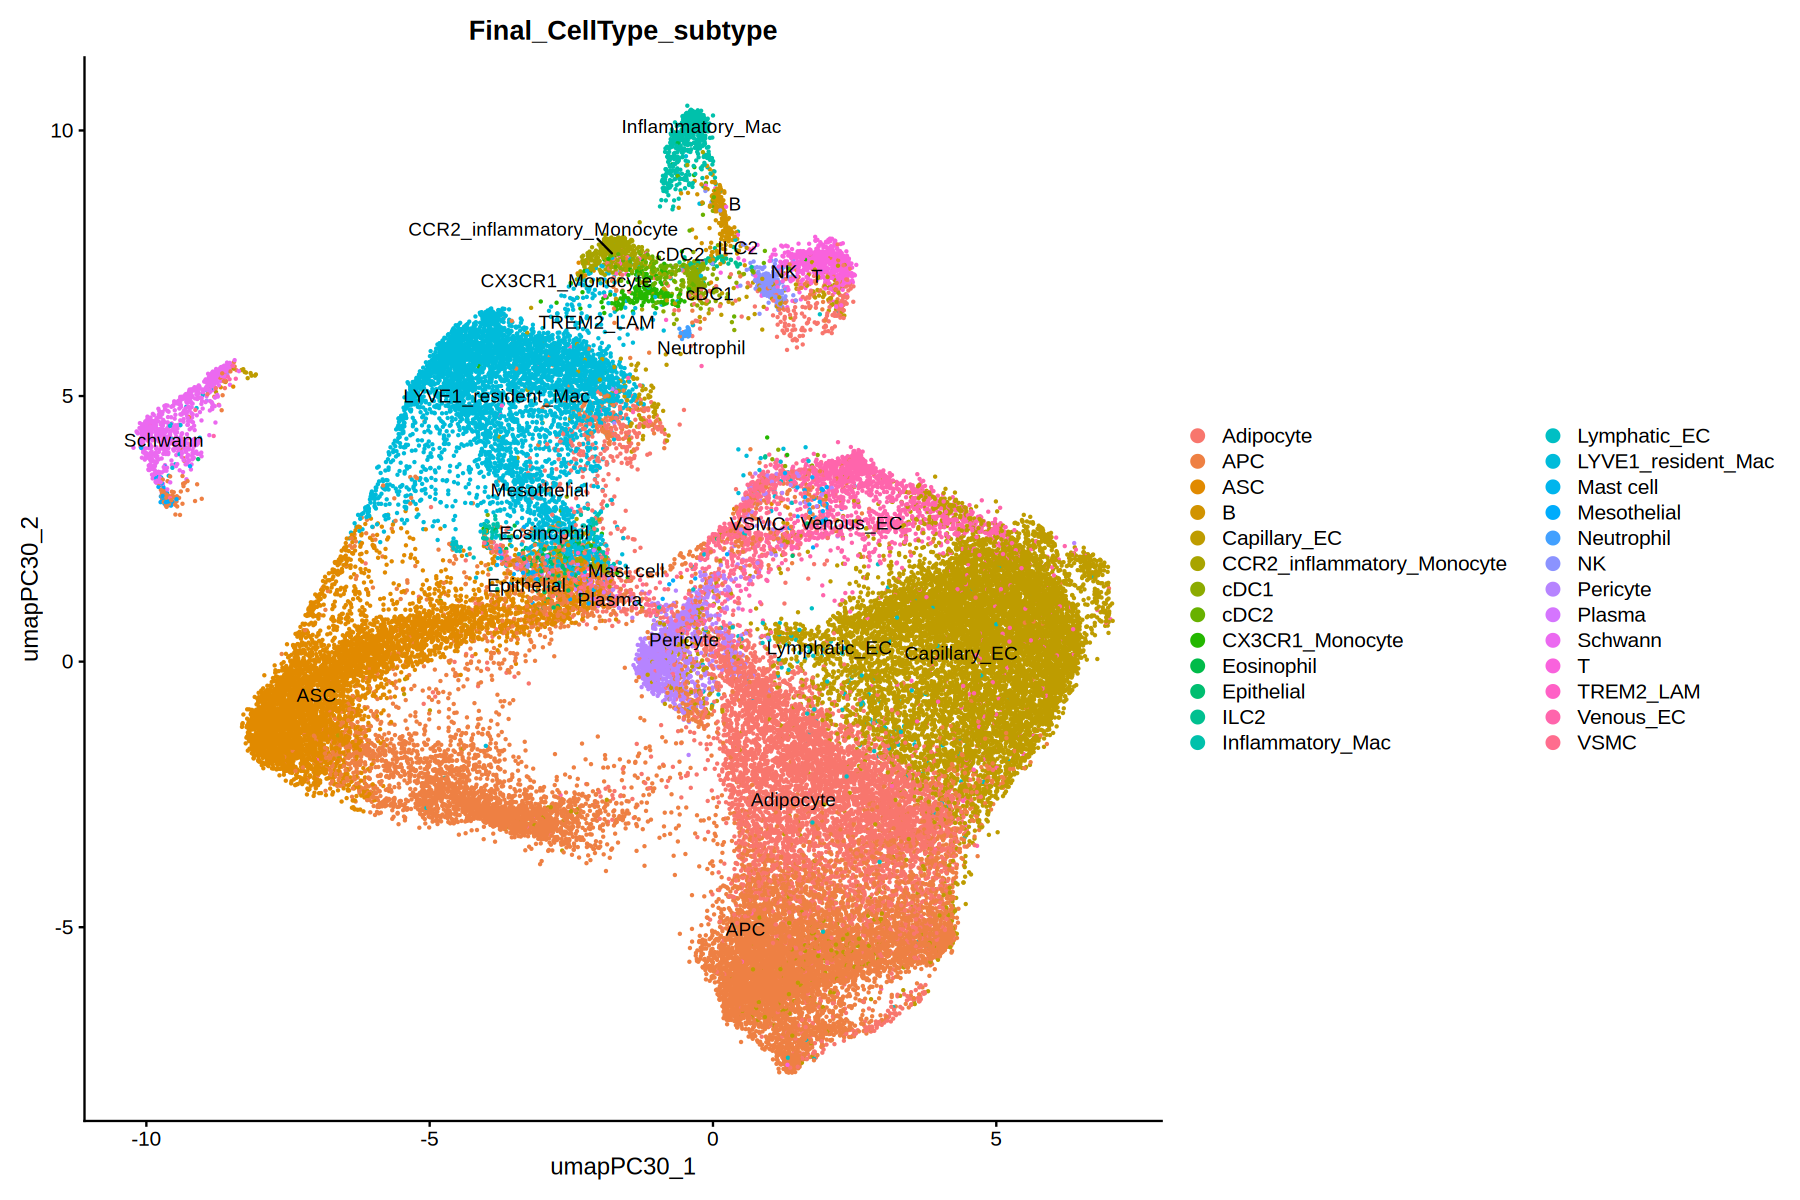

In [101]:
DimPlot(
  region_spatial,
  reduction = "umap_PC30",
  group.by = c("Final_CellType_subtype"),
  label = TRUE,
  repel = TRUE
)

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


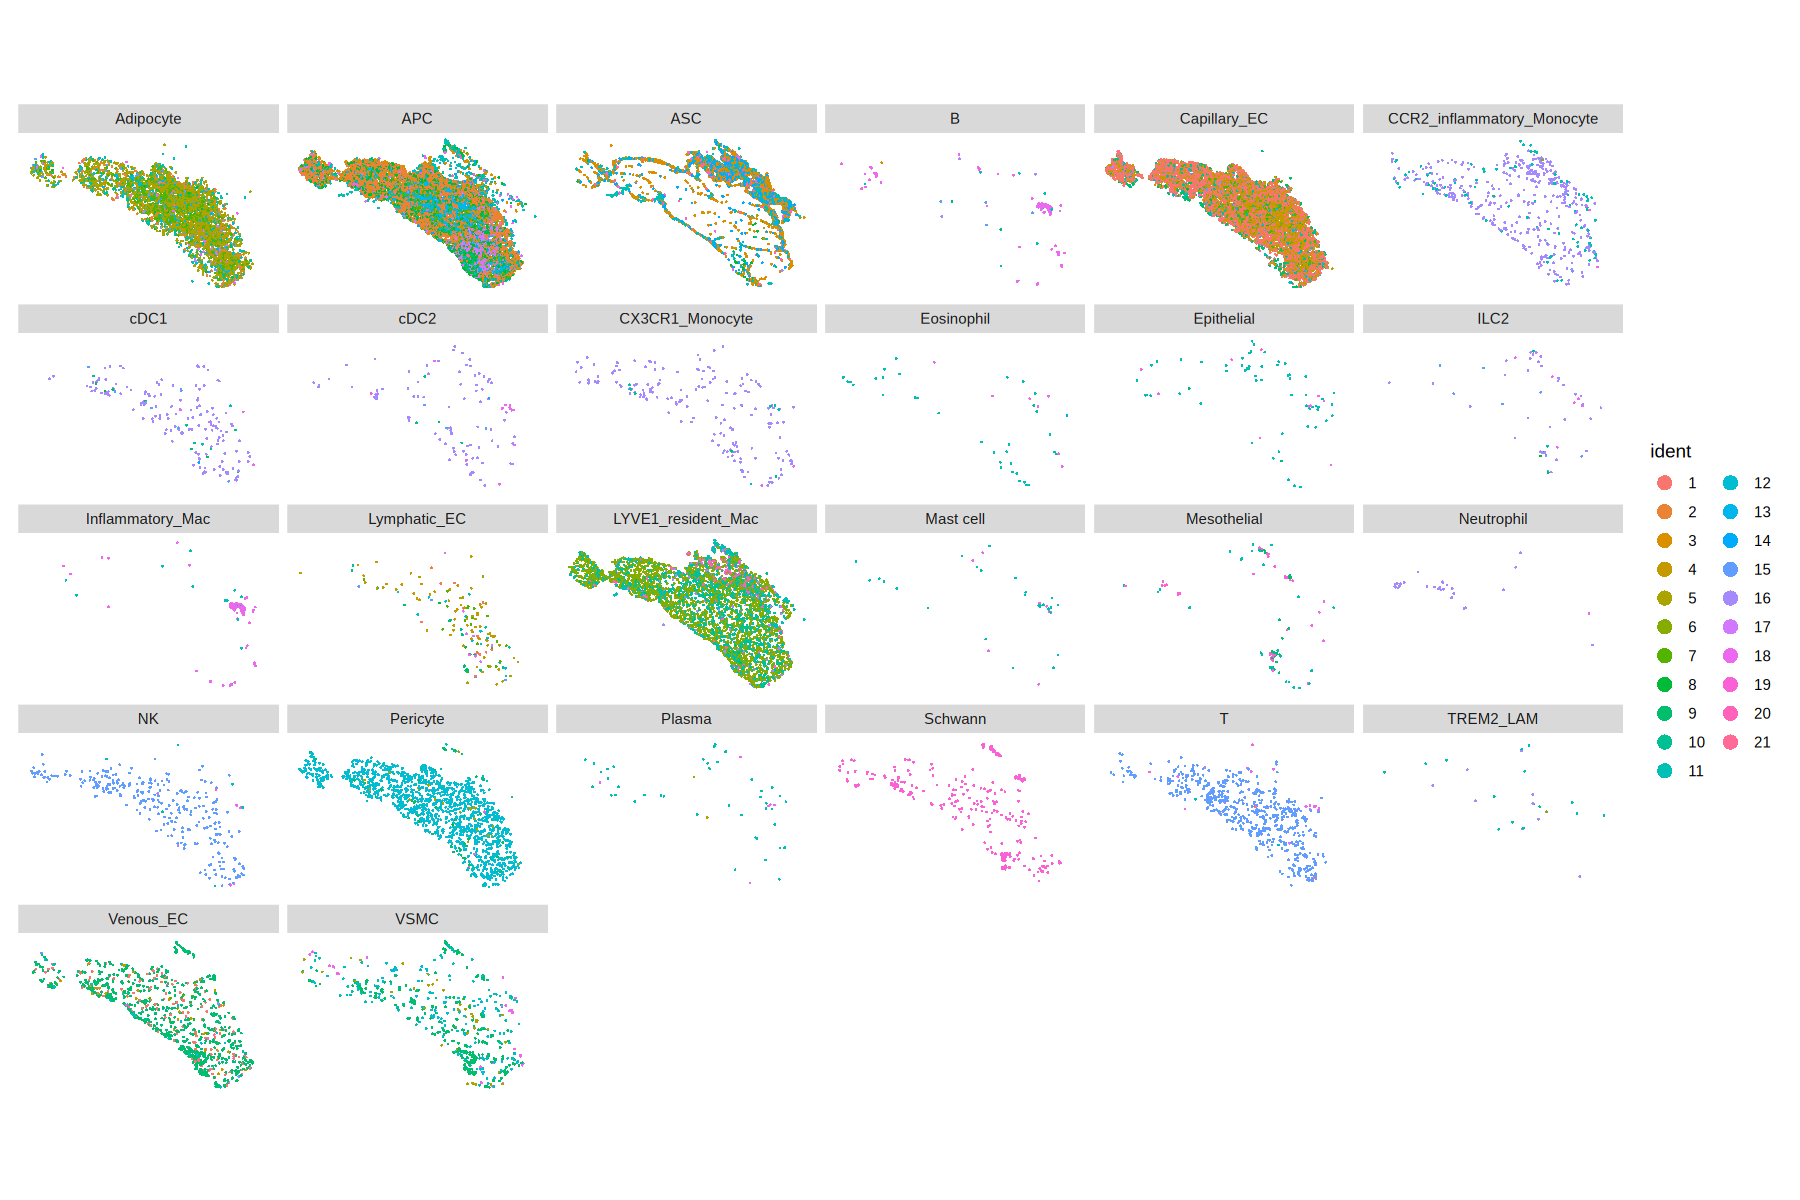

In [102]:
ImageDimPlot(
  region_spatial,
  fov = "fov",
  split.by = "Final_CellType_subtype",
  flip_xy = FALSE,
  dark.background = FALSE
)

In [103]:
options(repr.plot.width=20, repr.plot.height=16)

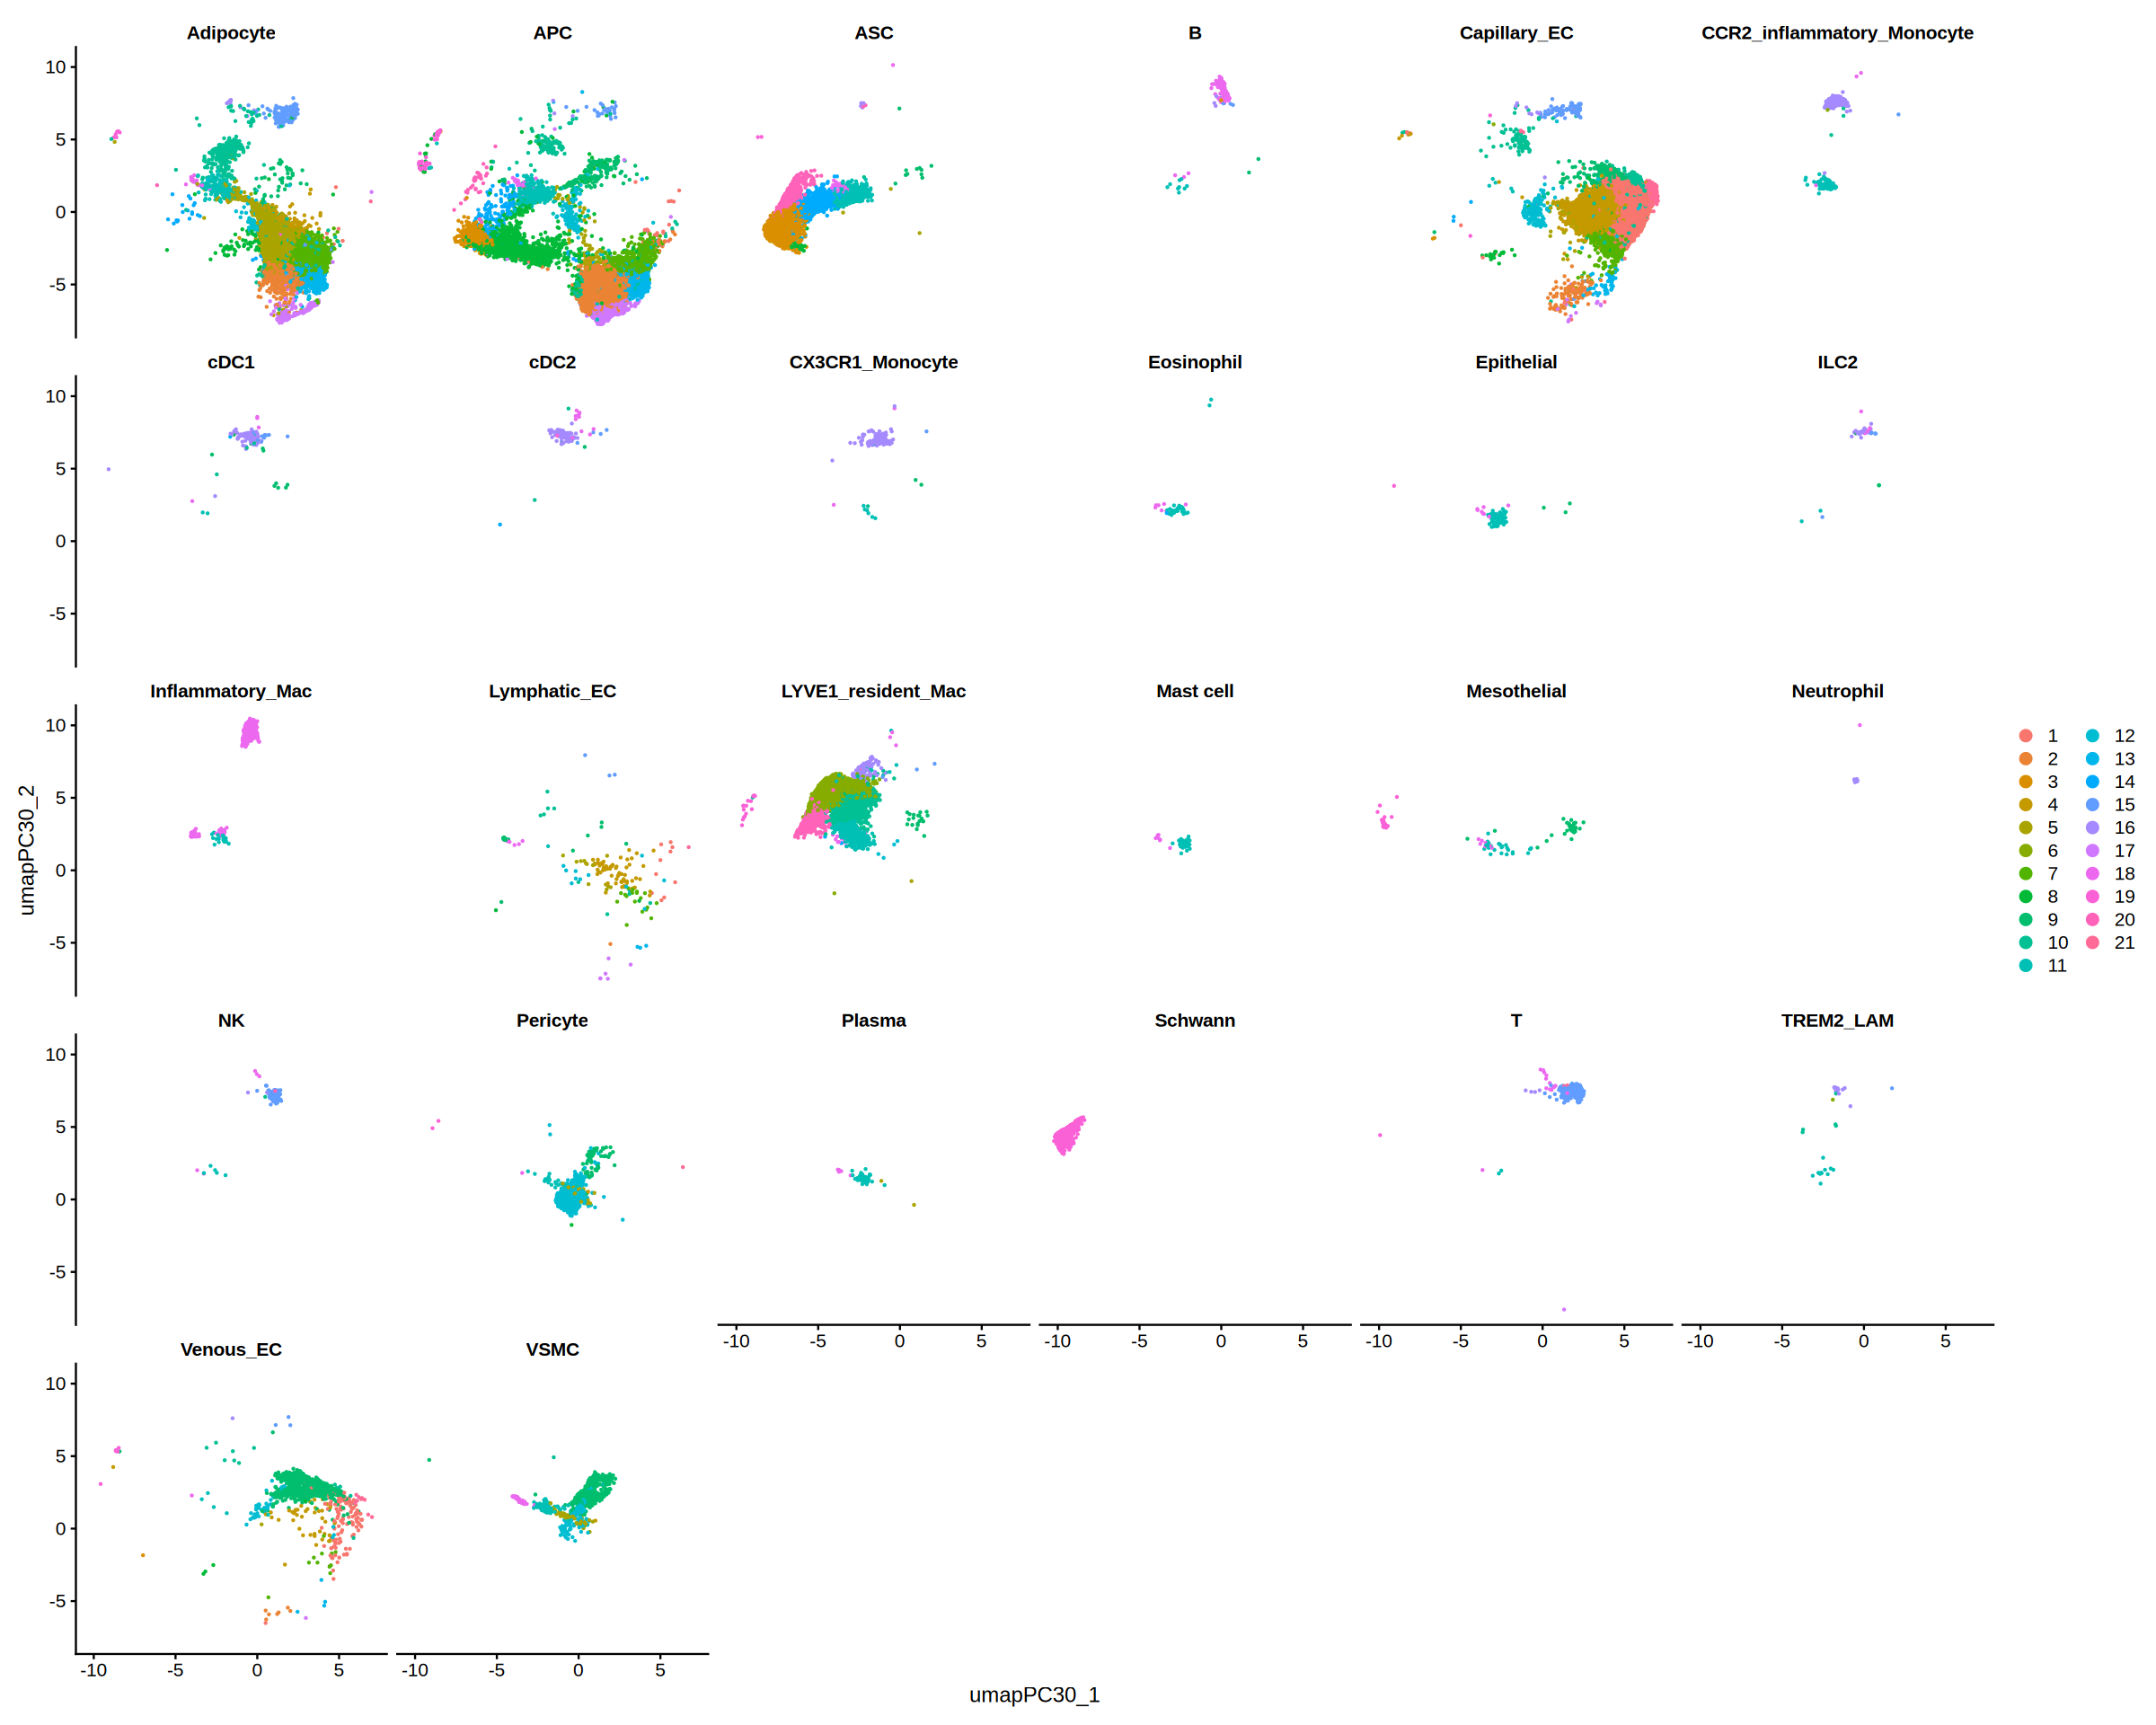

In [104]:
DimPlot(
  region_spatial,
  reduction = "umap_PC30",
  split.by = "Final_CellType_subtype",
  ncol=6
)

In [106]:
dim(region_spatial@meta.data)

[1] 48658   235

In [105]:
saveRDS(region_spatial, file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_passQC.rds")))

## Step7 - Define Eos 

In [ ]:
region_spatial = readRDS(file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_passQC.rds")))

In [107]:
length(rownames(region_spatial@meta.data)[region_spatial@meta.data$Final_CellType_subtype == "Eosinophil"])

[1] 43

In [108]:
dim(region_spatial)

[1]   479 48658

In [109]:
WANG_REFERENCE_PATH <- file.path(
  "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data",
  "Wang_Science2025_mouse_human",
  "analysis_mouse",
  "Wang_Science2025_cleaned_seurat.rds"
)

In [110]:
scwat_ref <- readRDS(WANG_REFERENCE_PATH)

In [111]:
eos_result <- score_eosinophil_likeness(
  reference = scwat_ref,
  query = region_spatial,
  reference_group_col = "Wang_subtype_harmonized"
)

region_spatial <- eos_result$object

Tier 1 core markers: Siglecf, Ccr3

Tier 2 support markers: Il5ra, Alox15

Tier 3 marker: Itgam

Tier 4 additional markers: Ear1, Ear2

Reference Eosinophils: 180

Reference other immune cells: 15001

Tier hierarchy:

  Tier1 = Siglecf + Ccr3

  Tier2 = core + Il5ra/Alox15

  Tier3 = core + Itgam

  Tier4 = any remaining >=2-marker combination

  Rest  = all remaining cells

Core weights (ranking only): Siglecf=0.386; Ccr3=0.614

Tier assignment complete.



In [112]:
table(
  region_spatial$EosRef_tier,
  useNA = "ifany"
)


Conf Tier1 Conf Tier2 Conf Tier3 Conf Tier4       Rest 
        33         96        279       1514      46736 

In [113]:
names(eos_result)

[1] "object"                      "marker_stats"               
 [3] "pair_stats"                  "rule_performance"           
 [5] "calibration"                 "reference_scores"           
 [7] "reference_tier_distribution" "candidate_table"            
 [9] "summary"                     "tier_summary"               
[11] "parameters"

In [115]:
eos_result$marker_stats

Gene,Marker_role,n_Eos,Eos_positive,Eos_pct,Other_macro_pct,Max_other_pct,Max_other_celltype,log2_detection_OR_macro,core_anchor_valid,core_weight
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<lgl>,<dbl>
Siglecf,Tier1_core,180,30,16.666667,1.2873214,5.809859,TREM2_LAM,3.7778262,TRUE,0.385808
Ccr3,Tier1_core,180,94,52.222222,1.4949066,6.161972,TREM2_LAM,6.0141590,TRUE,0.614192
Il5ra,Tier2_support,180,14,7.777778,5.2963671,40.000000,Plasma,0.5963723,FALSE,0.000000
Alox15,Tier2_support,180,67,37.222222,5.6362454,79.299363,Inflammatory_Mac,3.2720157,FALSE,0.000000
Itgam,Tier3_support,180,92,51.111111,41.1478146,96.496815,Inflammatory_Mac,0.5755878,FALSE,0.000000
Ear1,Tier4_context,180,0,0.000000,0.3448246,1.923077,Mast cell,-0.9009362,FALSE,0.000000
Ear2,Tier4_context,180,3,1.666667,14.7833889,62.631579,CX3CR1_Monocyte,-3.1534228,FALSE,0.000000


In [116]:
eos_result$pair_stats

Tier_rule,Core_marker,Partner_marker,Pair,n_Eos,Eos_positive,Eos_pct,Other_macro_pct,Max_other_pct,Max_other_celltype,log2_detection_OR_macro,reference_supported
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<lgl>
Tier2,Siglecf,Il5ra,Siglecf + Il5ra,180,4,2.222222,0.00000000,0.000000,Mast cell,3.882979,TRUE
Tier2,Ccr3,Il5ra,Ccr3 + Il5ra,180,9,5.000000,0.28568619,1.923077,Mast cell,3.598426,TRUE
Tier2,Siglecf,Alox15,Siglecf + Alox15,180,14,7.777778,0.06360807,0.000000,Mast cell,5.202433,TRUE
Tier2,Ccr3,Alox15,Ccr3 + Alox15,180,44,24.444444,0.06210968,0.000000,Mast cell,7.115579,TRUE
Tier3,Siglecf,Itgam,Siglecf + Itgam,180,21,11.666667,0.96507512,5.633803,TREM2_LAM,3.554359,TRUE
Tier3,Ccr3,Itgam,Ccr3 + Itgam,180,51,28.333333,0.69867045,5.633803,TREM2_LAM,5.502629,TRUE


In [117]:
eos_result$summary

EosRef_call,n_cells,fraction
<chr>,<int>,<dbl>
OUTSIDE_IMMUNE,40588,0.8341485470
REF_EOS_REST,6538,0.1343663940
REF_EOS_TIER1,11,0.0002260677
REF_EOS_TIER2,46,0.0009453738
REF_EOS_TIER3,219,0.0045008015
REF_EOS_TIER4,1256,0.0258128160


In [118]:
eos_result$tier_summary

EosRef_tier,n_cells,fraction
<chr>,<int>,<dbl>
Conf Tier1,33,0.000678203
Conf Tier2,96,0.001972954
Conf Tier3,279,0.005733898
Conf Tier4,1514,0.031115130
Rest,46736,0.960499815


In [119]:
table(
  region_spatial$EosRef_tier,
  region_spatial$EosRef_call
)

            
             OUTSIDE_IMMUNE REF_EOS_REST REF_EOS_TIER1 REF_EOS_TIER2
  Conf Tier1             22            0            11             0
  Conf Tier2             50            0             0            46
  Conf Tier3             60            0             0             0
  Conf Tier4            258            0             0             0
  Rest                40198         6538             0             0
            
             REF_EOS_TIER3 REF_EOS_TIER4
  Conf Tier1             0             0
  Conf Tier2             0             0
  Conf Tier3           219             0
  Conf Tier4             0          1256
  Rest                   0             0

In [120]:
table(region_spatial$EosRef_call, region_spatial$Final_CellType_subtype)

                
                 Adipocyte   APC   ASC     B Capillary_EC
  OUTSIDE_IMMUNE      7260 11536  5757     0        11024
  REF_EOS_REST           0     0     0   137            0
  REF_EOS_TIER1          0     0     0     0            0
  REF_EOS_TIER2          0     0     0     3            0
  REF_EOS_TIER3          0     0     0     1            0
  REF_EOS_TIER4          0     0     0    63            0
                
                 CCR2_inflammatory_Monocyte  cDC1  cDC2 CX3CR1_Monocyte
  OUTSIDE_IMMUNE                          0     0     0               0
  REF_EOS_REST                          144   192    87             160
  REF_EOS_TIER1                           0     0     0               0
  REF_EOS_TIER2                           2     2     2               1
  REF_EOS_TIER3                          28     3     6               5
  REF_EOS_TIER4                         351     7    25              34
                
                 Eosinophil Epithelial 

In [121]:
options(repr.plot.width=12, repr.plot.height=7)

In [122]:
res <- plot_eos_call_by_subtype(
  object = region_spatial,
  return_data = TRUE
)

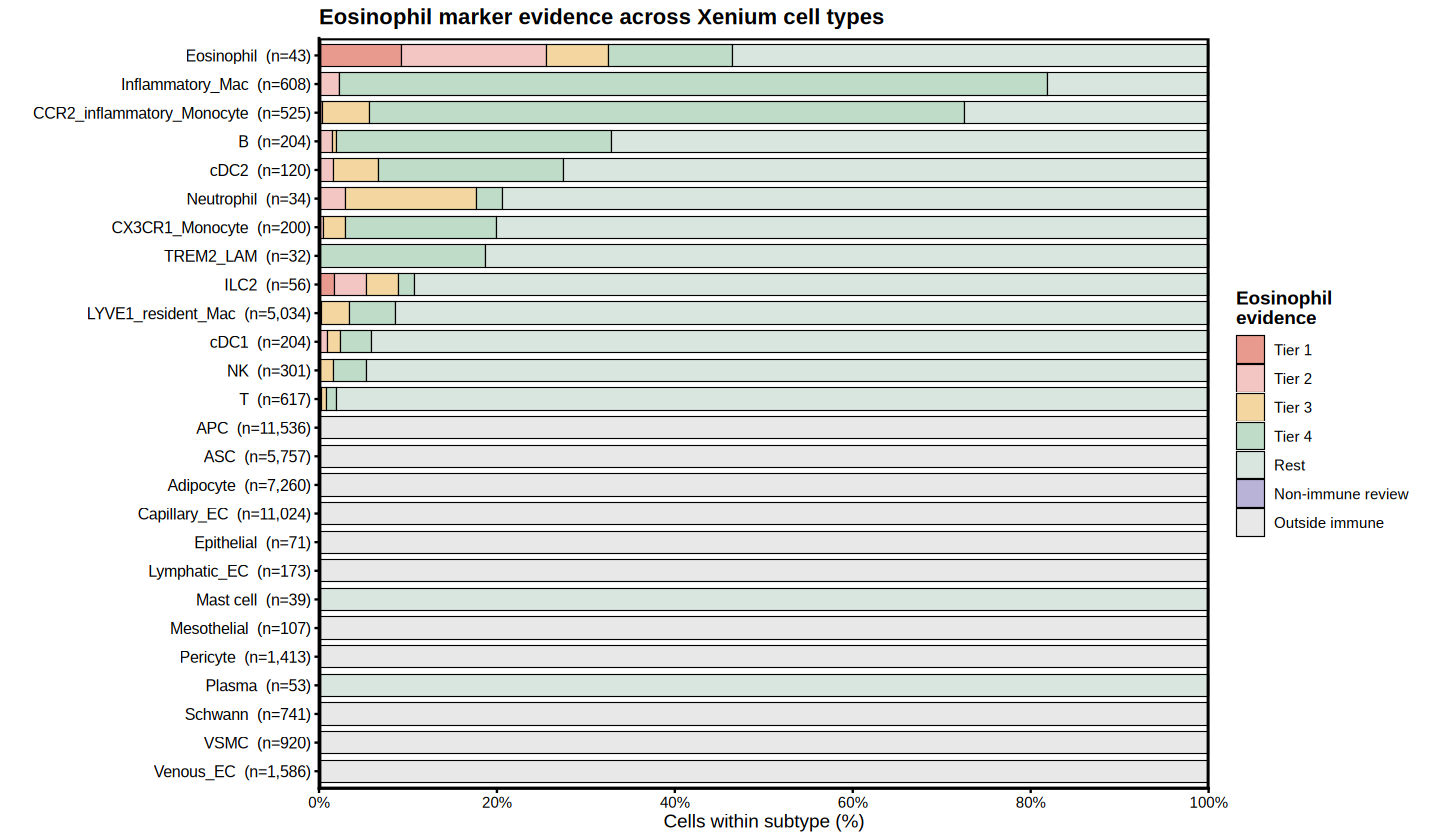

In [123]:
res$plot

In [124]:
options(repr.plot.width=18, repr.plot.height=8)

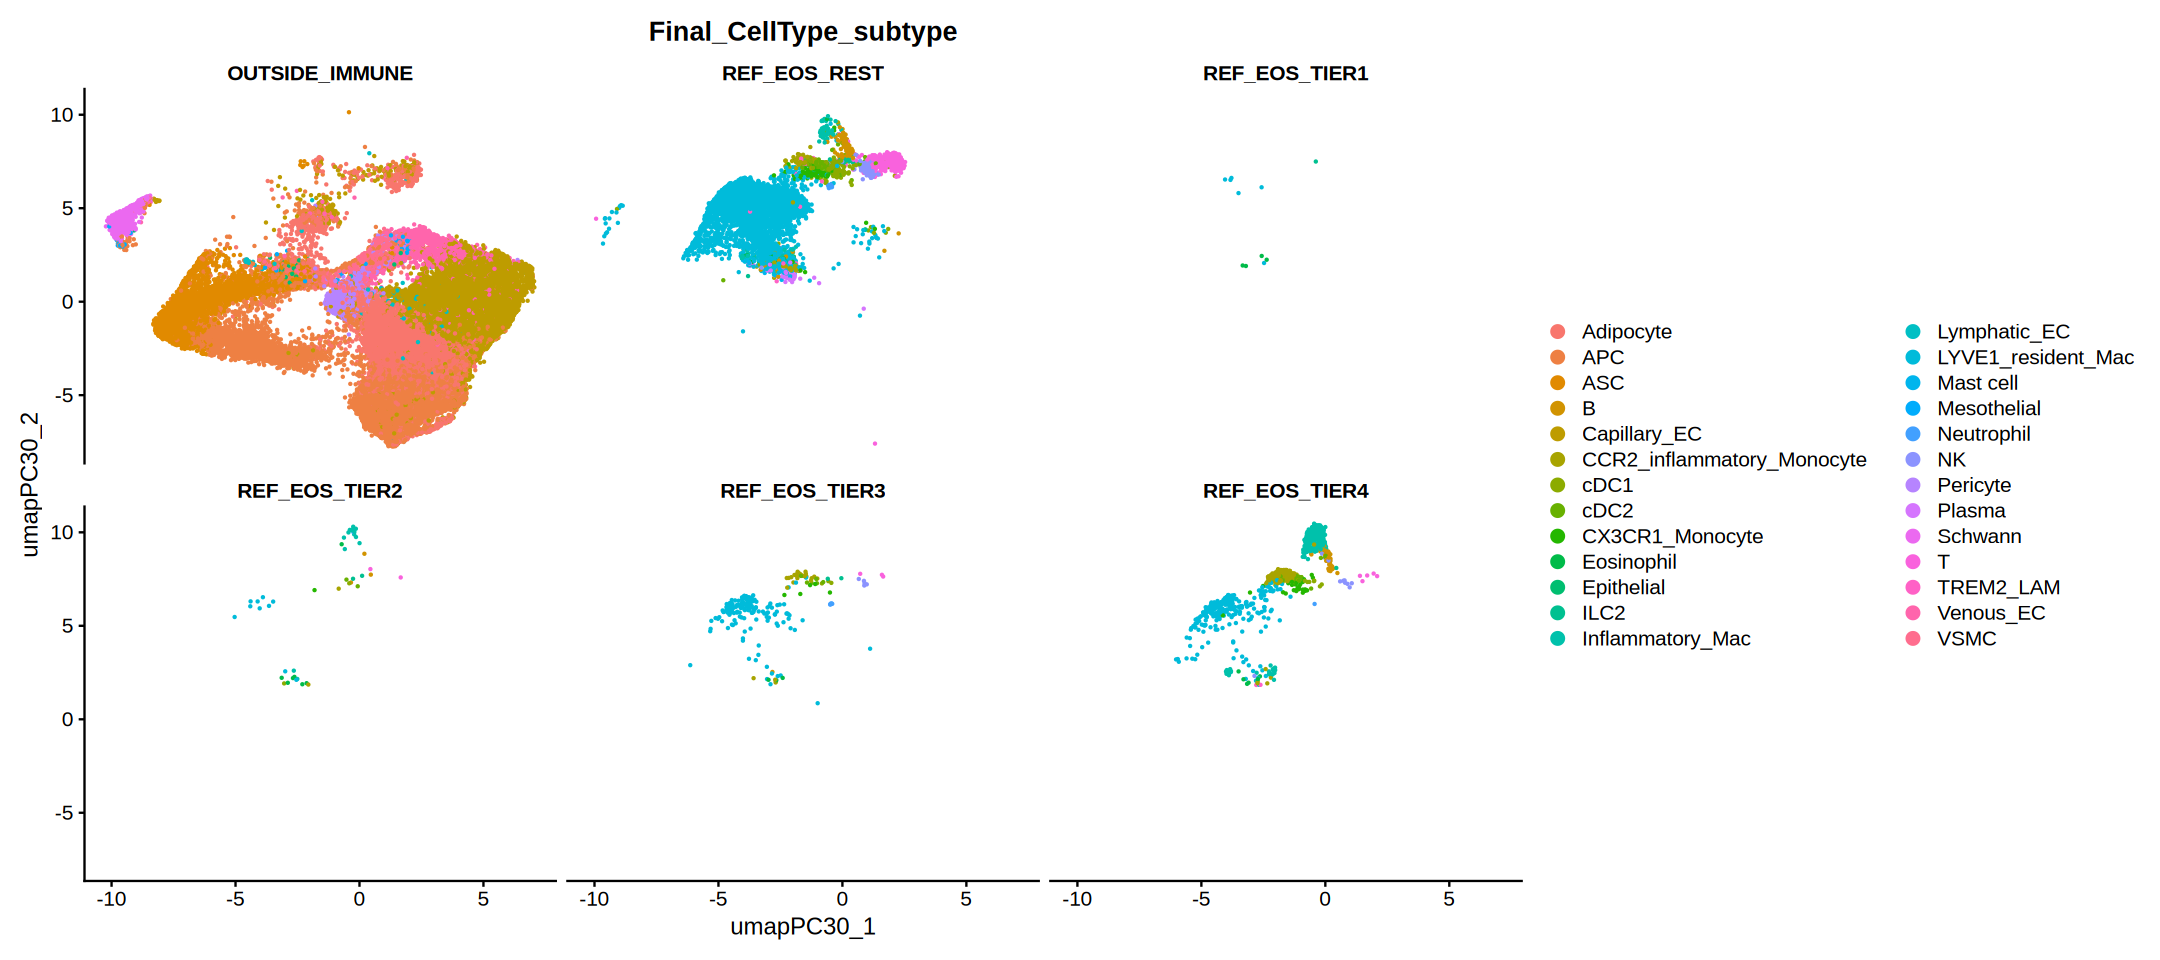

In [125]:
DimPlot(
  region_spatial,
  reduction = "umap_PC30",
  group.by = 'Final_CellType_subtype',
  split.by = "EosRef_call",
  ncol=3
)

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


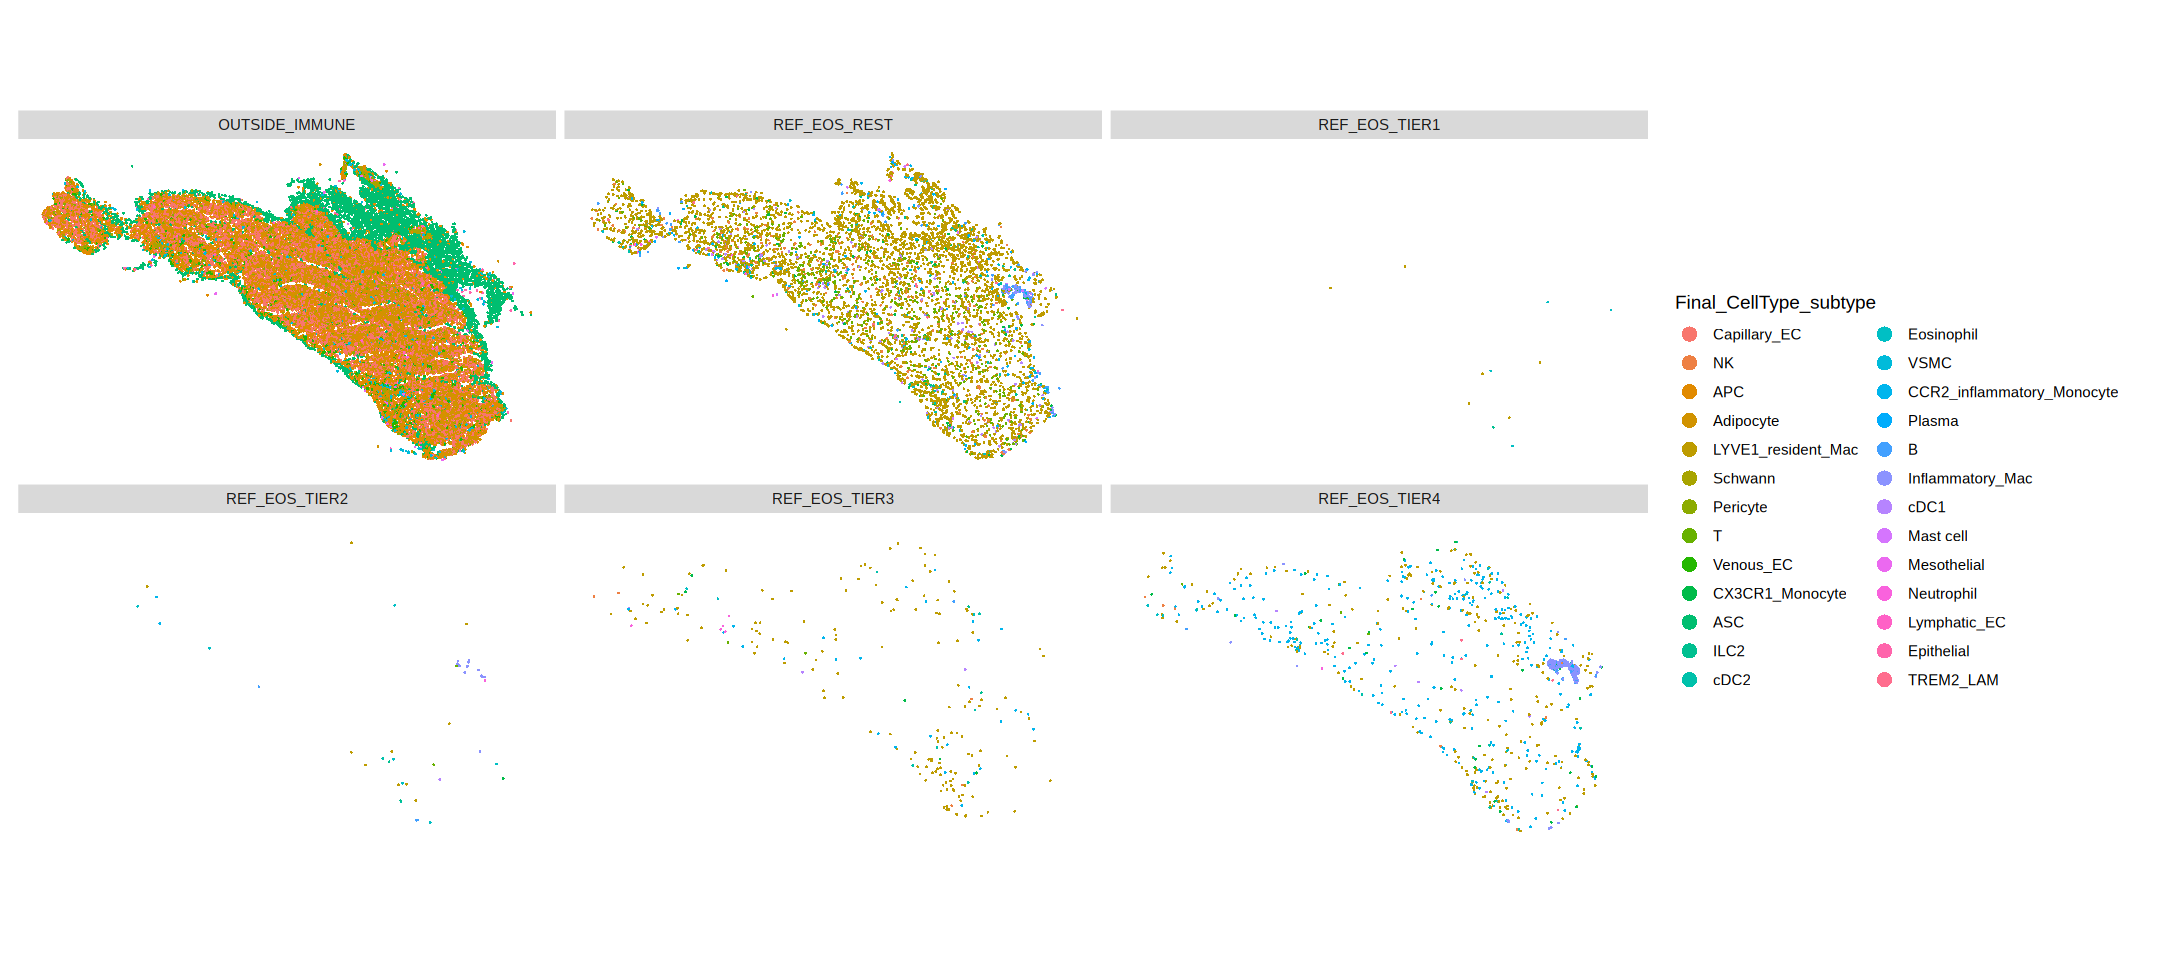

In [126]:
ImageDimPlot(
  region_spatial,
  fov = "fov",
    group.by = 'Final_CellType_subtype',
  split.by = "EosRef_call",
  flip_xy = FALSE,
  dark.background = FALSE
)

In [127]:
md <- region_spatial@meta.data

existing_eos <- (
  as.character(md$Final_CellType_subtype) ==
    "Eosinophil"
)

tier12 <- (
  md$EosRef_call %in%
    c(
      "REF_EOS_TIER1",
      "REF_EOS_TIER2"
    )
)

region_spatial$Final_Eos_status <- dplyr::case_when(

  existing_eos & tier12 ~
    "FINAL_EOS",

  existing_eos & !tier12 ~
    "REVIEW_EXISTING_EOS",

  !existing_eos & tier12 ~
    "REVIEW_TIER12_NON_EOS",

  TRUE ~
    "NON_EOS"
)

In [128]:
table(
  region_spatial$Final_Eos_status
)


            FINAL_EOS               NON_EOS   REVIEW_EXISTING_EOS 
                   11                 48569                    32 
REVIEW_TIER12_NON_EOS 
                   46 

In [129]:
region_spatial$Final_CellType_subtype_refined <-
  as.character(
    region_spatial$Final_CellType_subtype
  )

In [130]:
region_spatial$Final_CellType_subtype_refined[
  existing_eos | tier12
] <- "Eosinophil"

In [131]:
sum(region_spatial$Final_CellType_subtype_refined == "Eosinophil")

[1] 89

In [132]:
dim(region_spatial@meta.data)

[1] 48658   258

In [133]:
saveRDS(region_spatial, file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_passQC.rds")))

In [134]:
options(repr.plot.width=12, repr.plot.height=8)

Warning message:
“Removed 48658 rows containing missing values or values outside the scale range
(`geom_point()`).”


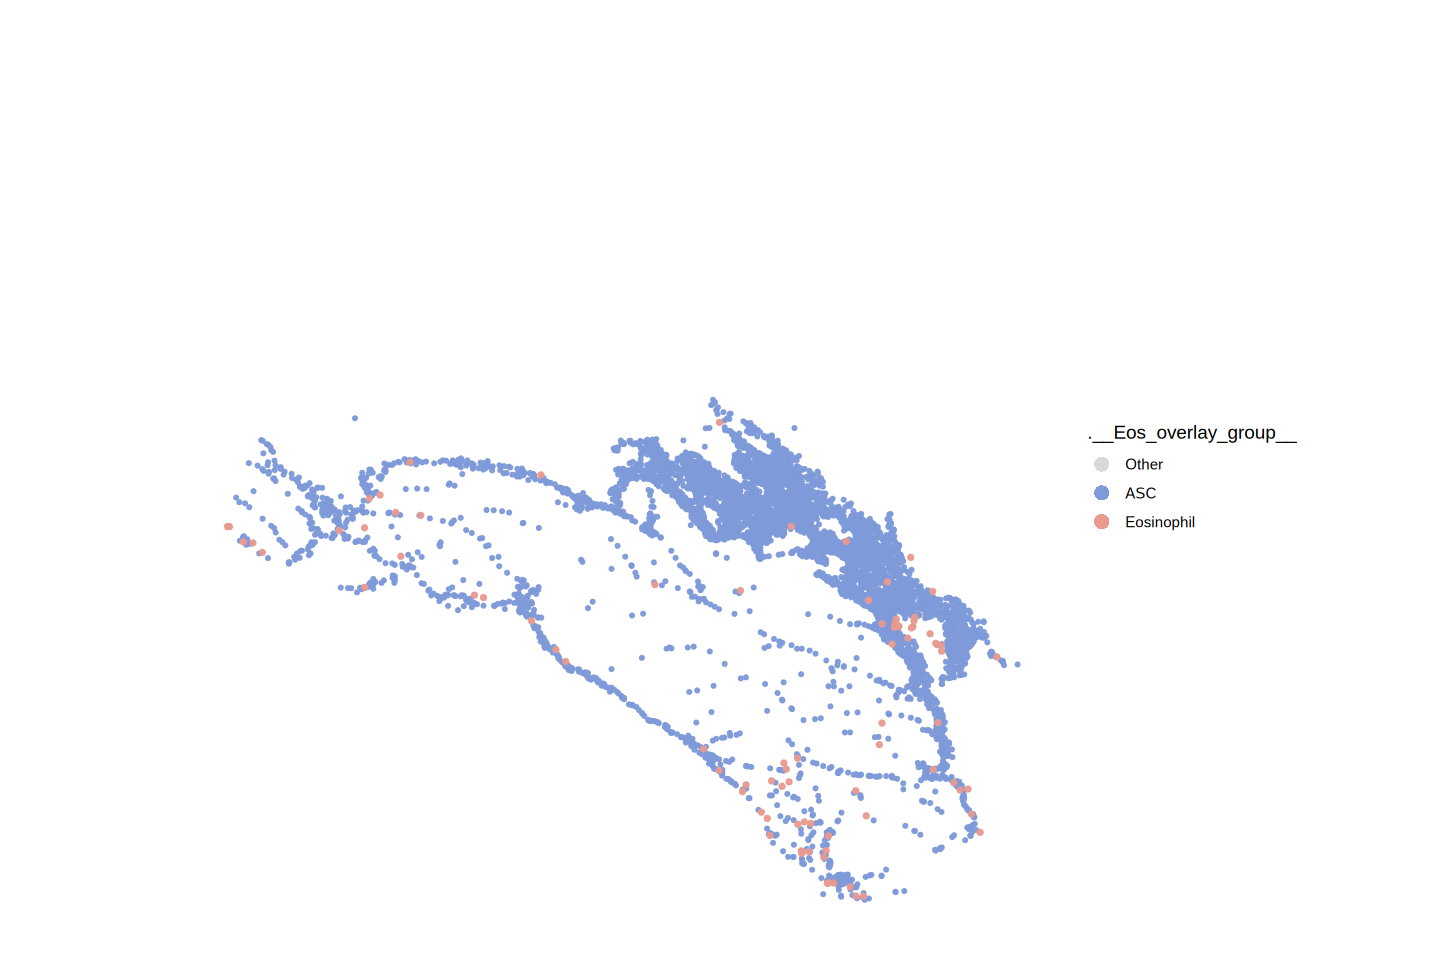

In [135]:
plot_eos_with_celltypes(
  region_spatial,
  celltypes = "ASC",
    flip_xy = TRUE
)

In [136]:
unique(region_spatial$Final_CellType_subtype_refined)

[1] "Capillary_EC"               "NK"                        
 [3] "APC"                        "Adipocyte"                 
 [5] "LYVE1_resident_Mac"         "Schwann"                   
 [7] "Pericyte"                   "T"                         
 [9] "Venous_EC"                  "CX3CR1_Monocyte"           
[11] "ASC"                        "ILC2"                      
[13] "cDC2"                       "Eosinophil"                
[15] "VSMC"                       "CCR2_inflammatory_Monocyte"
[17] "Plasma"                     "B"                         
[19] "Inflammatory_Mac"           "cDC1"                      
[21] "Mast cell"                  "Mesothelial"               
[23] "Neutrophil"                 "Lymphatic_EC"              
[25] "Epithelial"                 "TREM2_LAM"

Warning message:
“Removed 48658 rows containing missing values or values outside the scale range
(`geom_point()`).”


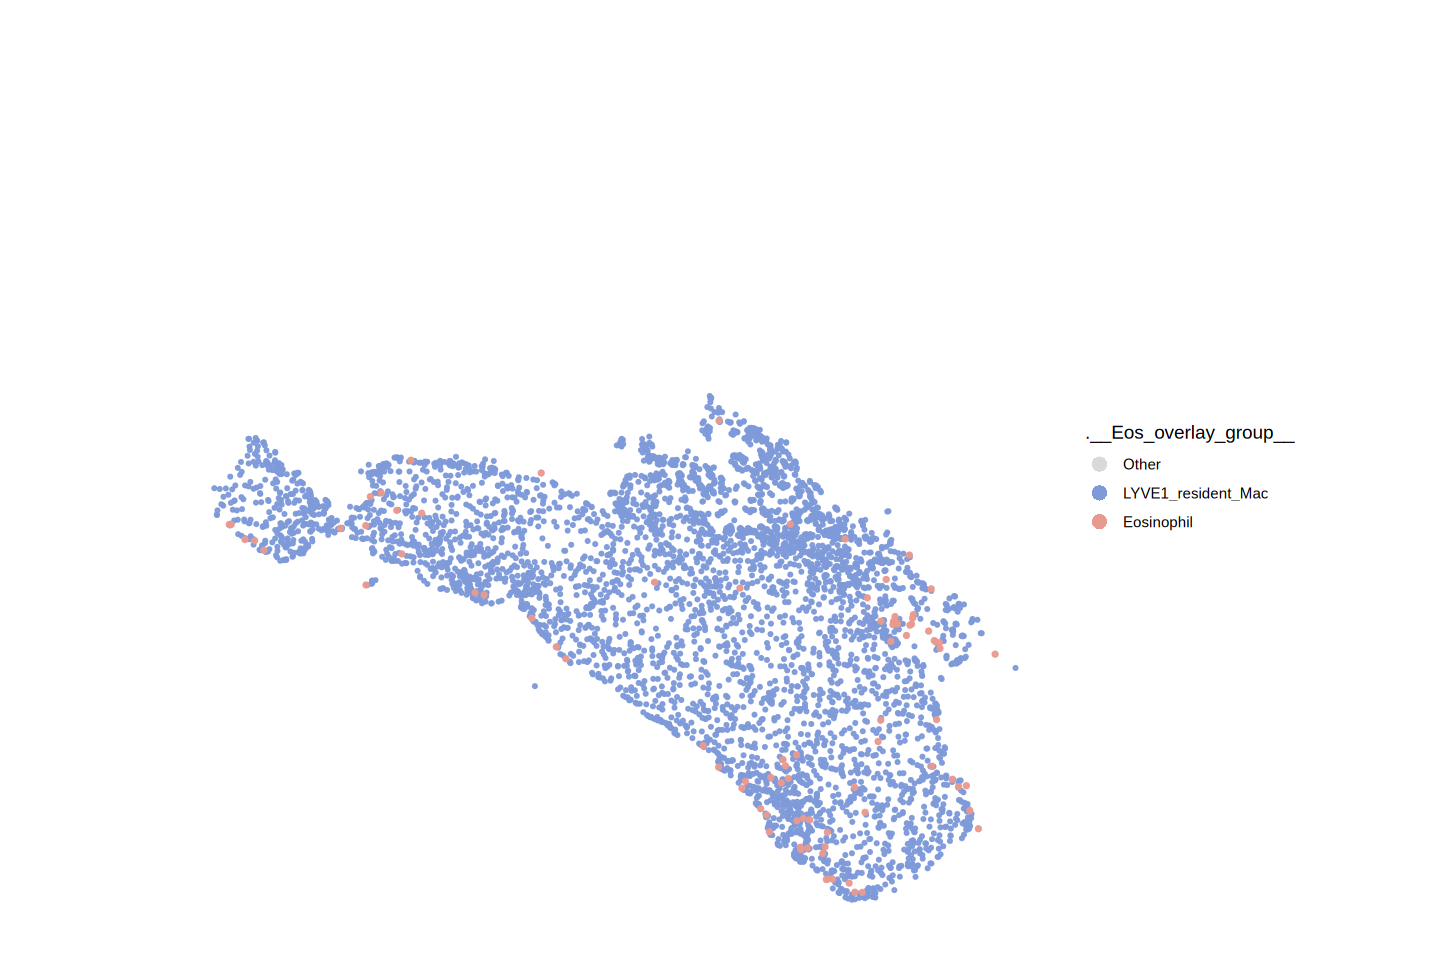

In [137]:
plot_eos_with_celltypes(
  region_spatial,
  celltypes = "LYVE1_resident_Mac",
    flip_xy = TRUE
)

Warning message:
“Removed 48658 rows containing missing values or values outside the scale range
(`geom_point()`).”


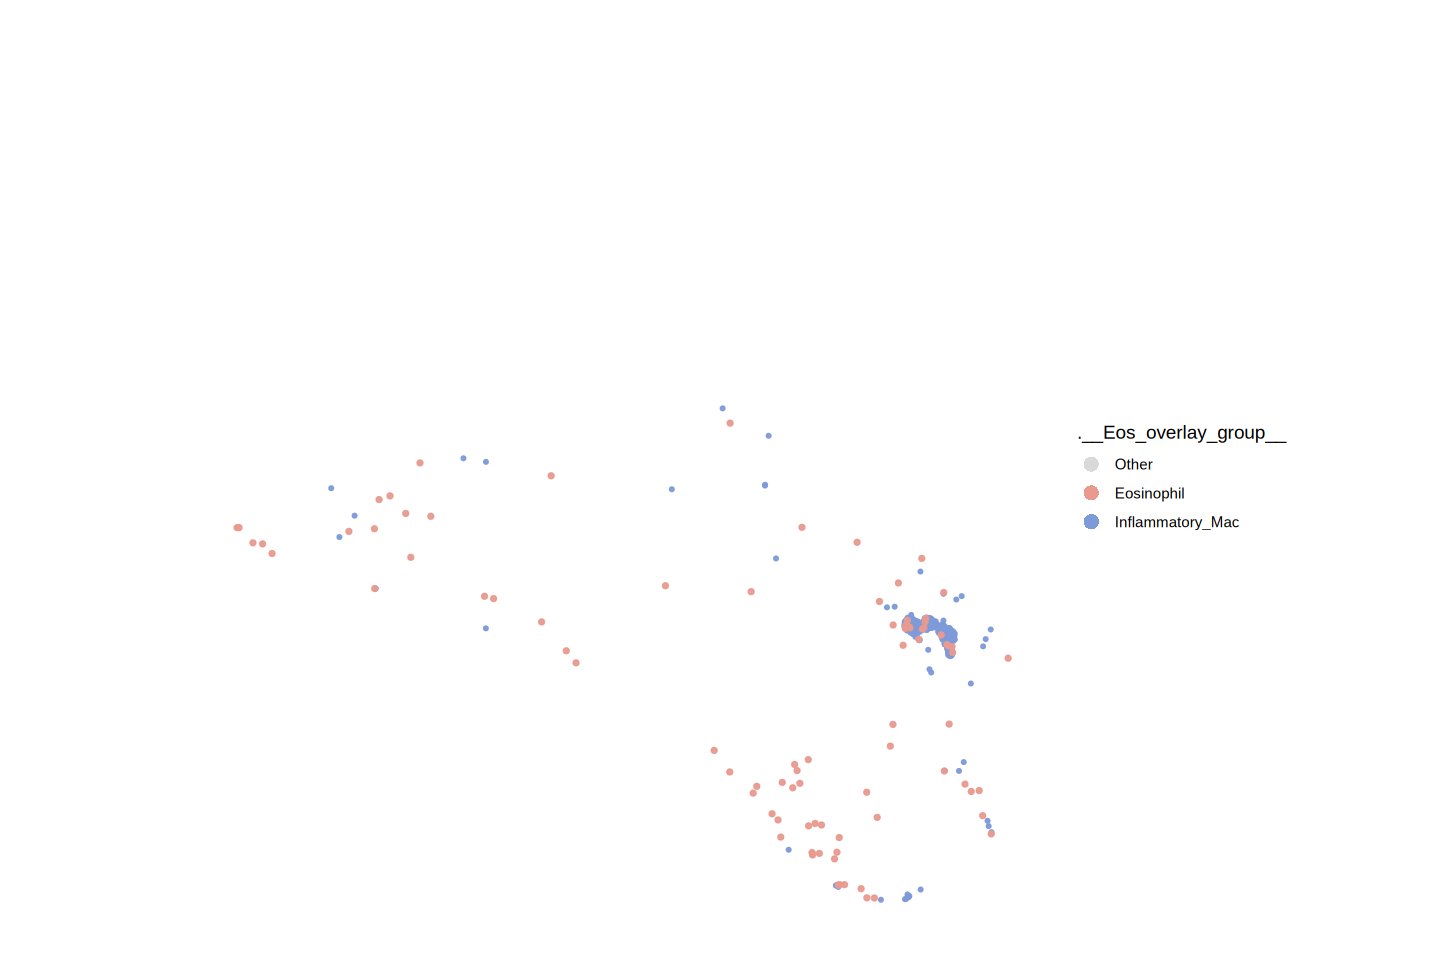

In [138]:
plot_eos_with_celltypes(
  region_spatial,
  celltypes = "Inflammatory_Mac",
    flip_xy = TRUE
)

Warning message:
“Removed 48658 rows containing missing values or values outside the scale range
(`geom_point()`).”


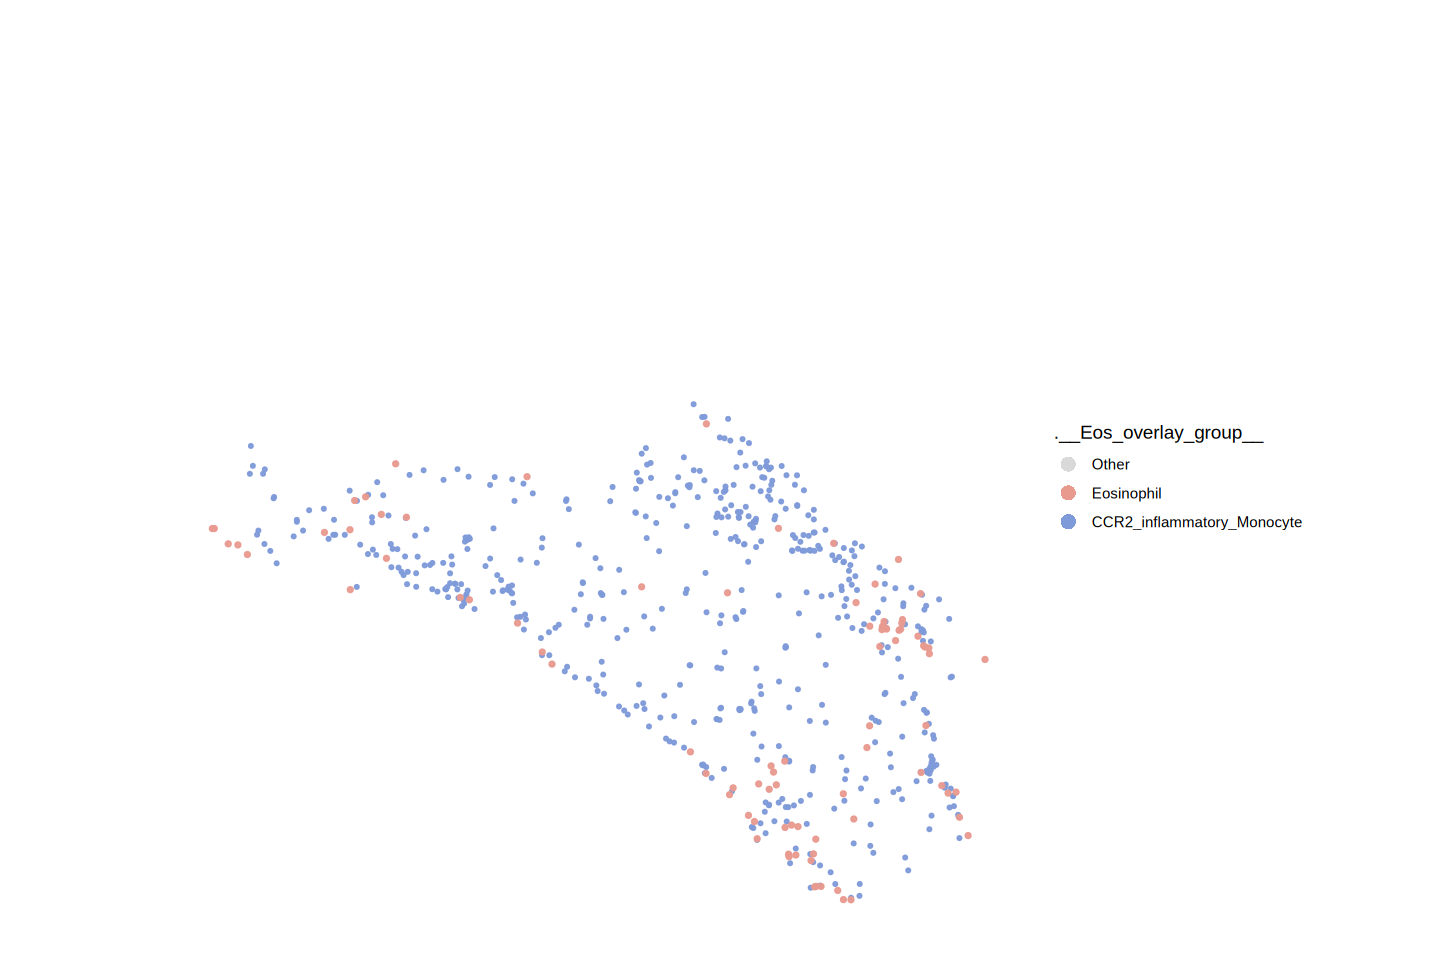

In [139]:
plot_eos_with_celltypes(
  region_spatial,
  celltypes = "CCR2_inflammatory_Monocyte",
    flip_xy = TRUE
)

Warning message:
“Removed 48658 rows containing missing values or values outside the scale range
(`geom_point()`).”


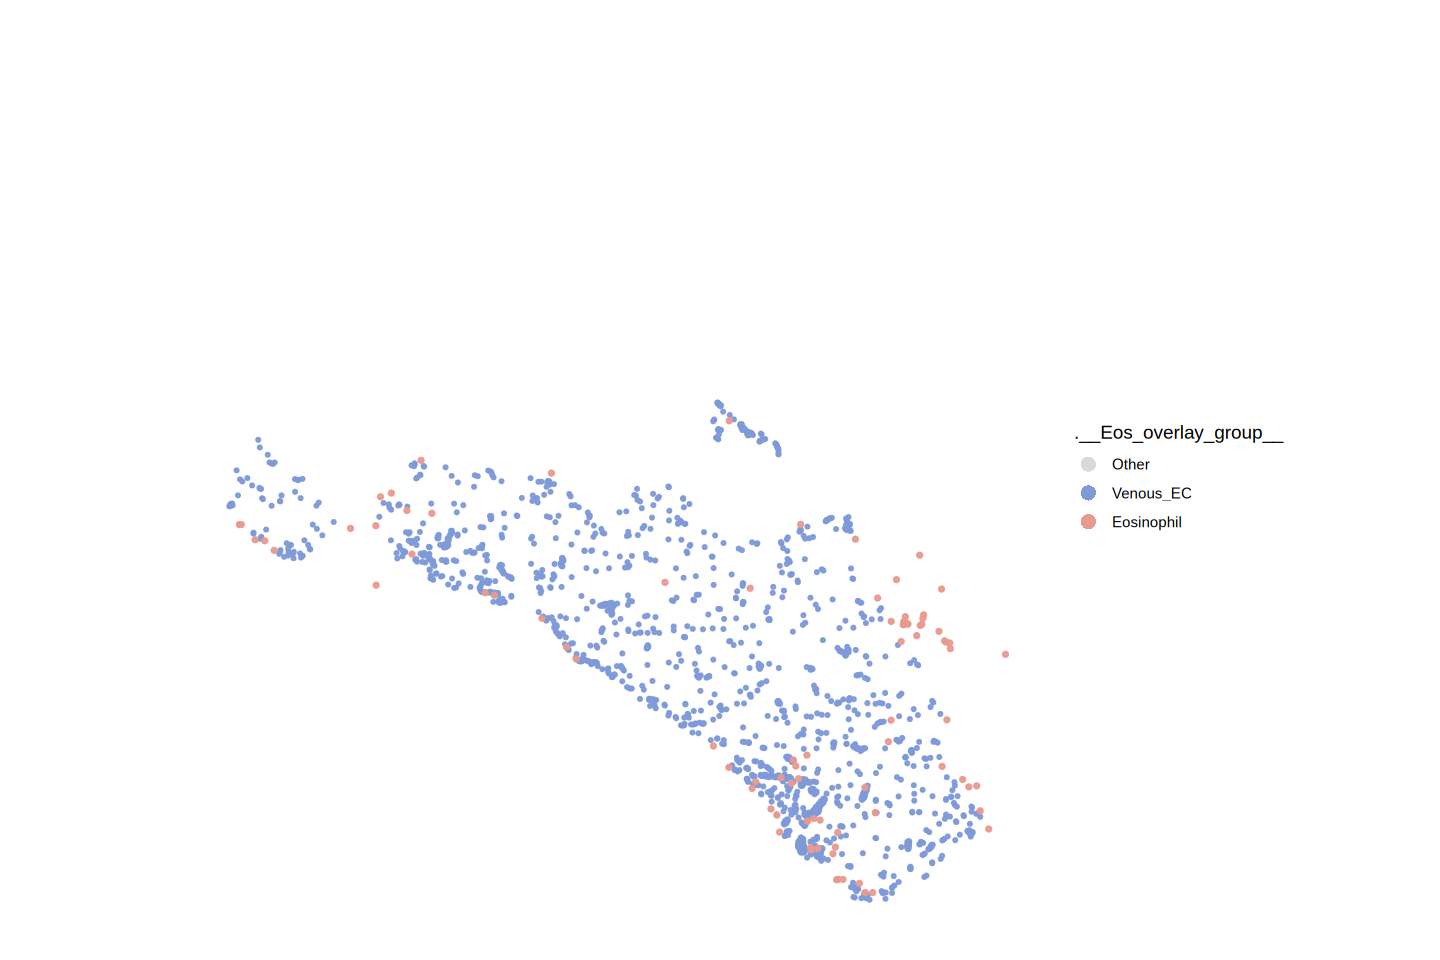

In [140]:
plot_eos_with_celltypes(
  region_spatial,
  celltypes = "Venous_EC",
    flip_xy = TRUE
)

Warning message:
“Removed 48658 rows containing missing values or values outside the scale range
(`geom_point()`).”


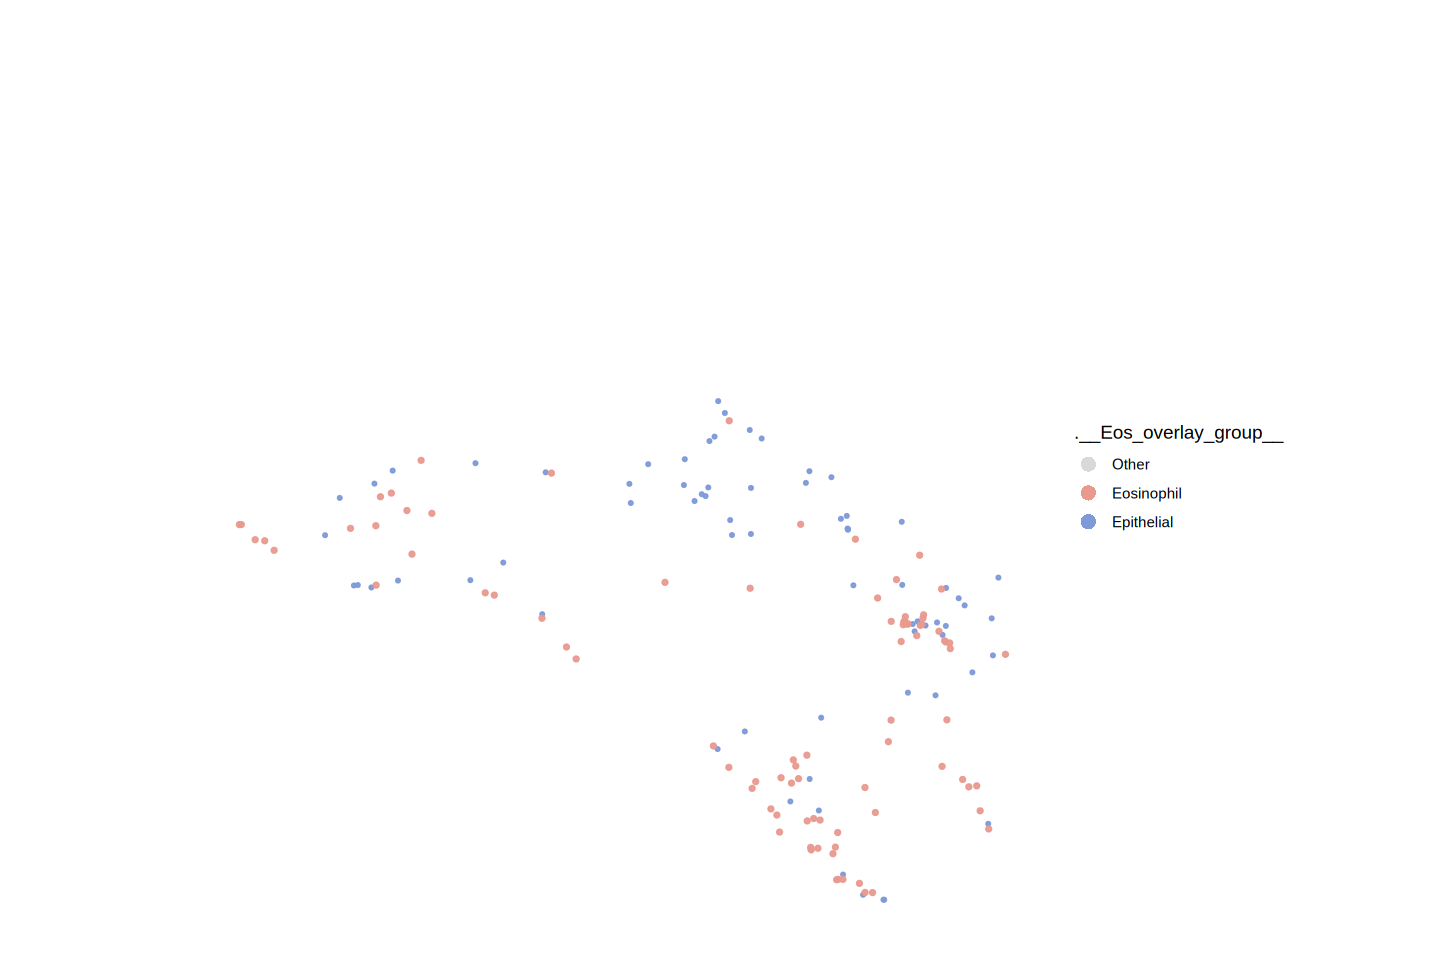

In [141]:
plot_eos_with_celltypes(
  region_spatial,
  celltypes = "Epithelial",
    flip_xy = TRUE
)

## Step8 - Define Eos subtype

In [ ]:
region_spatial = readRDS(file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_passQC.rds")))

In [142]:
table(region_spatial$EosRef_call)


OUTSIDE_IMMUNE   REF_EOS_REST  REF_EOS_TIER1  REF_EOS_TIER2  REF_EOS_TIER3 
         40588           6538             11             46            219 
 REF_EOS_TIER4 
          1256 

In [143]:
eos_cells <- rownames(region_spatial@meta.data)[
  region_spatial$Final_CellType_subtype_refined == "Eosinophil"
]

length(eos_cells)

[1] 89

In [144]:
eos_obj <- subset(
  region_spatial,
  cells = eos_cells
)

DefaultAssay(eos_obj) <- "Xenium"

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


In [145]:
EOS_GENE_SET_PATH <- file.path(
  PIPELINE_REPO,
  "config",
  "eos_gene_sets.tsv"
)

eos_gene_sets <- read.delim(
  EOS_GENE_SET_PATH,
  stringsAsFactors = FALSE
)

In [146]:
short_genes <- eos_gene_sets$gene[
  eos_gene_sets$gene_set == "short_lived"
]

long_genes <- eos_gene_sets$gene[
  eos_gene_sets$gene_set == "long_lived"
]

length(short_genes)
# 47

length(long_genes)
# 46

[1] 47

[1] 46

In [147]:
short_use <- intersect(
  short_genes,
  rownames(eos_obj)
)

long_use <- intersect(
  long_genes,
  rownames(eos_obj)
)

cat(
  "Short-lived:",
  length(short_use),
  "/",
  length(short_genes),
  "\n"
)

cat(
  "Long-lived:",
  length(long_use),
  "/",
  length(long_genes),
  "\n"
)

Short-lived: 47 / 47 
Long-lived: 46 / 46 


In [148]:
short_use

[1] "Itgal"   "Nfkbia"  "Dusp5"   "Pim1"    "Fau"     "Birc3"   "Rps27a" 
 [8] "Ncf1"    "Rps3a1"  "Rpl18a"  "Mxd1"    "Tgm2"    "Thbs1"   "Rpl35a" 
[15] "Ypel3"   "Rps16"   "Coro1a"  "Stk19"   "Cyba"    "Cxcl2"   "Cd9"    
[22] "Taldo1"  "Vasp"    "Rpl37a"  "Rpl17"   "Slc16a3" "Rps15"   "Srgn"   
[29] "Rps13"   "Rps23"   "Rps12"   "Cdk2ap2" "Sirpa"   "Dazap2"  "Ccl6"   
[36] "Rpl5"    "Nr4a1"   "Rps29"   "Gsr"     "Rpl32"   "Rps5"    "Rps8"   
[43] "Rps26"   "Lcp1"    "Ptafr"   "Cebpb"   "Kdm6b"

In [149]:
long_use

[1] "Lmna"     "Fgfr1"    "Cd300a"   "Cd44"     "Cd24a"    "Ptprc"   
 [7] "Klf2"     "Rgs1"     "Camk1d"   "Fer"      "F5"       "Csf2rb"  
[13] "Kctd12"   "Cytip"    "Cd80"     "Mctp1"    "Cdkn1a"   "Coro2a"  
[19] "Adam8"    "Slc2a3"   "Il1rl1"   "Elmo1"    "Mbnl1"    "Lyn"     
[25] "Trerf1"   "Adgre1"   "Plek"     "Atp2b1"   "Dnaja1"   "Basp1"   
[31] "Srpk2"    "Prrc2c"   "Slk"      "Rab8b"    "Rbm39"    "Arhgap18"
[37] "Tsc22d3"  "Rbms1"    "Hsp90aa1" "Rsrp1"    "Cd47"     "Srsf2"   
[43] "Dock8"    "Calm1"    "S1pr1"    "Cd84"

In [150]:
short_ribosomal <- grep(
  "^Rp[ls]",
  short_use,
  value = TRUE
)

short_nonrib <- setdiff(
  short_use,
  short_ribosomal
)

cat(
  "Short full:", length(short_use), "\n",
  "Short ribosomal:", length(short_ribosomal), "\n",
  "Short non-ribosomal:", length(short_nonrib), "\n"
)

Short full: 47 
 Short ribosomal: 17 
 Short non-ribosomal: 30 


In [151]:
state_genes <- unique(
  c(
    short_use,
    long_use
  )
)

eos_obj <- ScaleData(
  eos_obj,
  features = state_genes,
  assay = "Xenium",
  verbose = FALSE
)

Warning message:
“Different features in new layer data than already exists for scale.data”


In [152]:
state_scaled <- GetAssayData(
  eos_obj,
  assay = "Xenium",
  layer = "scale.data"
)

state_scaled <- state_scaled[
  state_genes,
  ,
  drop = FALSE
]

In [153]:
short_score_full <- colMeans(
  state_scaled[
    short_use,
    ,
    drop = FALSE
  ],
  na.rm = TRUE
)

short_score_nonrib <- colMeans(
  state_scaled[
    short_nonrib,
    ,
    drop = FALSE
  ],
  na.rm = TRUE
)

long_score <- colMeans(
  state_scaled[
    long_use,
    ,
    drop = FALSE
  ],
  na.rm = TRUE
)

In [154]:
eos_obj$EosShort_score_full <-
  short_score_full[colnames(eos_obj)]

eos_obj$EosShort_score_nonrib <-
  short_score_nonrib[colnames(eos_obj)]

eos_obj$EosLong_score <-
  long_score[colnames(eos_obj)]

In [155]:
eos_obj$EosState_score <-
  eos_obj$EosLong_score -
  eos_obj$EosShort_score_nonrib

In [156]:
eos_obj$EosState_score_full <-
  eos_obj$EosLong_score -
  eos_obj$EosShort_score_full

In [157]:
options(repr.plot.width=7, repr.plot.height=4)

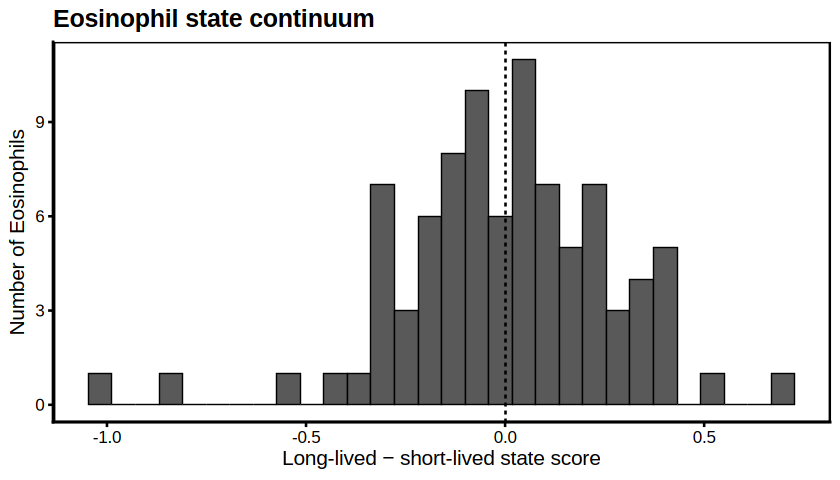

In [158]:
library(ggplot2)

ggplot(
  eos_obj@meta.data,
  aes(
    x = EosState_score
  )
) +
  geom_histogram(
    bins = 30,
    colour = "black",
    linewidth = 0.3
  ) +
  geom_vline(
    xintercept = 0,
    linetype = 2
  ) +
  labs(
    x = "Long-lived − short-lived state score",
    y = "Number of Eosinophils",
    title = "Eosinophil state continuum"
  ) +
  theme_cell()

In [159]:
options(repr.plot.width=6, repr.plot.height=6)

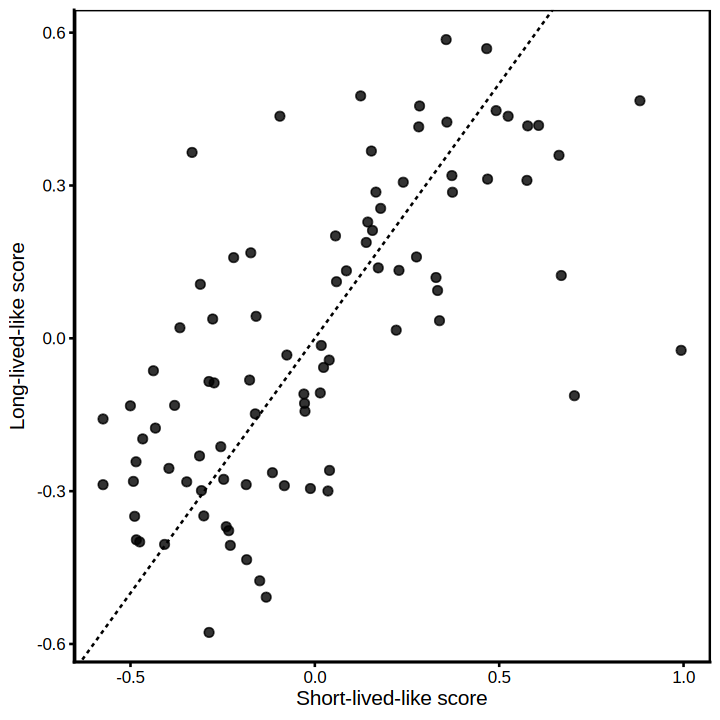

In [160]:
ggplot(
  eos_obj@meta.data,
  aes(
    x = EosShort_score_nonrib,
    y = EosLong_score
  )
) +
  geom_point(
    size = 2,
    alpha = 0.8
  ) +
  geom_abline(
    slope = 1,
    intercept = 0,
    linetype = 2
  ) +
  labs(
    x = "Short-lived-like score",
    y = "Long-lived-like score"
  ) +
  theme_cell()

In [161]:
state_counts <- FetchData(
  eos_obj,
  vars = state_genes,
  layer = "counts"
)

In [162]:
eos_obj$EosShort_n_detected <-
  rowSums(
    state_counts[, short_nonrib, drop = FALSE] > 0
  )

eos_obj$EosLong_n_detected <-
  rowSums(
    state_counts[, long_use, drop = FALSE] > 0
  )

eos_obj$EosShort_fraction_detected <-
  eos_obj$EosShort_n_detected /
  length(short_nonrib)

eos_obj$EosLong_fraction_detected <-
  eos_obj$EosLong_n_detected /
  length(long_use)

In [164]:
cor(
  eos_obj$EosState_score,
  eos_obj$nCount_Xenium,
  method = "spearman"
)

cor(
  eos_obj$EosState_score,
  eos_obj$nFeature_Xenium,
  method = "spearman"
)

[1] -0.1366714

[1] -0.08090758

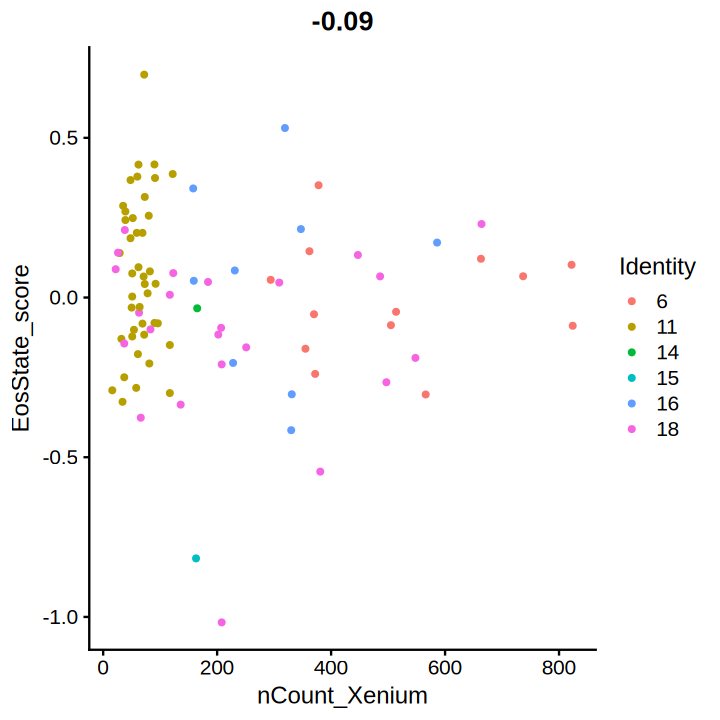

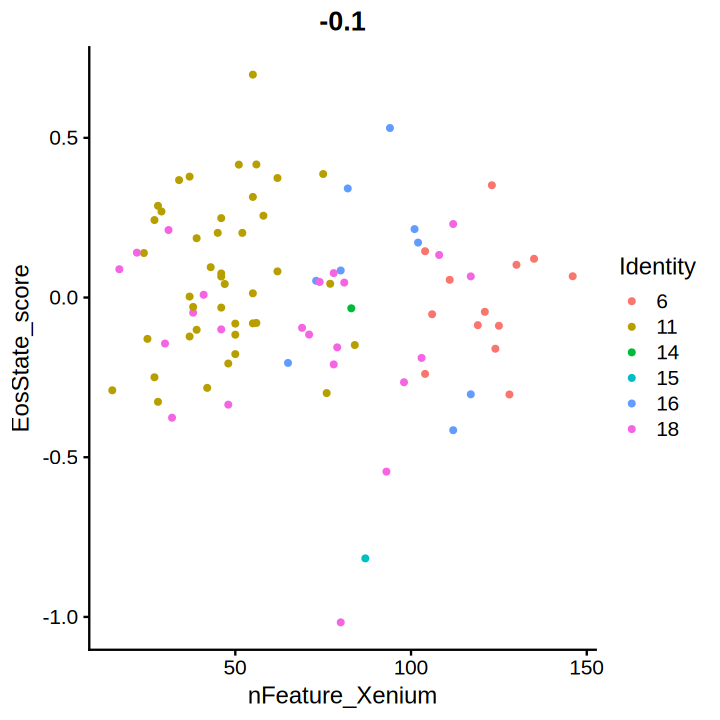

In [165]:
FeatureScatter(
  eos_obj,
  feature1 = "nCount_Xenium",
  feature2 = "EosState_score"
)

FeatureScatter(
  eos_obj,
  feature1 = "nFeature_Xenium",
  feature2 = "EosState_score"
)

In [166]:
cor(
  eos_obj$EosState_score,
  eos_obj$EosState_score_full,
  method = "spearman"
)

[1] 0.8258597

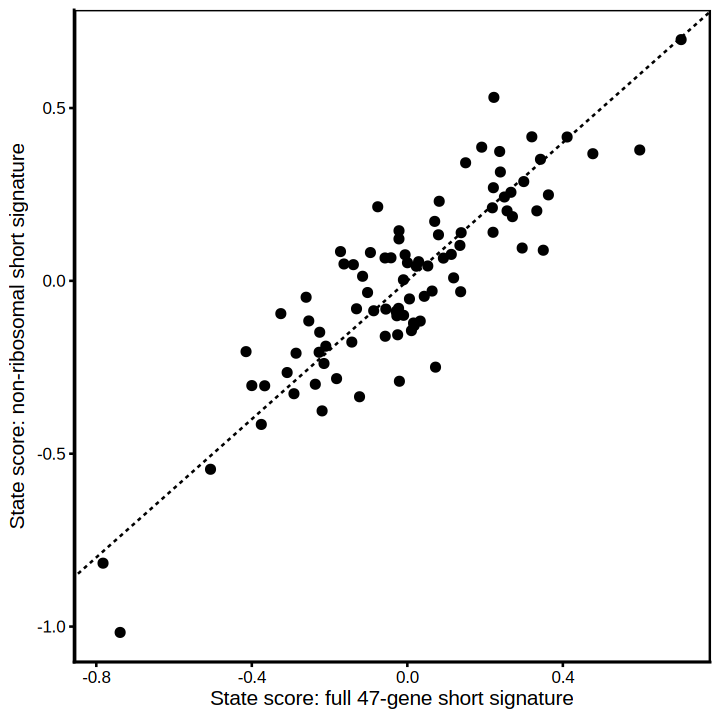

In [167]:
ggplot(
  eos_obj@meta.data,
  aes(
    x = EosState_score_full,
    y = EosState_score
  )
) +
  geom_point(
    size = 2
  ) +
  geom_abline(
    slope = 1,
    intercept = 0,
    linetype = 2
  ) +
  labs(
    x = "State score: full 47-gene short signature",
    y = "State score: non-ribosomal short signature"
  ) +
  theme_cell()

In [168]:
eos_md <- eos_obj@meta.data

eos_obj$EosShort_z <- as.numeric(
  scale(eos_md$EosShort_score_nonrib)
)

eos_obj$EosLong_z <- as.numeric(
  scale(eos_md$EosLong_score)
)

In [169]:
# Relative short ↔ long state
eos_obj$EosState_balance <- (
  eos_obj$EosLong_z -
  eos_obj$EosShort_z
) / sqrt(2)

# Overall activation of the two Eos-state programs
eos_obj$EosState_activity <- (
  eos_obj$EosLong_z +
  eos_obj$EosShort_z
) / sqrt(2)

In [170]:
cor.test(
  eos_obj$EosShort_score_nonrib,
  eos_obj$EosLong_score,
  method = "spearman"
)

Warning message in cor.test.default(eos_obj$EosShort_score_nonrib, eos_obj$EosLong_score, :
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  eos_obj$EosShort_score_nonrib and eos_obj$EosLong_score
S = 35705, p-value = 3.666e-14
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.6960789 


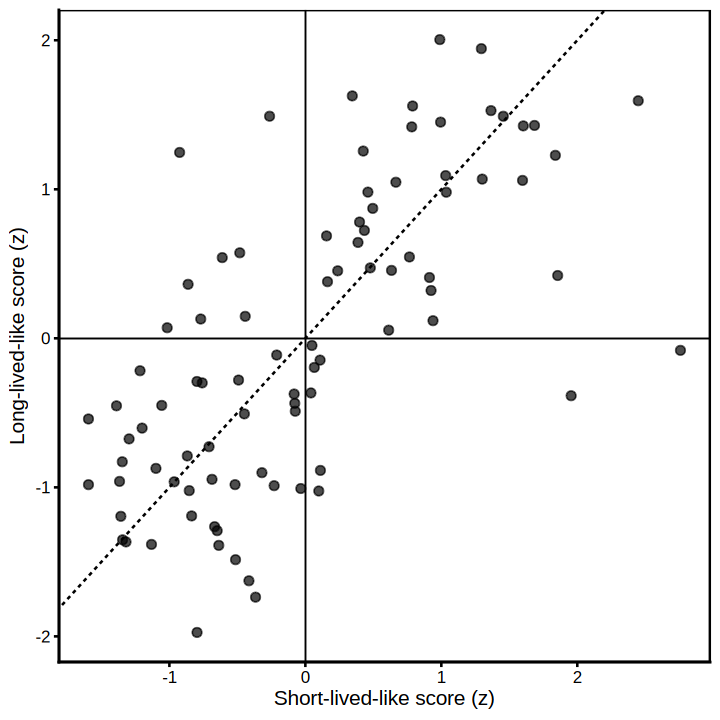

In [171]:
ggplot(
  eos_obj@meta.data,
  aes(
    x = EosShort_z,
    y = EosLong_z
  )
) +
  geom_point(
    size = 2,
    alpha = 0.7
  ) +
  geom_abline(
    slope = 1,
    intercept = 0,
    linetype = 2
  ) +
  geom_hline(
    yintercept = 0,
    linewidth = 0.4
  ) +
  geom_vline(
    xintercept = 0,
    linewidth = 0.4
  ) +
  labs(
    x = "Short-lived-like score (z)",
    y = "Long-lived-like score (z)"
  ) +
  theme_cell()

In [172]:
if (!requireNamespace("diptest", quietly = TRUE)) {
  install.packages("diptest")
}

diptest::dip.test(
  eos_obj$EosState_balance
)


	Hartigans' dip test for unimodality / multimodality

data:  eos_obj$EosState_balance
D = 0.026748, p-value = 0.9546
alternative hypothesis: non-unimodal, i.e., at least bimodal


Package 'mclust' version 6.1.3
Type 'citation("mclust")' for citing this R package in publications.


Attaching package: ‘mclust’


The following object is masked from ‘package:dplyr’:

    count




---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust X (univariate normal) model with 1 component: 

 log-likelihood  n df       BIC       ICL
      -75.61059 89  2 -160.1985 -160.1985

Clustering table:
 1 
89 

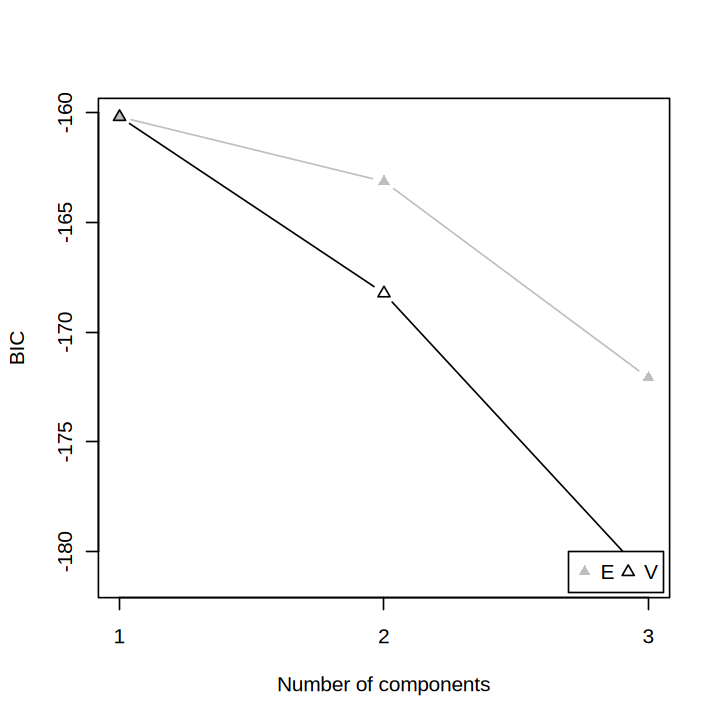

In [173]:
library(mclust)

mclust_fit <- Mclust(
  eos_obj$EosState_balance,
  G = 1:3
)

summary(mclust_fit)

plot(
  mclust_fit,
  what = "BIC"
)

In [174]:
eos_obj$EosState_n_detected <-
  eos_obj$EosShort_n_detected +
  eos_obj$EosLong_n_detected

In [ ]:
ggplot(
  eos_obj@meta.data,
  aes(
    x = EosState_balance,
    y = EosState_n_detected
  )
) +
  geom_point(
    size = 2,
    alpha = 0.7
  ) +
  geom_smooth(
    method = "loess",
    se = FALSE,
    linewidth = 0.8
  ) +
  labs(
    x = "Eosinophil state balance\n(Long-lived-like − Short-lived-like)",
    y = "Number of state genes detected"
  ) +
  theme_cell()

In [ ]:
cor.test(
  eos_obj$EosState_balance,
  eos_obj$EosState_n_detected,
  method = "spearman"
)

In [ ]:
ggplot(
  eos_obj@meta.data,
  aes(
    x = EosState_activity,
    y = EosState_n_detected
  )
) +
  geom_point(
    size = 2,
    alpha = 0.7
  ) +
  geom_smooth(
    method = "loess",
    se = FALSE
  ) +
  theme_cell()

In [ ]:
summary(
  eos_obj$EosState_n_detected
)

quantile(
  eos_obj$EosState_n_detected,
  probs = c(
    0.05,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95
  )
)

In [ ]:
ggplot(
  eos_obj@meta.data,
  aes(x = EosState_n_detected)
) +
  geom_histogram(
    binwidth = 2,
    colour = "black"
  ) +
  labs(
    x = "Number of Eosinophil state genes detected",
    y = "Number of Eosinophils"
  ) +
  theme_cell()

In [ ]:
# State balance vs signature detection
cor.test(
  eos_obj$EosState_balance,
  eos_obj$EosState_n_detected,
  method = "spearman"
)

# Activity vs signature detection
cor.test(
  eos_obj$EosState_activity,
  eos_obj$EosState_n_detected,
  method = "spearman"
)

# Balance vs total Xenium complexity
cor.test(
  eos_obj$EosState_balance,
  eos_obj$nFeature_Xenium,
  method = "spearman"
)

cor.test(
  eos_obj$EosState_balance,
  eos_obj$nCount_Xenium,
  method = "spearman"
)

In [ ]:
fit_detection <- loess(
  EosState_balance ~ EosState_n_detected,
  data = eos_obj@meta.data
)

eos_obj$EosState_balance_residual <-
  residuals(fit_detection)

In [ ]:
cor(
  eos_obj$EosState_balance,
  eos_obj$EosState_balance_residual,
  method = "spearman",
  use = "complete.obs"
)

In [ ]:
q <- 0.10

q_low <- quantile(
  eos_obj$EosState_balance,
  q,
  na.rm = TRUE
)

q_high <- quantile(
  eos_obj$EosState_balance,
  1 - q,
  na.rm = TRUE
)

eos_obj$EosState_extreme <- dplyr::case_when(

  # Long program must itself be above average
  eos_obj$EosState_balance >= q_high &
    eos_obj$EosLong_z > 0 ~
    "Long-lived-like",

  # Short program must itself be above average
  eos_obj$EosState_balance <= q_low &
    eos_obj$EosShort_z > 0 ~
    "Short-lived-like",

  TRUE ~
    "Intermediate"
)

In [ ]:
eos_obj$EosState_extreme <- factor(
  eos_obj$EosState_extreme,
  levels = c(
    "Short-lived-like",
    "Intermediate",
    "Long-lived-like"
  )
)

table(eos_obj$EosState_extreme)

In [ ]:
options(repr.plot.width=8, repr.plot.height=6)

In [ ]:
state_cols <- c(
  "Short-lived-like" = "#7E9AD9",
  "Intermediate"     = "#D9D9D9",
  "Long-lived-like"  = "#E89A8F"
)

ggplot(
  eos_obj@meta.data,
  aes(
    x = EosShort_z,
    y = EosLong_z,
    colour = EosState_extreme
  )
) +
  geom_point(
    size = 2.2,
    alpha = 0.85
  ) +
  geom_abline(
    slope = 1,
    intercept = 0,
    linetype = 2,
    linewidth = 0.6
  ) +
  geom_hline(
    yintercept = 0,
    linewidth = 0.4
  ) +
  geom_vline(
    xintercept = 0,
    linewidth = 0.4
  ) +
  scale_colour_manual(
    values = state_cols,
    drop = FALSE
  ) +
  labs(
    title = "Eosinophil state continuum",
    x = "Short-lived-like score (z)",
    y = "Long-lived-like score (z)",
    colour = "Eosinophil state"
  ) +
  theme_cell()

In [ ]:
library(ComplexHeatmap)
library(circlize)
library(dplyr)
library(grid)

# ============================================================
# 1. Choose state definition
# ============================================================

# Use your primary definition:
state_col <- "EosState_extreme"

# Or, for the strict polarized definition:
# state_col <- "EosState_polarized"


# ============================================================
# 2. Gene sets
# ============================================================

short_genes <- eos_gene_sets$gene[
  eos_gene_sets$gene_set == "short_lived"
]

long_genes <- eos_gene_sets$gene[
  eos_gene_sets$gene_set == "long_lived"
]

short_use <- intersect(
  short_genes,
  rownames(eos_obj)
)

long_use <- intersect(
  long_genes,
  rownames(eos_obj)
)

state_genes <- c(
  short_use,
  long_use
)

In [ ]:
short_nonrib <- short_use[
  !grepl("^Rp[ls]", short_use)
]

state_genes_primary <- c(
  short_nonrib,
  long_use
)

In [ ]:
# ============================================================
# 3. Normalized expression
# ============================================================

expr <- GetAssayData(
  eos_obj,
  assay = "Xenium",
  layer = "data"
)

expr <- as.matrix(
  expr[
    state_genes_primary,
    ,
    drop = FALSE
  ]
)

In [ ]:
# ============================================================
# 4. Row z-score
# ============================================================

expr_z <- t(
  scale(
    t(expr)
  )
)

# remove genes with zero variance
keep_gene <- apply(
  expr_z,
  1,
  function(x) all(is.finite(x))
)

expr_z <- expr_z[
  keep_gene,
  ,
  drop = FALSE
]

# Cap extremes for a cleaner heatmap
expr_z[
  expr_z > 2.5
] <- 2.5

expr_z[
  expr_z < -2.5
] <- -2.5

In [ ]:
# ============================================================
# 5. Order cells by continuous state balance
# ============================================================

md <- eos_obj@meta.data

cell_order_state <- rownames(md)[
  order(
    md$EosState_balance,
    decreasing = FALSE
  )
]

expr_z <- expr_z[
  ,
  cell_order_state,
  drop = FALSE
]

In [ ]:
# ============================================================
# 6. Column annotations
# ============================================================

state_annotation <- as.character(
  md[
    cell_order_state,
    state_col
  ]
)

state_annotation <- factor(
  state_annotation,
  levels = c(
    "Short-lived-like",
    "Intermediate",
    "Long-lived-like"
  )
)

balance_annotation <- md[
  cell_order_state,
  "EosState_balance"
]

state_cols <- c(
  "Short-lived-like" = "#7E9AD9",
  "Intermediate"     = "#D9D9D9",
  "Long-lived-like"  = "#E89A8F"
)

balance_lim <- max(
  abs(balance_annotation),
  na.rm = TRUE
)

balance_fun <- circlize::colorRamp2(
  c(
    -balance_lim,
    0,
    balance_lim
  ),
  c(
    "#7E9AD9",
    "#F7F7F7",
    "#E89A8F"
  )
)

ha_top <- HeatmapAnnotation(

  State = state_annotation,

  Balance = anno_simple(
    balance_annotation,
    col = balance_fun,
    border = FALSE
  ),

  col = list(
    State = state_cols
  ),

  annotation_name_gp = gpar(
    fontsize = 9,
    fontface = "bold"
  ),

  annotation_legend_param = list(
    State = list(
      title = "Eosinophil state"
    )
  )
)

In [ ]:
# ============================================================
# 7. Gene-set annotation
# ============================================================

gene_state <- ifelse(
  rownames(expr_z) %in% short_nonrib,
  "Short-lived signature",
  "Long-lived signature"
)

gene_state <- factor(
  gene_state,
  levels = c(
    "Short-lived signature",
    "Long-lived signature"
  )
)

gene_set_cols <- c(
  "Short-lived signature" = "#7E9AD9",
  "Long-lived signature"  = "#E89A8F"
)

ha_row <- rowAnnotation(
  Signature = gene_state,

  col = list(
    Signature = gene_set_cols
  ),

  show_annotation_name = FALSE
)

In [ ]:
# ============================================================
# 8. Heatmap
# ============================================================

expr_col_fun <- circlize::colorRamp2(
  c(
    -2.5,
    0,
    2.5
  ),
  c(
    "#5B7DB1",
    "#F7F7F7",
    "#D77A72"
  )
)

ht <- ha_row +

  Heatmap(
    expr_z,

    name = "Row z-score",

    col = expr_col_fun,

    top_annotation = ha_top,

    # --------------------------------------------------------
    # Preserve biological ordering
    # --------------------------------------------------------
    cluster_columns = FALSE,

    # Split rows by state signature
    row_split = gene_state,

    # Cluster genes WITHIN short / long signature
    cluster_rows = TRUE,

    clustering_distance_rows = "pearson",
    clustering_method_rows = "ward.D2",

    # --------------------------------------------------------
    # Appearance
    # --------------------------------------------------------
    show_column_names = FALSE,

    show_row_names = TRUE,

    row_names_gp = gpar(
      fontsize = 7
    ),

    row_names_side = "left",

    column_title =
      "Eosinophils ordered from short-lived-like to long-lived-like",

    column_title_gp = gpar(
      fontsize = 12,
      fontface = "bold"
    ),

    row_title_gp = gpar(
      fontsize = 10,
      fontface = "bold"
    ),

    row_gap = unit(
      2,
      "mm"
    ),

    border = FALSE,

    rect_gp = gpar(
      col = NA
    ),

    heatmap_legend_param = list(
      title = "Expression\n(z-score)",
      at = c(
        -2,
        0,
        2
      )
    )
  )

draw(
  ht,
  heatmap_legend_side = "right",
  annotation_legend_side = "right",
  merge_legends = TRUE
)

## Step9 - Eos Subtype DE Analysis

In [ ]:
eos_obj

In [ ]:
table(
  eos_obj$EosState_extreme,
  useNA = "ifany"
)

eos_de <- subset(
  eos_obj,
  subset = EosState_extreme %in%
    c(
      "Short-lived-like",
      "Long-lived-like"
    )
)

table(eos_de$EosState_extreme)

In [ ]:
Idents(eos_de) <- "EosState_extreme"

table(Idents(eos_de))

In [ ]:
genes_380_use <- intersect(
  identity_panel_genes,
  rownames(eos_de)
)

length(genes_380_use)

In [ ]:
state_genes_93 <- unique(
  eos_gene_sets$gene
)

genes_de_primary <- setdiff(
  genes_380_use,
  state_genes_93
)

length(genes_de_primary)

In [ ]:
DefaultAssay(eos_de) <- "Xenium"

eos_long_vs_short <- FindMarkers(
  eos_de,
  ident.1 = "Long-lived-like",
  ident.2 = "Short-lived-like",
  features = genes_de_primary,
  assay = "Xenium",
  slot = "data",
  test.use = "wilcox",
  logfc.threshold = 0,
  min.pct = 0,
  only.pos = FALSE
)

In [ ]:
eos_long_vs_short <- eos_long_vs_short %>%
  tibble::rownames_to_column("Gene")

In [ ]:
counts_de <- FetchData(
  eos_de,
  vars = genes_de_primary,
  layer = "counts"
)

state <- as.character(
  eos_de$EosState_extreme
)

long_idx <- state == "Long-lived-like"
short_idx <- state == "Short-lived-like"

pct_long <- colMeans(
  counts_de[long_idx, , drop = FALSE] > 0
) * 100

pct_short <- colMeans(
  counts_de[short_idx, , drop = FALSE] > 0
) * 100

In [ ]:
eos_long_vs_short <- eos_long_vs_short %>%
  dplyr::mutate(
    pct_Long = pct_long[Gene],
    pct_Short = pct_short[Gene],
    delta_pct = pct_Long - pct_Short
  )

In [ ]:
eos_long_vs_short <- eos_long_vs_short %>%
  dplyr::arrange(
    p_val_adj,
    dplyr::desc(abs(avg_log2FC))
  )

head(eos_long_vs_short, 30)

In [ ]:
eos_de_candidates <- eos_long_vs_short %>%
  dplyr::filter(
    abs(avg_log2FC) >= 0.25,
    pmax(pct_Long, pct_Short) >= 10
  ) %>%
  dplyr::arrange(
    p_val_adj,
    dplyr::desc(abs(avg_log2FC))
  )

In [ ]:
eos_long_vs_short <- eos_long_vs_short %>%
  dplyr::mutate(
    direction = dplyr::case_when(
      avg_log2FC >= 0.25 &
        p_val_adj < 0.05 ~ "Long-lived-like",

      avg_log2FC <= -0.25 &
        p_val_adj < 0.05 ~ "Short-lived-like",

      TRUE ~ "NS"
    )
  )

volcano_cols <- c(
  "Long-lived-like"  = "#D97A7A",
  "Short-lived-like" = "#5B8DB8",
  "NS"               = "#D9D9D9"
)

ggplot(
  eos_long_vs_short,
  aes(
    x = avg_log2FC,
    y = -log10(pmax(p_val_adj, 1e-300)),
    colour = direction
  )
) +
  geom_point(
    size = 2.5,
    alpha = 0.8
  ) +
  geom_vline(
    xintercept = c(-0.25, 0.25),
    linetype = 2
  ) +
  geom_hline(
    yintercept = -log10(0.05),
    linetype = 2
  ) +
  scale_colour_manual(
    values = volcano_cols
  ) +
  labs(
    x = "Long-lived-like vs Short-lived-like log2FC",
    y = "-log10(FDR)",
    colour = NULL,
    title = "Eosinophil state-associated genes"
  ) +
  theme_cell()

In [ ]:
DEList1 = read.csv("/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/eos_Fat_new_markers_1204.csv")
DEList1 = DEList1[DEList1$cluster == 0,]
DEList2 = read.csv("/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/fats_DEG-limma DEG.csv")
# DEList2 = DEList2[DEList2$Grp == 0,]

In [ ]:
print(dim(DEList1))

In [ ]:
print(dim(DEList2))

In [ ]:
head(DEList1, n=2)

In [ ]:
head(DEList2, n=2)

In [ ]:
dim(eos_long_vs_short)

In [ ]:
intersect(eos_long_vs_short$Gene, DEList1$gene)

In [ ]:
options(repr.plot.width=6, repr.plot.height=6)

In [ ]:
library(dplyr)
library(ggplot2)
library(ggrepel)


# ============================================================
# Prepare plotting dataframe
# ============================================================

scatter_df <- eos_long_vs_short %>%
  dplyr::select(
    Gene,
    Eos_log2FC = avg_log2FC
  ) %>%
  inner_join(
    DEList1 %>%
      dplyr::select(
        gene,
        DEList1_log2FC = avg_log2FC
      ),
    by = c("Gene" = "gene")
  ) %>%
  mutate(
    Concordance = case_when(

      Eos_log2FC > 0 &
        DEList1_log2FC > 0 ~
        "Long-like concordant",

      Eos_log2FC < 0 &
        DEList1_log2FC < 0 ~
        "Short-like concordant",

      TRUE ~
        "Discordant"
    ),

    label_score =
      abs(Eos_log2FC) +
      abs(DEList1_log2FC)
  )


# ============================================================
# Select genes to label
# ============================================================

label_df <- scatter_df %>%
  arrange(
    desc(label_score)
  ) %>%
  slice_head(
    n = 40
  )


# ============================================================
# Correlation
# ============================================================

r_p <- cor(
  scatter_df$Eos_log2FC,
  scatter_df$DEList1_log2FC,
  method = "pearson"
)

r_s <- cor(
  scatter_df$Eos_log2FC,
  scatter_df$DEList1_log2FC,
  method = "spearman"
)


# ============================================================
# Macaron colors
# ============================================================

scatter_cols <- c(

  "Long-like concordant" =
    "#D97A7A",

  "Short-like concordant" =
    "#5B8DB8",

  "Discordant" =
    "#CFCFCF"
)



# ============================================================
# Cell-style scatter
# ============================================================

p_logFC_scatter <- ggplot(
  scatter_df,
  aes(
    x = DEList1_log2FC,
    y = Eos_log2FC,
    colour = Concordance
  )
) +

  geom_hline(
    yintercept = 0,
    linewidth = 0.4,
    colour = "#BDBDBD"
  ) +

  geom_vline(
    xintercept = 0,
    linewidth = 0.4,
    colour = "#BDBDBD"
  ) +

  geom_abline(
    slope = 1,
    intercept = 0,
    linetype = 2,
    linewidth = 0.5,
    colour = "#999999"
  ) +

  geom_point(
    size = 2.8,
    alpha = 0.85
  ) +

  geom_text_repel(
    data = label_df,

    aes(
      label = Gene
    ),

    size = 3.5,

    colour = "black",

    box.padding = 0.35,

    point.padding = 0.2,

    max.overlaps = Inf,

    min.segment.length = 0
  ) +

  scale_colour_manual(
    values = scatter_cols
  ) +

  annotate(
    "text",

    x = Inf,

    y = Inf,

    hjust = 1.05,

    vjust = 1.5,

    label = paste0(
      "Pearson r = ",
      round(r_p, 2),
      "\nSpearman ρ = ",
      round(r_s, 2),
      "\nn = ",
      nrow(scatter_df)
    ),

    size = 4
  ) +

  labs(

    x =
      "DEList1 log2FC",

    y =
      "Eosinophil long-like vs short-like\nlog2FC",

    colour = NULL

  ) +

  theme_cell(base_size = 13) +

  theme(

    legend.position = "top",

    legend.text = element_text(
      size = 11
    )

  )


p_logFC_scatter

In [ ]:
library(dplyr)
library(ggplot2)
library(ggrepel)

# ============================================================
# 1. Prepare DEList2
# ============================================================

DEList2_use <- DEList2 %>%
  dplyr::mutate(
    gene_plot = dplyr::case_when(
      !is.na(Symbol) & Symbol != "" ~ as.character(Symbol),
      !is.na(X) & X != "" ~ as.character(X),
      TRUE ~ NA_character_
    )
  ) %>%
  dplyr::filter(
    !is.na(gene_plot)
  ) %>%
  dplyr::distinct(
    gene_plot,
    .keep_all = TRUE
  )


# ============================================================
# 2. Merge with eos_long_vs_short
# ============================================================

scatter_df2 <- eos_long_vs_short %>%
  dplyr::select(
    Gene,
    Eos_log2FC = avg_log2FC
  ) %>%
  dplyr::inner_join(
    DEList2_use %>%
      dplyr::select(
        gene_plot,
        DEList2_log2FC = logFC
      ),
    by = c("Gene" = "gene_plot")
  )

nrow(scatter_df2)
head(scatter_df2)

In [ ]:
scatter_df2 <- scatter_df2 %>%
  dplyr::mutate(
    Concordance = dplyr::case_when(

      Eos_log2FC > 0 &
        DEList2_log2FC > 0 ~
        "Long-like concordant",

      Eos_log2FC < 0 &
        DEList2_log2FC < 0 ~
        "Short-like concordant",

      TRUE ~
        "Discordant"
    ),

    label_score =
      abs(Eos_log2FC) +
      abs(DEList2_log2FC)
  )

In [ ]:
scatter_df2$DEList2_log2FC_cap <- pmax(
  pmin(
    scatter_df2$DEList2_log2FC,
    0.01
  ),
  -0.01
)

In [ ]:
label_df2 <- scatter_df2 %>%
  dplyr::filter(
    Concordance != "Discordant"
  ) %>%
  dplyr::arrange(
    dplyr::desc(label_score)
  ) %>%
  dplyr::slice_head(
    n = 40
  )

In [ ]:
r_p2 <- cor(
  scatter_df2$Eos_log2FC,
  scatter_df2$DEList2_log2FC,
  method = "pearson",
  use = "complete.obs"
)

r_s2 <- cor(
  scatter_df2$Eos_log2FC,
  scatter_df2$DEList2_log2FC,
  method = "spearman",
  use = "complete.obs"
)

In [ ]:
options(repr.plot.width=8, repr.plot.height=8)

In [ ]:
scatter_cols2 <- c(
  "Long-like concordant"  = "#D97A7A",
  "Short-like concordant" = "#5B8DB8",
  "Discordant"            = "#CFCFCF"
)

p_logFC_scatter_DEList2 <- ggplot(
  scatter_df2,
  aes(
    x = DEList2_log2FC_cap,
    y = Eos_log2FC,
    colour = Concordance
  )
) +

  geom_hline(
    yintercept = 0,
    linewidth = 0.4,
    colour = "#BDBDBD"
  ) +

  geom_vline(
    xintercept = 0,
    linewidth = 0.4,
    colour = "#BDBDBD"
  ) +

  geom_abline(
    slope = 1,
    intercept = 0,
    linetype = 2,
    linewidth = 0.5,
    colour = "#999999"
  ) +

  geom_point(
    size = 2.8,
    alpha = 0.85
  ) +

  ggrepel::geom_text_repel(
    data = label_df2,
    aes(label = Gene),
    size = 4.5,
    colour = "black",
    box.padding = 0.35,
    point.padding = 0.2,
    max.overlaps = Inf,
    min.segment.length = 0
  ) +

  scale_colour_manual(
    values = scatter_cols2
  ) +

annotate(
  "label",
  x = -Inf,
  y = Inf,
  hjust = -0.08,
  vjust = 1.15,
  label = paste0(
    "Pearson r = ", sprintf("%.2f", r_p2),
    "\nSpearman \u03c1 = ", sprintf("%.2f", r_s2),
    "\nn = ", nrow(scatter_df2)
  ),
  size = 5.5,
  colour = "#333333",
  fill = "white",
  linewidth = 0,
  label.padding = unit(0.18, "lines")
)+

  labs(
    x = "DEList2 log2FC",
    y = "Eosinophil long-like vs short-like\nlog2FC",
    colour = NULL
  ) +

  theme_cell(base_size = 14) +

  theme(
    legend.position = "top",
    legend.text = element_text(size = 12)
  ) 

p_logFC_scatter_DEList2

- Red / Long-like: Tissue adaptation, repair, ECM remodeling (Areg/Retnla)
- Blue / Short-like: Granulocyte recruitment, innate/inflammatory activity (Pglyrp1/Cxcr2/Rsad2)

In [ ]:
saveRDS(eos_obj, file.path(ANCHOR_ROOT, paste0(REGION_ID, "_eos.rds")))

## Step10 - Estimate Nearest Cell Types

In [ ]:
library(Seurat)
library(dplyr)
library(tidyr)
library(ggplot2)
library(FNN)
library(purrr)
library(tibble)

# ============================================================
# Settings
# ============================================================

celltype_col <- "Final_CellType_subtype_refined"

state_col   <- "EosState_extreme"
balance_col <- "EosState_balance"

short_name <- "Short-lived-like"
long_name  <- "Long-lived-like"

state_cols <- c(
  "Short-lived-like" = "#5B8DB8",
  "Intermediate"     = "#F6D6A8",
  "Long-lived-like"  = "#D97A7A"
)

if (!exists("theme_cell")) {
  theme_cell <- function(base_size = 12) {
    theme_classic(base_size = base_size) +
      theme(
        panel.border = element_rect(
          colour = "black",
          fill = NA,
          linewidth = 0.8
        ),
        axis.line = element_line(
          colour = "black",
          linewidth = 0.6
        ),
        axis.text = element_text(colour = "black"),
        axis.title = element_text(colour = "black"),
        legend.title = element_text(face = "bold"),
        plot.title = element_text(face = "bold")
      )
  }
}

In [ ]:
# ============================================================
# Spatial coordinates
# ============================================================

coords <- GetTissueCoordinates(
  region_spatial[["fov"]],
  which = "centroids"
) %>%
  as.data.frame()

# Check coordinate columns
colnames(coords)

In [ ]:
eos_md <- eos_obj@meta.data

idx <- match(
  colnames(region_spatial),
  rownames(eos_md)
)

for (v in state_cols) {
  region_spatial@meta.data[[v]] <- eos_md[[v]][idx]
}

In [ ]:
if (!"cell" %in% colnames(coords)) {
  coords$cell <- rownames(coords)
}

stopifnot(
  all(c("cell", "x", "y") %in% colnames(coords))
)

md <- region_spatial@meta.data
md$cell <- rownames(md)

coords <- coords %>%
  left_join(
    md,
    by = "cell"
  )

nrow(coords)
table(
  is.na(coords[[celltype_col]])
)

In [ ]:
# All confirmed Eos with a state balance
eos_all <- coords %>%
  filter(
    !is.na(.data[[balance_col]])
  )

# q10/q90 polarized Eos only
eos_extreme <- eos_all %>%
  filter(
    .data[[state_col]] %in%
      c(short_name, long_name)
  )

table(eos_all[[state_col]])
table(eos_extreme[[state_col]])

In [ ]:
# KNOWN INVALID LEGACY LOGIC: celltype_col points to the unrefined label.
# Rescued Eos can therefore remain in this apparent non-Eos pool.
reference_cells <- coords %>%
  filter(
    !is.na(.data[[celltype_col]]),
    .data[[celltype_col]] != "Eosinophil"
  )

table(reference_cells[[celltype_col]])

                         Spatial coordinates
                                │
                                ▼
                     Each Eosinophil as query
                                │
              ┌─────────────────┴─────────────────┐
              │                                   │
        Distance-based                       Neighborhood-based
              │                                   │
      ┌───────┴────────┐                 ┌────────┴────────┐
      │                │                 │                 │
closest_df      nearest_by_type     neighborhood_comp      │
      │                │                 │                 │
      │          ┌─────┴──────┐          │                 │
      │          │            │          ▼                 │
      │   distance_stats  balance_distance_stats   neighborhood_stats
      │
single nearest
cell identity

### Step10_1 - What is the single closest non-Eos cell type?

the single nearest cell - only considers one cell

In [ ]:
# NOT VALID FOR INTERPRETATION: eos_all and reference_cells were not
# checked for disjoint cell IDs, so zero-distance self-matches occur.
ref_xy <- as.matrix(
  reference_cells[, c("x", "y")]
)

eos_xy <- as.matrix(
  eos_all[, c("x", "y")]
)

nn1 <- FNN::get.knnx(
  data = ref_xy,
  query = eos_xy,
  k = 1
)

closest_df <- eos_all %>%
  transmute(
    cell,
    EosState = .data[[state_col]],
    EosState_balance = .data[[balance_col]],
    x,
    y
  )

closest_df$closest_cell <- reference_cells$cell[
  nn1$nn.index[, 1]
]

closest_df$closest_type <- reference_cells[[celltype_col]][
  nn1$nn.index[, 1]
]

closest_df$closest_distance <- nn1$nn.dist[, 1]

In [ ]:
head(closest_df)

table(
  closest_df$EosState,
  closest_df$closest_type
)

In [ ]:
closest_summary <- closest_df %>%
  filter(
    EosState %in%
      c(short_name, long_name)
  ) %>%
  dplyr::count(
    EosState,
    closest_type,
    name = "n"
  ) %>%
  group_by(EosState) %>%
  mutate(
    pct = 100 * n / sum(n)
  ) %>%
  ungroup()

closest_summary

In [ ]:
p_closest <- ggplot(
  closest_summary,
  aes(
    x = EosState,
    y = closest_type,
    fill = pct
  )
) +
  geom_tile(
    colour = "white",
    linewidth = 0.7
  ) +
  geom_text(
    aes(
      label = ifelse(pct >= 2, sprintf("%.1f", pct), "")
    ),
    size = 3
  ) +
  scale_fill_gradient(
    low = "white",
    high = "#D97A7A"
  ) +
  labs(
    x = NULL,
    y = NULL,
    fill = "%",
    title = "Closest non-Eosinophil cell type"
  ) +
  theme_cell(base_size=14) +
  theme(
    axis.text.x = element_text(
      angle = 30,
      hjust = 1
    )
  )

p_closest

### Step10_2 - Distance from every Eos to every cell type

nearest cell of every cell type - Do the two extreme Eos states occupy different spatial positions relative to particular cell types? - only uses the extreme groups and therefore discards Intermediate Eos

In [ ]:
# ============================================================
# Nearest distance to each cell type
# ============================================================

target_types <- sort(
  unique(
    as.character(
      reference_cells[[celltype_col]]
    )
  )
)

nearest_by_type <- purrr::map_dfr(
  target_types,
  function(ct) {

    target <- reference_cells %>%
      filter(
        .data[[celltype_col]] == ct
      )

    if (nrow(target) < 1) {
      return(NULL)
    }

    nn <- FNN::get.knnx(
      data = as.matrix(
        target[, c("x", "y")]
      ),
      query = as.matrix(
        eos_all[, c("x", "y")]
      ),
      k = 1
    )

    tibble(
      cell = eos_all$cell,
      target_type = ct,
      nearest_distance = nn$nn.dist[, 1]
    )
  }
)

In [ ]:
nearest_by_type <- nearest_by_type %>%
  left_join(
    eos_all %>%
      transmute(
        cell,
        EosState = .data[[state_col]],
        EosState_balance = .data[[balance_col]]
      ),
    by = "cell"
  )

In [ ]:
distance_stats <- nearest_by_type %>%
  filter(
    EosState %in%
      c(short_name, long_name)
  ) %>%
  group_by(target_type) %>%
  summarise(

    n_short = sum(
      EosState == short_name
    ),

    n_long = sum(
      EosState == long_name
    ),

    median_short = median(
      nearest_distance[
        EosState == short_name
      ],
      na.rm = TRUE
    ),

    median_long = median(
      nearest_distance[
        EosState == long_name
      ],
      na.rm = TRUE
    ),

    delta_distance =
      median_long -
      median_short,

    p_value = wilcox.test(
      nearest_distance[
        EosState == long_name
      ],
      nearest_distance[
        EosState == short_name
      ],
      exact = FALSE
    )$p.value,

    .groups = "drop"
  ) %>%
  mutate(
    FDR = p.adjust(
      p_value,
      method = "BH"
    ),

    direction = case_when(
      delta_distance < 0 ~
        "Closer to Long-like",

      delta_distance > 0 ~
        "Closer to Short-like",

      TRUE ~ "Similar"
    )
  ) %>%
  arrange(delta_distance)

distance_stats

In [ ]:
distance_cols <- c(
  "Closer to Long-like"  = "#D97A7A",
  "Closer to Short-like" = "#5B8DB8",
  "Similar"              = "#CFCFCF"
)

p_distance <- ggplot(
  distance_stats,
  aes(
    x = delta_distance,
    y = reorder(
      target_type,
      delta_distance
    ),
    colour = direction
  )
) +
  geom_vline(
    xintercept = 0,
    linetype = 2,
    colour = "#999999"
  ) +
  geom_segment(
    aes(
      x = 0,
      xend = delta_distance,
      yend = target_type
    ),
    colour = "#D8D8D8",
    linewidth = 0.7
  ) +
  geom_point(
    size = 3.5
  ) +
  scale_colour_manual(
    values = distance_cols
  ) +
  labs(
    x = "Median nearest-distance difference\nLong-like − Short-like",
    y = NULL,
    colour = NULL,
    title = "Eosinophil state-associated spatial proximity"
  ) +
  theme_cell() +
  theme(
    legend.position = "top"
  )

p_distance

### Step10_3 - Continues EosState_balance vs distance - Primary!

continuous Eos state balance - Does Eosinophil state progressively change as the distance to a given cell type changes? 
Spearman correlation - As Eos become increasingly Long-like, they are progressively closer to venous EC.

In [ ]:
balance_distance_stats <- nearest_by_type %>%
  group_by(target_type) %>%
  summarise(

    n = sum(
      complete.cases(
        EosState_balance,
        nearest_distance
      )
    ),

    rho = cor(
      EosState_balance,
      nearest_distance,
      method = "spearman",
      use = "complete.obs"
    ),

    p_value = cor.test(
      EosState_balance,
      nearest_distance,
      method = "spearman",
      exact = FALSE
    )$p.value,

    .groups = "drop"
  ) %>%
  mutate(
    FDR = p.adjust(
      p_value,
      method = "BH"
    ),

    interpretation = case_when(

      rho < 0 ~
        "Closer with Long-like balance",

      rho > 0 ~
        "Closer with Short-like balance",

      TRUE ~
        "No direction"
    )
  ) %>%
  arrange(rho)

balance_distance_stats

In [ ]:
p_balance_distance <- ggplot(
  balance_distance_stats,
  aes(
    x = rho,
    y = reorder(
      target_type,
      rho
    ),
    colour = interpretation
  )
) +
  geom_vline(
    xintercept = 0,
    linetype = 2,
    colour = "#999999"
  ) +
  geom_segment(
    aes(
      x = 0,
      xend = rho,
      yend = target_type
    ),
    colour = "#D8D8D8",
    linewidth = 0.7
  ) +
  geom_point(
    size = 3.5
  ) +
  scale_colour_manual(
    values = c(
      "Closer with Long-like balance" =
        "#D97A7A",

      "Closer with Short-like balance" =
        "#5B8DB8",

      "No direction" =
        "#CFCFCF"
    )
  ) +
  labs(
    x = "Spearman \u03c1\nEos state balance vs nearest distance",
    y = NULL,
    colour = NULL,
    title = "Spatial association with the Eosinophil state continuum"
  ) +
  theme_cell() +
  theme(
    legend.position = "top"
  )

p_balance_distance

In [ ]:
selected_type <- "ASC"

p_one_distance <- nearest_by_type %>%
  filter(
    target_type == selected_type
  ) %>%
  ggplot(
    aes(
      x = nearest_distance,
      y = EosState_balance
    )
  ) +
  geom_point(
    size = 1.8,
    alpha = 0.6,
    colour = "#777777"
  ) +
  geom_smooth(
    method = "loess",
    se = TRUE,
    linewidth = 1
  ) +
  geom_hline(
    yintercept = 0,
    linetype = 2,
    colour = "#AAAAAA"
  ) +
  labs(
    x = paste0(
      "Distance to nearest ",
      selected_type
    ),
    y = "Eosinophil state balance",
    title = selected_type
  ) +
  theme_cell()

p_one_distance

### Step10_4 - Local neighborhood composition

composition of the whole local neighborhood - What cell types make up the local neighborhood around each individual Eos?  
Instead of asking: How far away is the nearest ASC?   
Ask: Among the local cells around this Eos, how many are ASC, macrophages, EC, pericytes, etc.?  (k=15)

- neighborhood_comp: gives the neighborhood composition for each individual Eos.
- neighborhood_stats: summarizes those data by state.

In [ ]:
# ============================================================
# k-nearest neighborhood
# ============================================================

k_neighbors <- 15

nnk <- FNN::get.knnx(
  data = as.matrix(
    reference_cells[, c("x", "y")]
  ),
  query = as.matrix(
    eos_all[, c("x", "y")]
  ),
  k = k_neighbors
)

In [ ]:
neighbor_long <- tibble(

  cell = rep(
    eos_all$cell,
    each = k_neighbors
  ),

  neighbor_rank = rep(
    seq_len(k_neighbors),
    times = nrow(eos_all)
  ),

  neighbor_index = as.vector(
    t(nnk$nn.index)
  ),

  neighbor_distance = as.vector(
    t(nnk$nn.dist)
  )
)

neighbor_long$neighbor_cell <-
  reference_cells$cell[
    neighbor_long$neighbor_index
  ]

neighbor_long$neighbor_type <-
  reference_cells[[celltype_col]][
    neighbor_long$neighbor_index
  ]

In [ ]:
neighbor_long <- neighbor_long %>%
  left_join(
    eos_all %>%
      transmute(
        cell,
        EosState = .data[[state_col]],
        EosState_balance = .data[[balance_col]]
      ),
    by = "cell"
  )

In [ ]:
neighborhood_comp <- neighbor_long %>%
  dplyr::count(
    cell,
    neighbor_type,
    name = "n_neighbor"
  ) %>%
  complete(
    cell = eos_all$cell,
    neighbor_type = target_types,
    fill = list(
      n_neighbor = 0
    )
  ) %>%
  mutate(
    neighbor_fraction =
      n_neighbor /
      k_neighbors
  ) %>%
  left_join(
    eos_all %>%
      transmute(
        cell,
        EosState = .data[[state_col]],
        EosState_balance = .data[[balance_col]]
      ),
    by = "cell"
  )

In [ ]:
neighborhood_stats <- neighborhood_comp %>%
  filter(
    EosState %in%
      c(short_name, long_name)
  ) %>%
  group_by(
    neighbor_type
  ) %>%
  summarise(

    mean_short = mean(
      neighbor_fraction[
        EosState == short_name
      ],
      na.rm = TRUE
    ),

    mean_long = mean(
      neighbor_fraction[
        EosState == long_name
      ],
      na.rm = TRUE
    ),

    delta_fraction =
      mean_long -
      mean_short,

    p_value = wilcox.test(
      neighbor_fraction[
        EosState == long_name
      ],
      neighbor_fraction[
        EosState == short_name
      ],
      exact = FALSE
    )$p.value,

    .groups = "drop"
  ) %>%
  mutate(
    FDR = p.adjust(
      p_value,
      method = "BH"
    ),

    delta_pct =
      100 * delta_fraction,

    enrichment = case_when(

      delta_pct > 0 ~
        "Long-like niche",

      delta_pct < 0 ~
        "Short-like niche",

      TRUE ~
        "Similar"
    )
  ) %>%
  arrange(delta_pct)

neighborhood_stats

In [ ]:
p_neighborhood <- ggplot(
  neighborhood_stats,
  aes(
    x = delta_pct,
    y = reorder(
      neighbor_type,
      delta_pct
    ),
    fill = enrichment
  )
) +
  geom_vline(
    xintercept = 0,
    linetype = 2,
    colour = "#888888"
  ) +
  geom_col(
    width = 0.72
  ) +
  scale_fill_manual(
    values = c(
      "Long-like niche" =
        "#D97A7A",

      "Short-like niche" =
        "#5B8DB8",

      "Similar" =
        "#CFCFCF"
    )
  ) +
  labs(
    x = "Neighborhood enrichment\nLong-like − Short-like (%)",
    y = NULL,
    fill = NULL,
    title = "Local cellular niche of Eosinophil states"
  ) +
  theme_cell() +
  theme(
    legend.position = "top"
  )

p_neighborhood

In [ ]:
neighborhood_balance_stats <- neighborhood_comp %>%
  group_by(
    neighbor_type
  ) %>%
  summarise(

    rho = cor(
      EosState_balance,
      neighbor_fraction,
      method = "spearman",
      use = "complete.obs"
    ),

    p_value = cor.test(
      EosState_balance,
      neighbor_fraction,
      method = "spearman",
      exact = FALSE
    )$p.value,

    .groups = "drop"
  ) %>%
  mutate(
    FDR = p.adjust(
      p_value,
      method = "BH"
    )
  ) %>%
  arrange(rho)

neighborhood_balance_stats

In [ ]:
p_neighborhood_balance <- ggplot(
  neighborhood_balance_stats[complete.cases(neighborhood_balance_stats),],
  aes(
    x = rho,
    y = reorder(
      neighbor_type,
      rho
    )
  )
) +
  geom_vline(
    xintercept = 0,
    linetype = 2,
    colour = "#999999"
  ) +
  geom_segment(
    aes(
      x = 0,
      xend = rho,
      yend = neighbor_type
    ),
    colour = "#D8D8D8",
    linewidth = 0.7
  ) +
  geom_point(
    aes(
      colour = rho
    ),
    size = 3.5
  ) +
  scale_colour_gradient2(
    low = "#5B8DB8",
    mid = "#F6D6A8",
    high = "#D97A7A",
    midpoint = 0
  ) +
  labs(
    x = "Spearman \u03c1\nState balance vs neighborhood fraction",
    y = NULL,
    colour = "\u03c1",
    title = "Cellular niche across the Eosinophil state continuum"
  ) +
  theme_cell()

p_neighborhood_balance

### Step10_5 - Check whether suspicious DE genes are caused by neighboring cells

In [ ]:
suspicious_genes <- c(
  "Vwf",
  "Eng",
  "Tagln",
  "Cpa3",
  "Ppbp",
  "Lrp2",
  "Upk1b",
  "Plp1"
)

In [ ]:
eos_gene_expr <- FetchData(
  region_spatial,
  vars = suspicious_genes,
  layer = "counts"
)

eos_gene_expr$cell <- rownames(
  eos_gene_expr
)

eos_gene_expr <- eos_gene_expr %>%
  filter(
    cell %in% eos_all$cell
  )

In [ ]:
endo_types <- c(
  "Capillary_EC",
  "Arterial_EC",
  "Venous_EC",
  "Lymphatic_EC"
)

eos_endo_distance <- nearest_by_type %>%
  filter(
    target_type %in%
      endo_types
  ) %>%
  group_by(cell) %>%
  summarise(
    nearest_Endo =
      min(
        nearest_distance,
        na.rm = TRUE
      ),
    .groups = "drop"
  )

In [ ]:
vwf_check <- eos_gene_expr %>%
  select(
    cell,
    Vwf,
    Eng
  ) %>%
  left_join(
    eos_endo_distance,
    by = "cell"
  )

cor.test(
  vwf_check$Vwf,
  vwf_check$nearest_Endo,
  method = "spearman",
  exact = FALSE
)

## Step11 - Spatially constrained ligand-receptor analysis

In [ ]:
library(CellChat)

data(CellChatDB.mouse)

panel_genes <- rownames(
  region_spatial[["Xenium"]]
)

lr_db <- CellChatDB.mouse$interaction

In [ ]:
colnames(lr_db)
head(lr_db)

In [ ]:
lr_simple <- lr_db %>%
  filter(
    ligand %in% panel_genes,
    receptor %in% panel_genes
  ) %>%
  transmute(
    interaction_name,
    pathway_name,
    ligand,
    receptor
  ) %>%
  distinct()

nrow(lr_simple)

lr_simple

In [ ]:
DefaultAssay(region_spatial) <- "Xenium"

expr <- GetAssayData(
  region_spatial,
  assay = "Xenium",
  layer = "data"
)

lr_genes <- intersect(
  unique(
    c(
      lr_simple$ligand,
      lr_simple$receptor
    )
  ),
  rownames(expr)
)

length(lr_genes)

In [ ]:
spatial_edges <- neighbor_long %>%
  filter(
    EosState %in%
      c(
        short_name,
        long_name
      )
  )

In [ ]:
eos_idx <- match(
  spatial_edges$cell,
  colnames(expr)
)

neighbor_idx <- match(
  spatial_edges$neighbor_cell,
  colnames(expr)
)

stopifnot(
  !any(is.na(eos_idx)),
  !any(is.na(neighbor_idx))
)

In [ ]:
lr_edge_scores <- purrr::map_dfr(
  seq_len(
    nrow(lr_simple)
  ),
  function(i) {

    lig <- lr_simple$ligand[i]
    rec <- lr_simple$receptor[i]

    # Eos ligand -> neighboring cell receptor
    eos_to_neighbor <- tibble(

      eos_cell =
        spatial_edges$cell,

      EosState =
        spatial_edges$EosState,

      neighbor_type =
        spatial_edges$neighbor_type,

      interaction =
        lr_simple$interaction_name[i],

      pathway =
        lr_simple$pathway_name[i],

      ligand = lig,

      receptor = rec,

      direction =
        "Eos -> Neighbor",

      LR_score =
        as.numeric(
          expr[
            lig,
            eos_idx
          ]
        ) *
        as.numeric(
          expr[
            rec,
            neighbor_idx
          ]
        )
    )

    # neighboring cell ligand -> Eos receptor
    neighbor_to_eos <- tibble(

      eos_cell =
        spatial_edges$cell,

      EosState =
        spatial_edges$EosState,

      neighbor_type =
        spatial_edges$neighbor_type,

      interaction =
        lr_simple$interaction_name[i],

      pathway =
        lr_simple$pathway_name[i],

      ligand = lig,

      receptor = rec,

      direction =
        "Neighbor -> Eos",

      LR_score =
        as.numeric(
          expr[
            lig,
            neighbor_idx
          ]
        ) *
        as.numeric(
          expr[
            rec,
            eos_idx
          ]
        )
    )

    bind_rows(
      eos_to_neighbor,
      neighbor_to_eos
    )
  }
)

In [ ]:
lr_by_eos <- lr_edge_scores %>%
  group_by(
    eos_cell,
    EosState,
    neighbor_type,
    direction,
    pathway,
    interaction,
    ligand,
    receptor
  ) %>%
  summarise(
    LR_score = mean(
      LR_score,
      na.rm = TRUE
    ),
    .groups = "drop"
  )

In [ ]:
lr_state_compare <- lr_by_eos %>%
  group_by(
    neighbor_type,
    direction,
    pathway,
    interaction,
    ligand,
    receptor
  ) %>%
  summarise(

    n_long = sum(
      EosState == long_name
    ),

    n_short = sum(
      EosState == short_name
    ),

    mean_long = mean(
      LR_score[
        EosState == long_name
      ],
      na.rm = TRUE
    ),

    mean_short = mean(
      LR_score[
        EosState == short_name
      ],
      na.rm = TRUE
    ),

    delta_score =
      mean_long -
      mean_short,

    .groups = "drop"
  ) %>%
  filter(
    n_long >= 5,
    n_short >= 5
  ) %>%
  arrange(
    desc(
      abs(delta_score)
    )
  )

head(
  lr_state_compare,
  30
)

In [ ]:
top_lr <- lr_state_compare %>%
  slice_max(
    order_by = abs(delta_score),
    n = 25
  ) %>%
  mutate(
    LR_label = paste0(
      ligand, " → ", receptor,
      "\n", neighbor_type,
      " | ", direction
    )
  )

In [ ]:
options(repr.plot.width=15, repr.plot.height=8)

In [ ]:
p_lr <- ggplot(
  top_lr,
  aes(
    x = delta_score,
    y = reorder(
      LR_label,
      delta_score
    ),
    fill = delta_score
  )
) +
  geom_vline(
    xintercept = 0,
    linetype = 2,
    colour = "#888888"
  ) +
  geom_col(
    width = 0.7
  ) +
  scale_fill_gradient2(
    low = "#5B8DB8",
    mid = "#F6D6A8",
    high = "#D97A7A",
    midpoint = 0
  ) +
  facet_wrap(
    ~direction,
    scales = "free_y"
  )+
  labs(
    x = "Spatial LR score difference\nLong-like − Short-like",
    y = NULL,
    fill = "Difference",
    title = "Spatially supported Eosinophil interaction programs"
  ) +
  theme_cell()

p_lr

In [ ]:
CellChatDB.mouse$interaction %>%
  dplyr::filter(
    ligand == "Ccl6" |
    receptor %in% c("Ccr1", "Ccr3")
  ) %>%
  dplyr::select(
    interaction_name,
    pathway_name,
    ligand,
    receptor,
    everything()
  )

In [ ]:
c("Ccl6", "Ccr1", "Ccr3") %in% rownames(region_spatial[["Xenium"]])

Long-like and Short-like eosinophils appear embedded in different spatial communication programs
- Long-like Eos：
    - Eos → Neighbor: predicted Thbs4 → Cd36/Cd47 signaling toward venous EC and cDC1, and Comp → Cd36/Cd47 toward cDC1 (ECM/adhesion/tissue-remodeling program)
    - Neighbor → Eos: Ccl6 → Ccr3 from CCR2 inflammatory monocytes, LYVE1-resident macrophages, and venous EC (Ruggiero-Ruff The journal of immunology 2026, https://doi.org/10.1093/jimmun/vkag141.1564)
- Short-like
    - Eos → Neighbor: Thbs1 → Cd36/Cd47 interactions toward capillary EC, LYVE1 macrophages, adipocytes, APC, pericytes, venous EC and inflammatory monocytes (broad THBS1-associated stromal/vascular interaction program)

## Step12 - Back to main

In [ ]:
# ============================================================
# 1. Eos state variables to map back
# ============================================================

state_vars <- c(
  "EosShort_score_nonrib",
  "EosLong_score",
  "EosShort_z",
  "EosLong_z",
  "EosState_balance",
  "EosState_activity",
  "EosState_n_detected",
  "EosState_extreme"
)

state_vars <- intersect(
  state_vars,
  colnames(eos_obj@meta.data)
)

state_vars

In [ ]:
# ============================================================
# 2. Map Eos-state metadata back to full region_spatial
# ============================================================

eos_md <- eos_obj@meta.data

for (v in state_vars) {

  region_spatial@meta.data[[v]] <- eos_md[
    match(
      rownames(region_spatial@meta.data),
      rownames(eos_md)
    ),
    v
  ]
}

In [ ]:
sum(!is.na(region_spatial$EosState_balance))
ncol(eos_obj)

In [ ]:
table(
  region_spatial$EosState_extreme,
  useNA = "ifany"
)

In [ ]:
region_spatial$EosState_spatial <- dplyr::case_when(

  region_spatial$EosState_extreme == "Short-lived-like" ~
    "Short-lived-like",

  region_spatial$EosState_extreme == "Long-lived-like" ~
    "Long-lived-like",

  region_spatial$EosState_extreme == "Intermediate" ~
    "Intermediate",

  TRUE ~
    "Other"
)

region_spatial$EosState_spatial <- factor(
  region_spatial$EosState_spatial,
  levels = c(
    "Other",
    "Intermediate",
    "Short-lived-like",
    "Long-lived-like"
  )
)

In [ ]:
eos_state_cols <- c(
  "Other"            = "#E8E8E8",
  "Intermediate"     = "#CFCFCF",
  "Short-lived-like" = "#7E9AD9",
  "Long-lived-like"  = "#E89A8F"
)

In [ ]:
table(region_spatial$EosState_spatial)

In [ ]:
colnames(region_spatial@meta.data)

In [ ]:
ImageDimPlot(
  region_spatial,
  fov = "fov",
  split.by = "EosState_spatial",
  group.by = "Final_CellType_subtype_refined",
  flip_xy = FALSE,
  dark.background = FALSE
)

In [ ]:
coords <- GetTissueCoordinates(
  region_spatial[["fov"]],
  which = "centroids"
) %>%
  as.data.frame()

if (!"cell" %in% colnames(coords)) {
  coords$cell <- rownames(coords)
}

In [ ]:
md <- region_spatial@meta.data

coords$EosState_balance <- md$EosState_balance[
  match(
    coords$cell,
    rownames(md)
  )
]

coords$EosState_extreme <- as.character(
  md$EosState_extreme[
    match(
      coords$cell,
      rownames(md)
    )
  ]
)

In [ ]:
eos_coords <- coords %>%
  dplyr::filter(
    !is.na(EosState_balance)
  )

In [ ]:
options(repr.plot.width=10, repr.plot.height=6)

In [ ]:
library(ggplot2)

balance_lim <- max(
  abs(eos_coords$EosState_balance),
  na.rm = TRUE
)

ggplot() +

  # ----------------------------------------------------------
  # All cells in grey
  # ----------------------------------------------------------
  geom_point(
    data = coords,
    aes(
      x = x,
      y = y
    ),
    colour = "#E8E8E8",
    size = 0.10,
    alpha = 0.5
  ) +

  # ----------------------------------------------------------
  # Eos colored by continuous balance
  # ----------------------------------------------------------
  geom_point(
    data = eos_coords,
    aes(
      x = x,
      y = y,
      colour = EosState_balance
    ),
    size = 1.5,
    alpha = 0.95
  ) +

  scale_colour_gradient2(
    low  = "#5B8DB8",
    mid  = "lightyellow",
    high = "#D97A7A",
    midpoint = 0,
    limits = c(
      -balance_lim,
      balance_lim
    ),
    name = "Eosinophil\nstate balance"
  ) +

  coord_fixed() +

  labs(
    title = "Spatial Eosinophil state continuum",
    subtitle = "Short-lived-like ← state balance → Long-lived-like",
    x = NULL,
    y = NULL
  ) +

  theme_void() +

  theme(
    plot.title = element_text(
      face = "bold",
      size = 13
    ),
    plot.subtitle = element_text(
      size = 10
    ),
    legend.title = element_text(
      face = "bold"
    )
  )

In [ ]:
polarized_coords <- eos_coords %>%
  dplyr::filter(
    EosState_extreme %in%
      c(
        "Short-lived-like",
        "Long-lived-like"
      )
  )

In [ ]:
ggplot() +

  geom_point(
    data = coords,
    aes(x = x, y = y),
    colour = "#E8E8E8",
    size = 0.10,
    alpha = 0.45
  ) +

  geom_point(
    data = polarized_coords,
    aes(
      x = x,
      y = y,
      colour = EosState_extreme
    ),
    size = 1.2,
    alpha = 0.95
  ) +

  scale_colour_manual(
    values = c(
      "Short-lived-like" = "#7E9AD9",
      "Long-lived-like"  = "#E89A8F"
    )
  ) +

  coord_fixed() +

  labs(
    title = "Spatial localization of polarized Eosinophil states",
    colour = "Eosinophil state"
  ) +

  theme_void()

In [ ]:
saveRDS(region_spatial, file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_passQC.rds")))

## Step13 - Define Lymph node

In [ ]:
region_spatial = readRDS(file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_passQC.rds")))

In [ ]:
library(dplyr)
library(ggplot2)

coords <- GetTissueCoordinates(
  region_spatial[["fov"]],
  which = "centroids"
) %>%
  as.data.frame()

if (!"cell" %in% colnames(coords)) {
  coords$cell <- rownames(coords)
}

md <- region_spatial@meta.data %>%
  tibble::rownames_to_column("cell")

coords <- coords %>%
  left_join(
    md,
    by = "cell"
  )

range(coords$x)
range(coords$y)

In [ ]:
options(repr.plot.width=12, repr.plot.height=8)

In [ ]:
range(coords$x, na.rm = TRUE)
range(coords$y, na.rm = TRUE)

ggplot(
  coords,
  aes(x = x, y = y)
) +
  geom_point(
    size = 0.12,
    colour = "#D9D9D9"
  ) +
  coord_fixed() +
  theme_classic() +
  labs(
    x = "X coordinate",
    y = "Y coordinate"
  )

In [ ]:
lymphoid_types <- c(
  "B",
  "T",
  "γδ T",
  "NK",
  "Plasma",
  "cDC1",
  "cDC2",
  "CCR7_migratory_DC"
)

coords$is_lymphoid <-
  coords$Final_CellType_subtype %in%
  lymphoid_types

In [ ]:
library(FNN)

xy <- as.matrix(
  coords[, c("x", "y")]
)

knn <- FNN::get.knn(
  xy,
  k = 30
)

coords$local_lymphoid_fraction <- apply(
  knn$nn.index,
  1,
  function(ii) {
    mean(
      coords$is_lymphoid[ii],
      na.rm = TRUE
    )
  }
)

In [ ]:
ggplot(
  coords,
  aes(
    x = x,
    y = y,
    colour = local_lymphoid_fraction
  )
) +
  geom_point(
    size = 0.25
  ) +
  scale_colour_gradient(
    low = "#E8E8E8",
    high = "#D73027"
  ) +
  coord_fixed() +
  theme_void() +
  labs(
    colour = "Local lymphoid\nfraction"
  )

In [ ]:
ln_core <- coords %>%
  filter(
    local_lymphoid_fraction >= 0.5
  )

nrow(ln_core)

In [ ]:
ggplot() +
  geom_point(
    data = coords,
    aes(x, y),
    size = 0.12,
    colour = "#D9D9D9"
  ) +
  geom_point(
    data = ln_core,
    aes(x, y),
    size = 0.4,
    colour = "#D73027"
  ) +
  coord_fixed() +
  theme_void()

In [ ]:
library(dbscan)

cl <- dbscan::dbscan(
  as.matrix(
    ln_core[, c("x", "y")]
  ),
  eps = 80,
  minPts = 10
)

table(cl$cluster)

In [ ]:
ln_core$LN_cluster <- cl$cluster

In [ ]:
main_cluster <- names(
  which.max(
    table(
      ln_core$LN_cluster[
        ln_core$LN_cluster != 0
      ]
    )
  )
)

main_cluster <- as.integer(main_cluster)

ln_core_main <- ln_core %>%
  filter(
    LN_cluster == main_cluster
  )

In [ ]:
ggplot() +
  geom_point(
    data = coords,
    aes(x, y),
    colour = "#D9D9D9",
    size = 0.12
  ) +
  geom_point(
    data = ln_core_main,
    aes(x, y),
    colour = "#D73027",
    size = 0.35
  ) +
  coord_fixed() +
  theme_void()

In [ ]:
hull_idx <- chull(
  ln_core_main$x,
  ln_core_main$y
)

ln_polygon <- ln_core_main[
  hull_idx,
  c("x", "y")
]

# close polygon explicitly
ln_polygon <- rbind(
  ln_polygon,
  ln_polygon[1, ]
)

In [ ]:
ggplot() +
  geom_point(
    data = coords,
    aes(x, y),
    colour = "#D9D9D9",
    size = 0.12
  ) +
  geom_polygon(
    data = ln_polygon,
    aes(x, y),
    fill = NA,
    colour = "#D73027",
    linewidth = 0.8
  ) +
  coord_fixed() +
  theme_void()

In [ ]:
inside_ln <- sp::point.in.polygon(
  point.x = coords$x,
  point.y = coords$y,
  pol.x = ln_polygon$x,
  pol.y = ln_polygon$y
)

coords$LN_region <- ifelse(
  inside_ln > 0,
  "Lymph_node",
  "Adipose"
)

In [ ]:
table(coords$LN_region)

In [ ]:
region_spatial$LN_region <-
  coords$LN_region[
    match(
      colnames(region_spatial),
      coords$cell
    )
  ]

In [ ]:
table(
  region_spatial$LN_region,
  useNA = "ifany"
)

In [ ]:
ln_composition <- region_spatial@meta.data %>%
  count(
    LN_region,
    Final_CellType_subtype_refined
  ) %>%
  group_by(LN_region) %>%
  mutate(
    pct = 100 * n / sum(n)
  ) %>%
  ungroup()

ln_composition

In [ ]:
ImageDimPlot(
  region_spatial,
  fov = "fov",
  group.by = "LN_region",
  cols = c(
    "Adipose" = "#D9D9D9",
    "Lymph_node" = "#D73027"
  ),
  flip_xy = FALSE,
  dark.background = FALSE,
)

In [ ]:
saveRDS(region_spatial, file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_passQC.rds")))

## Step14 - Remove Lymph node and redo Eos analysis

In [ ]:
LNremoved <- subset(
  region_spatial,
  subset = LN_region == "Adipose"
)

In [ ]:
LNremoved

In [ ]:
coords <- GetTissueCoordinates(
  region_spatial[["fov"]],
  which = "centroids"
) %>%
  as.data.frame()

if (!"cell" %in% colnames(coords)) {
  coords$cell <- rownames(coords)
}

In [ ]:
colnames(region_spatial@meta.data)

In [ ]:
md <- region_spatial@meta.data

coords$EosState_balance <- md$EosState_balance[
  match(
    coords$cell,
    rownames(md)
  )
]

coords$EosState_extreme <- as.character(
  md$EosState_extreme[
    match(
      coords$cell,
      rownames(md)
    )
  ]
)

In [ ]:
eos_coords <- coords %>%
  dplyr::filter(
    !is.na(EosState_balance)
  )

In [ ]:
polarized_coords <- eos_coords %>%
  dplyr::filter(
    EosState_extreme %in%
      c(
        "Short-lived-like",
        "Long-lived-like"
      )
  )

In [ ]:
ggplot() +

  geom_point(
    data = coords,
    aes(x = x, y = y),
    colour = "#E8E8E8",
    size = 0.10,
    alpha = 0.45
  ) +

  geom_point(
    data = polarized_coords,
    aes(
      x = x,
      y = y,
      colour = EosState_extreme
    ),
    size = 1.2,
    alpha = 0.95
  ) +

  scale_colour_manual(
    values = c(
      "Short-lived-like" = "#7E9AD9",
      "Long-lived-like"  = "#E89A8F"
    )
  ) +

  coord_fixed() +

  labs(
    title = "Spatial localization of polarized Eosinophil states",
    colour = "Eosinophil state"
  ) +

  theme_void()